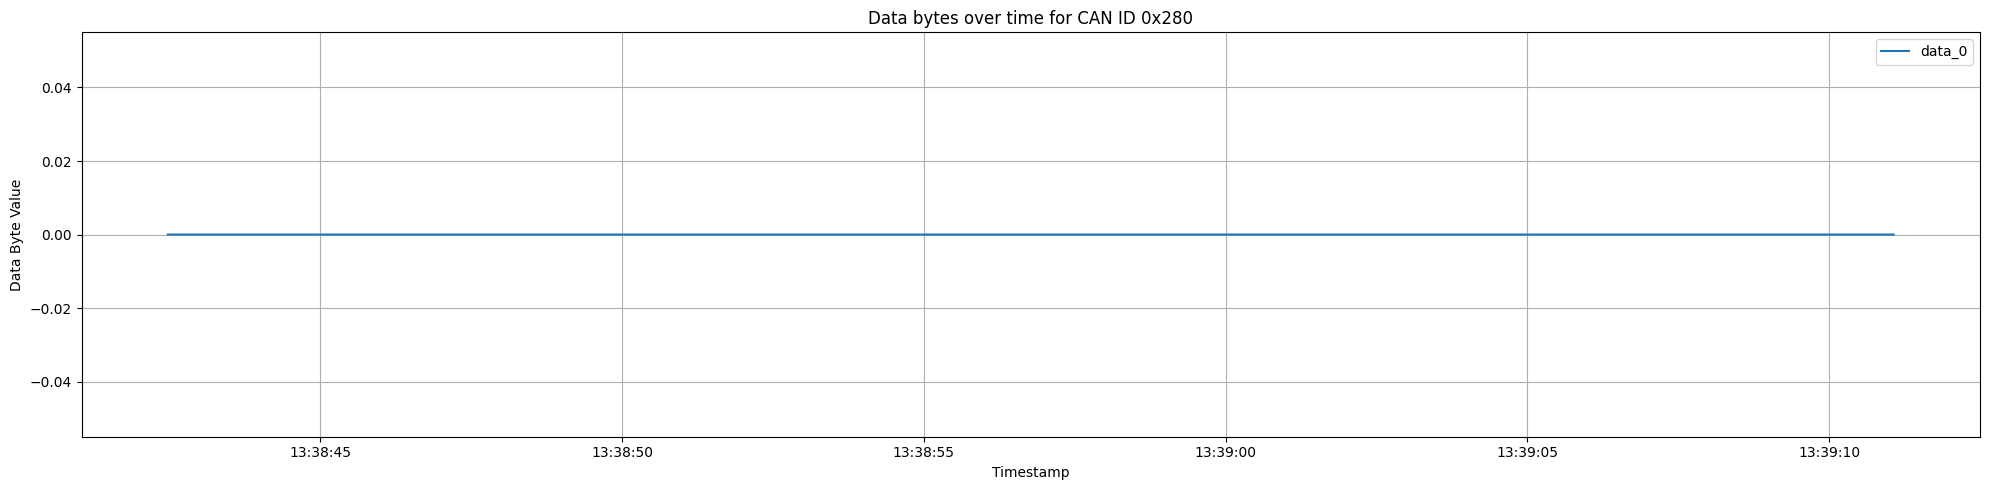

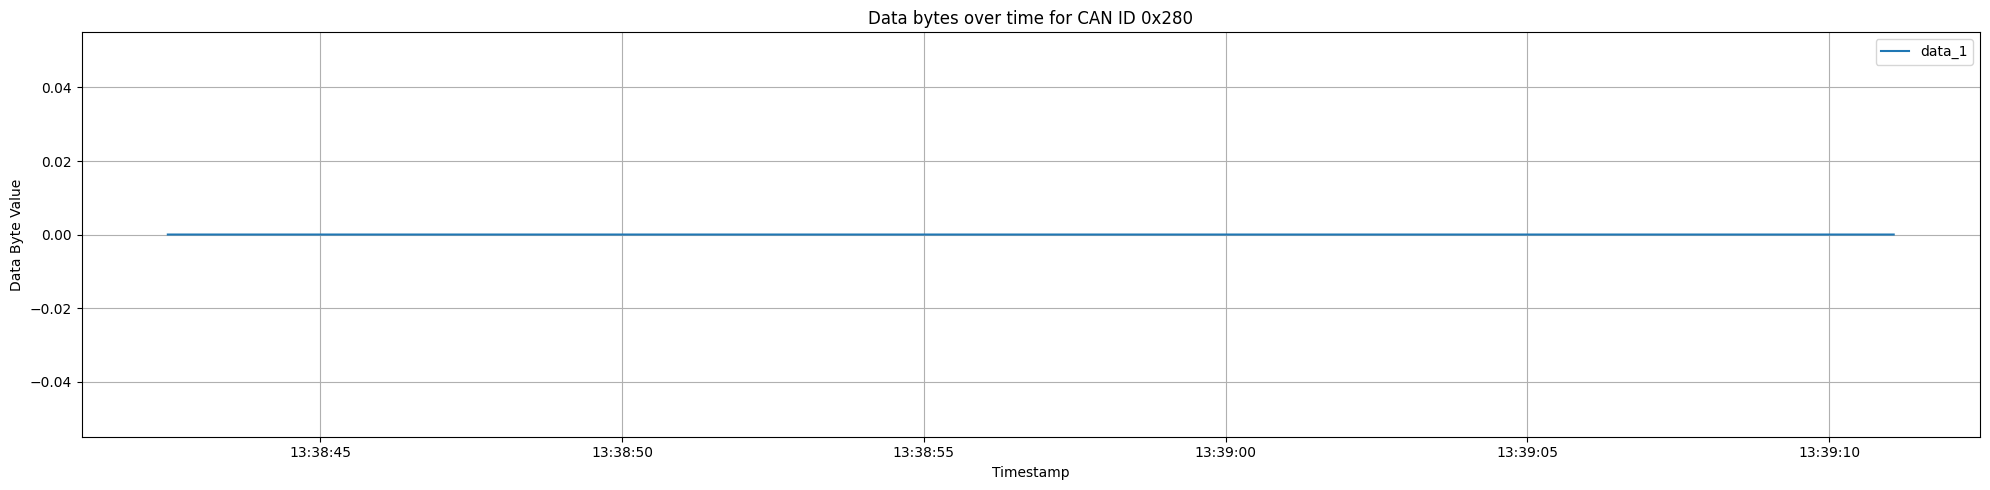

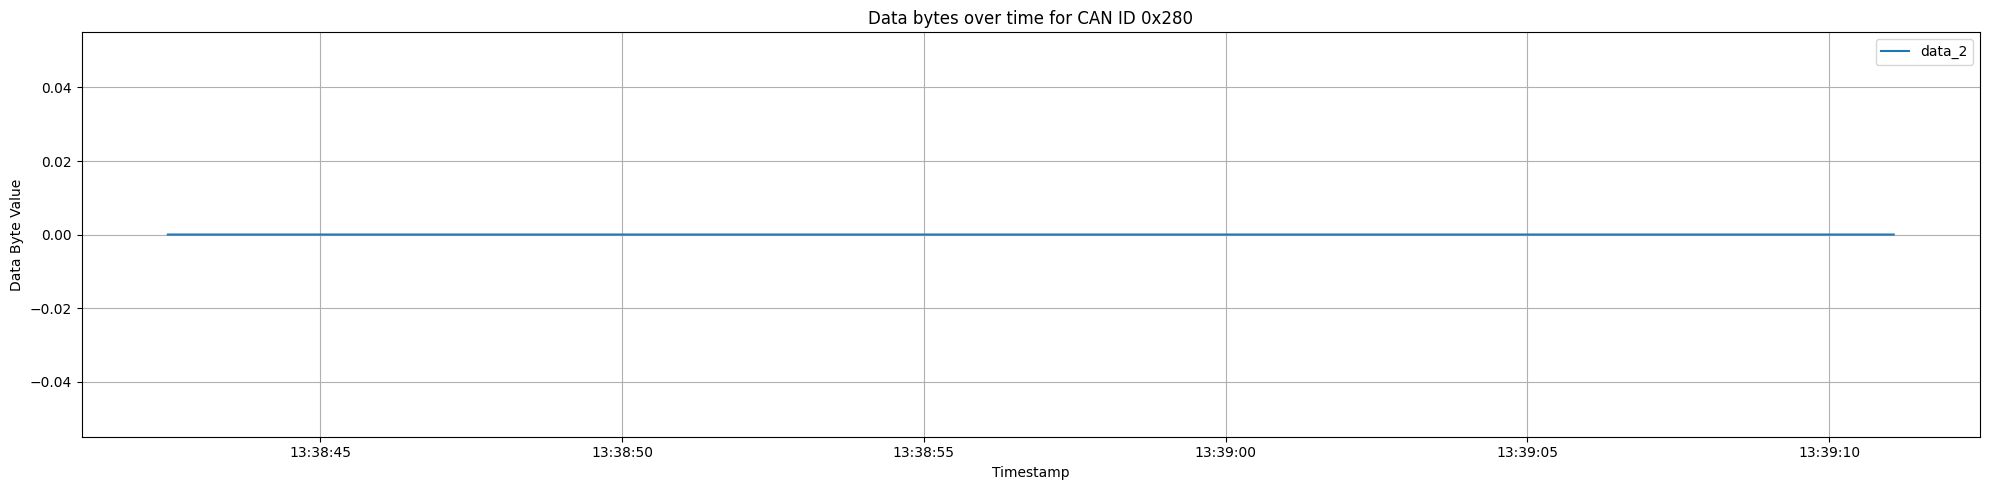

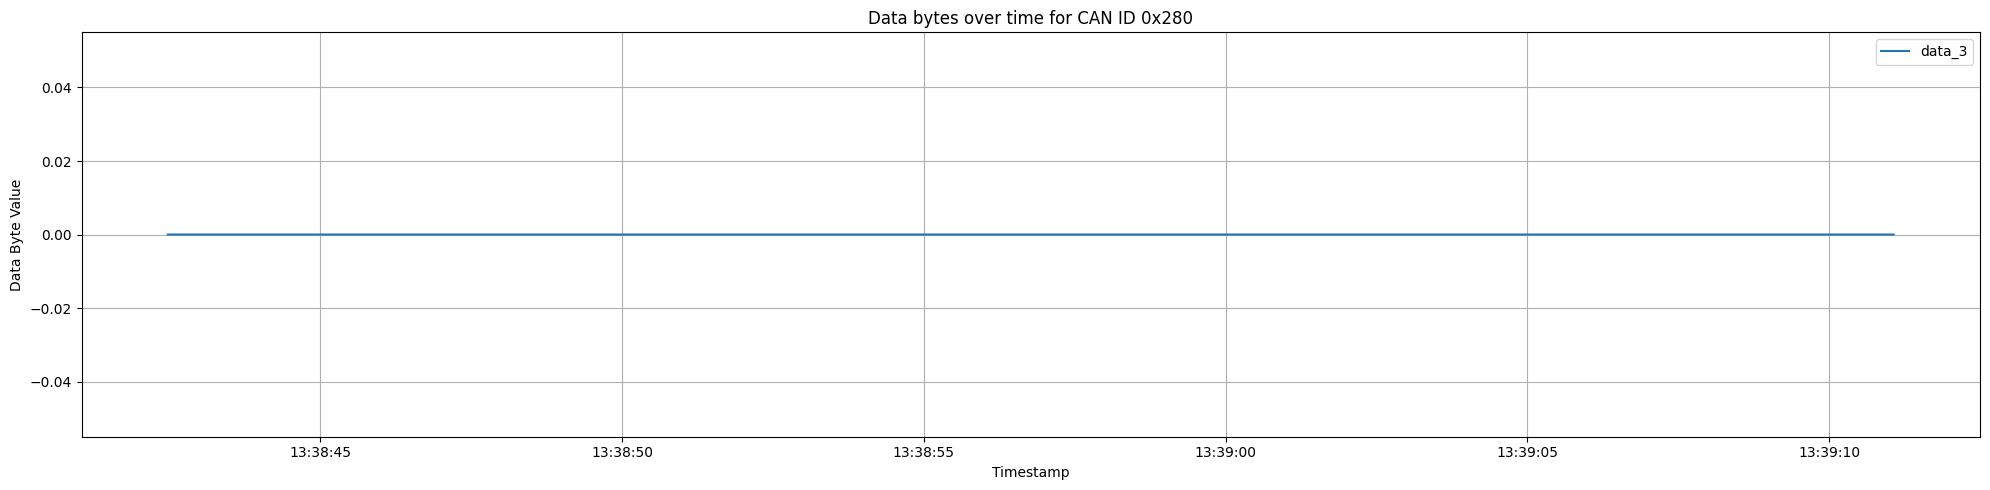

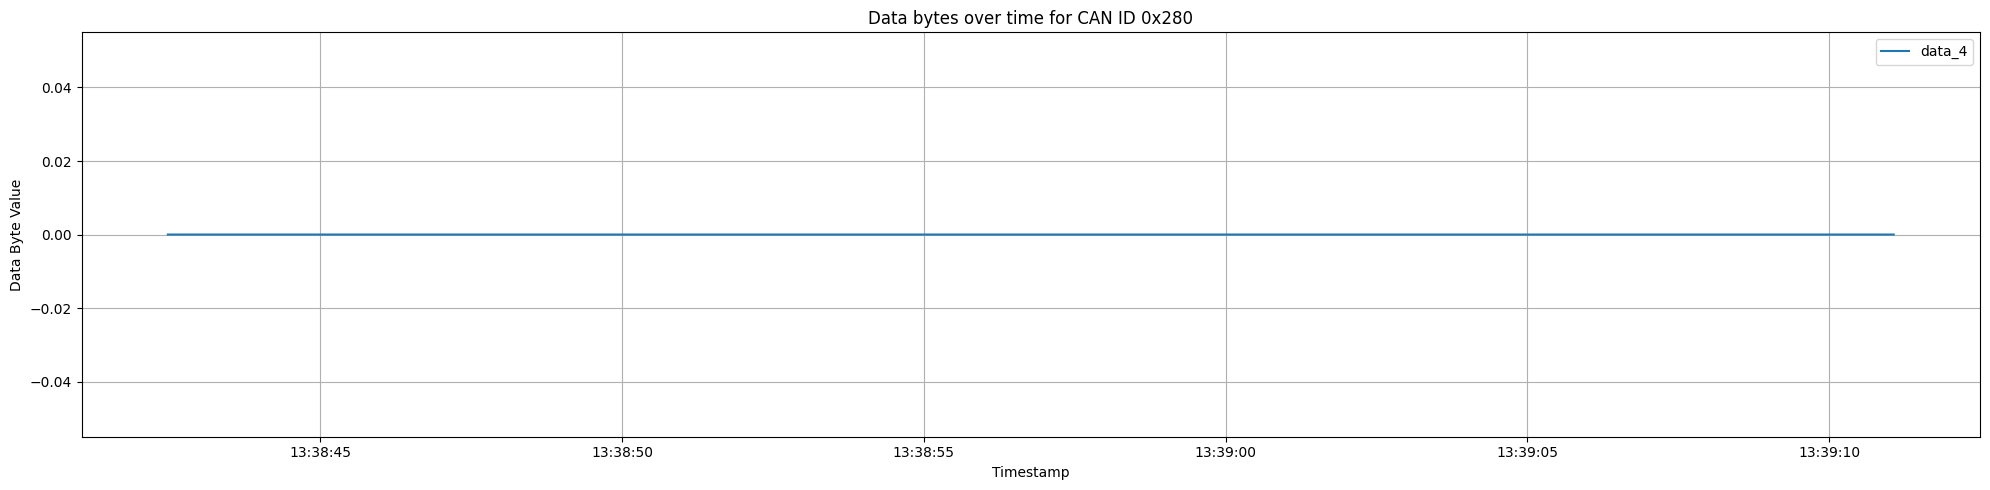

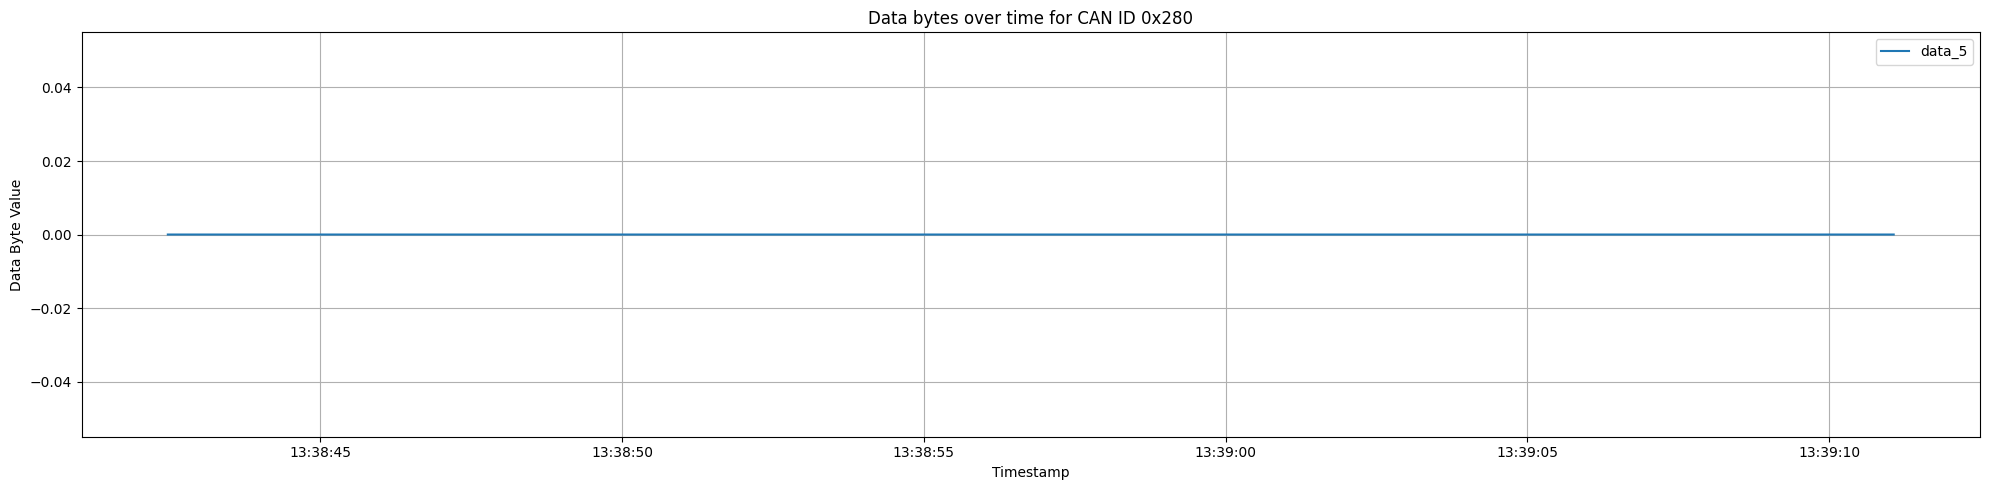

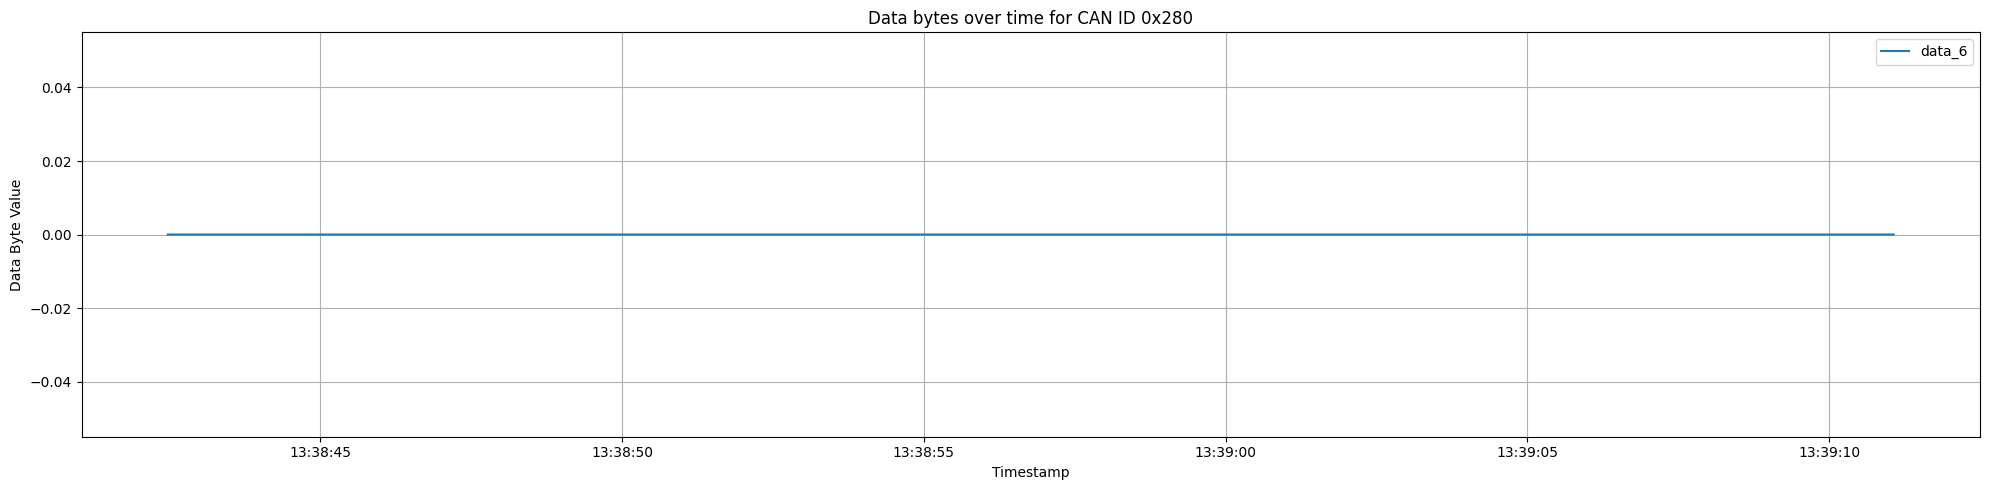

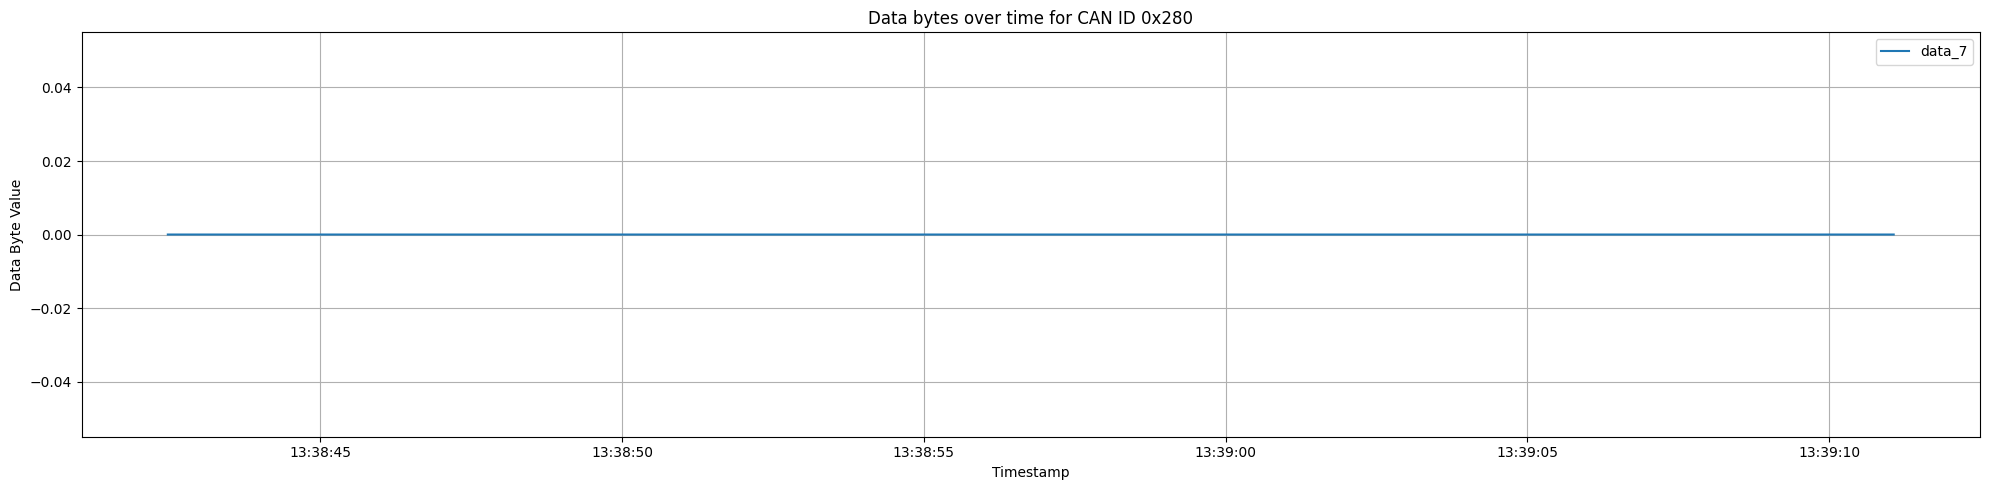

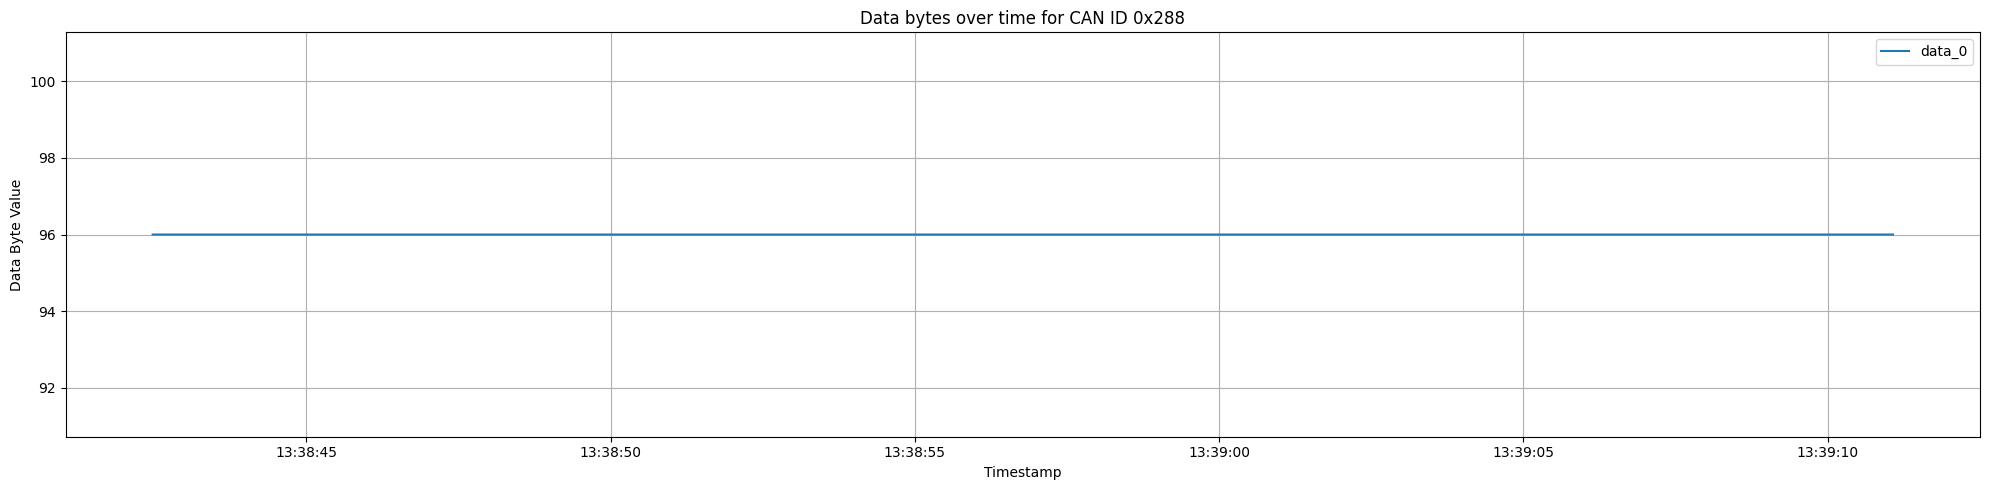

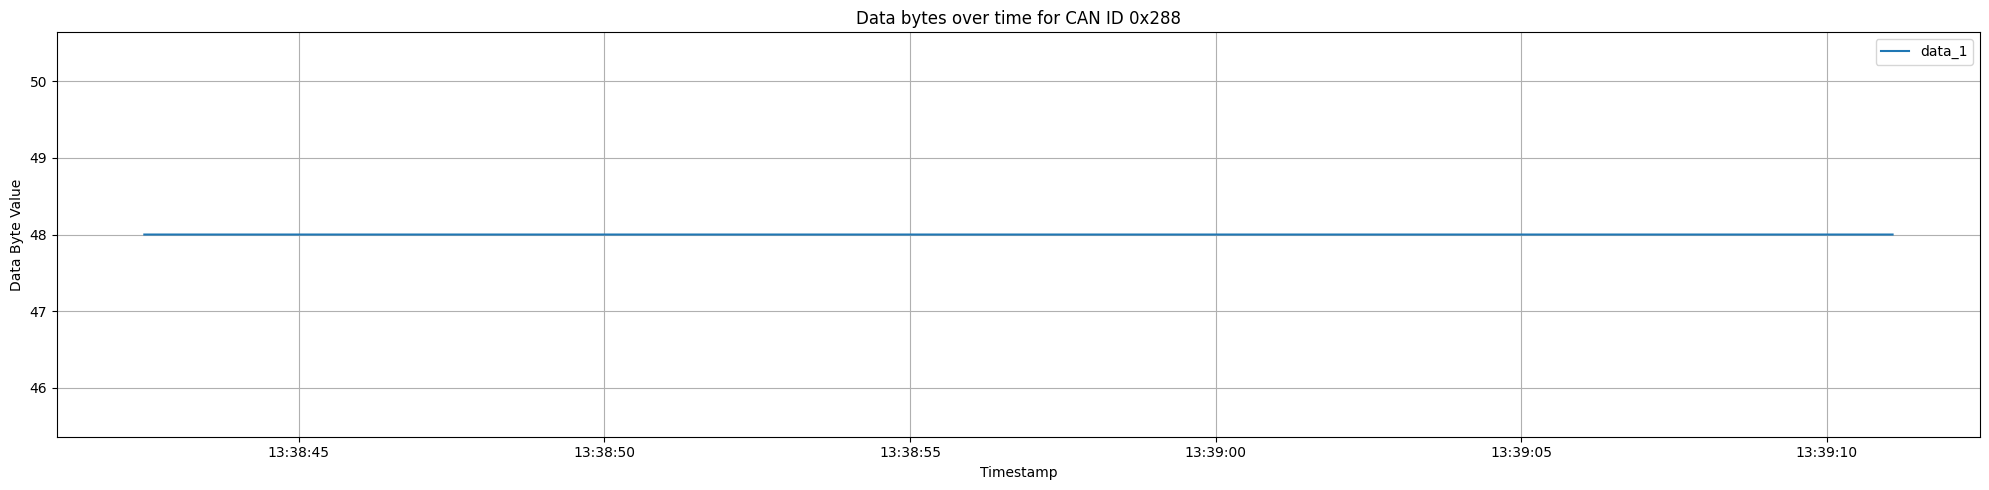

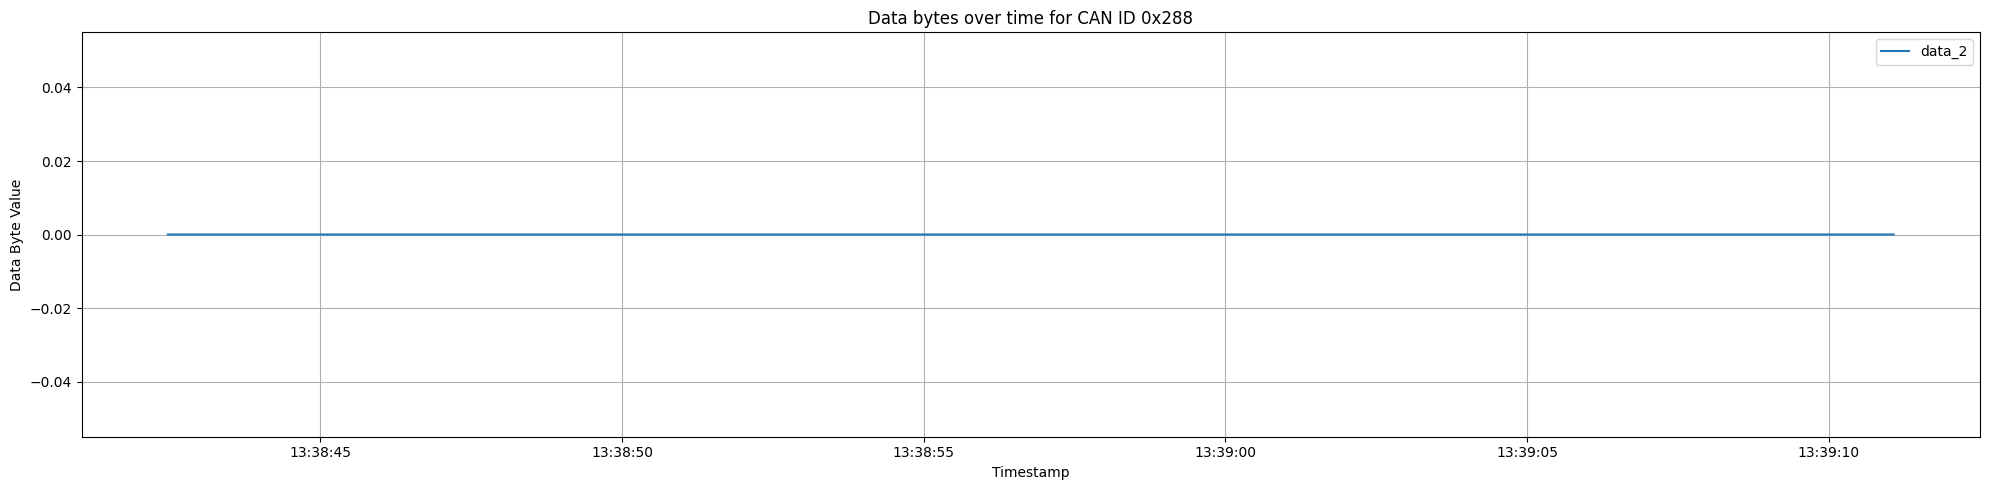

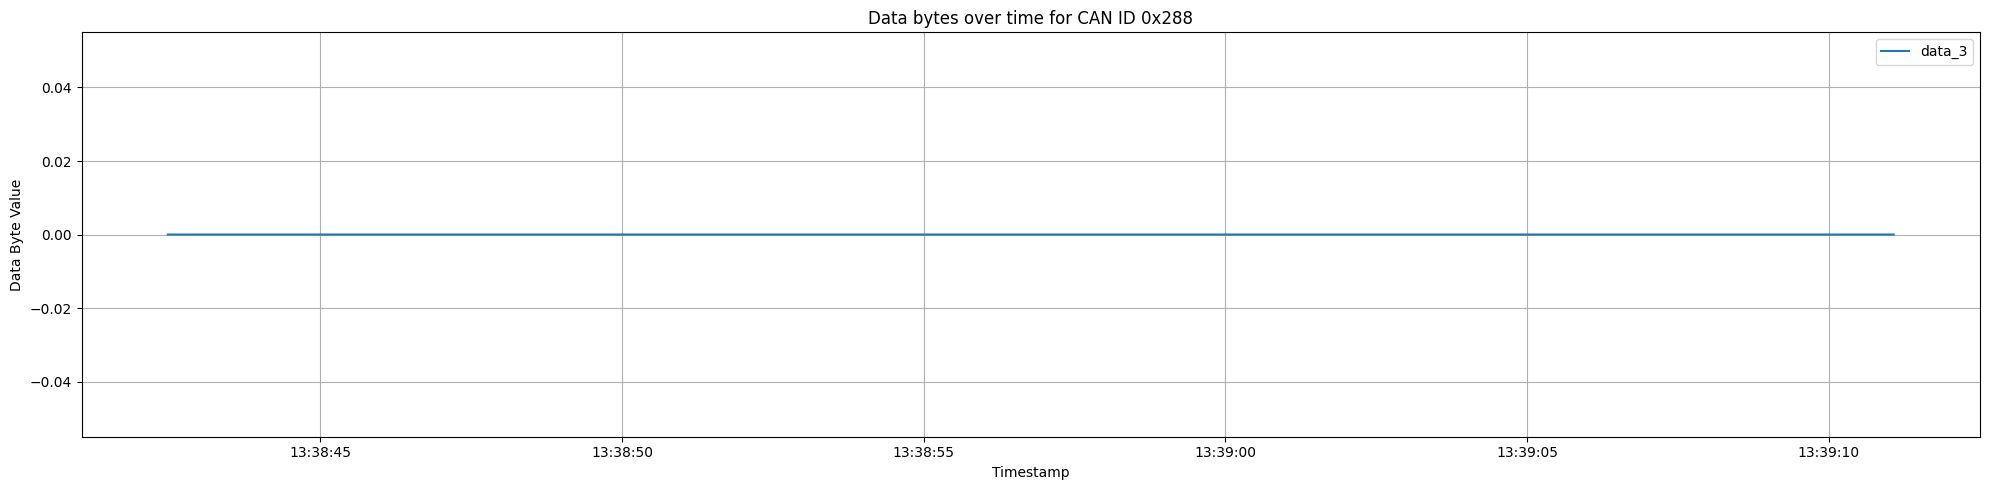

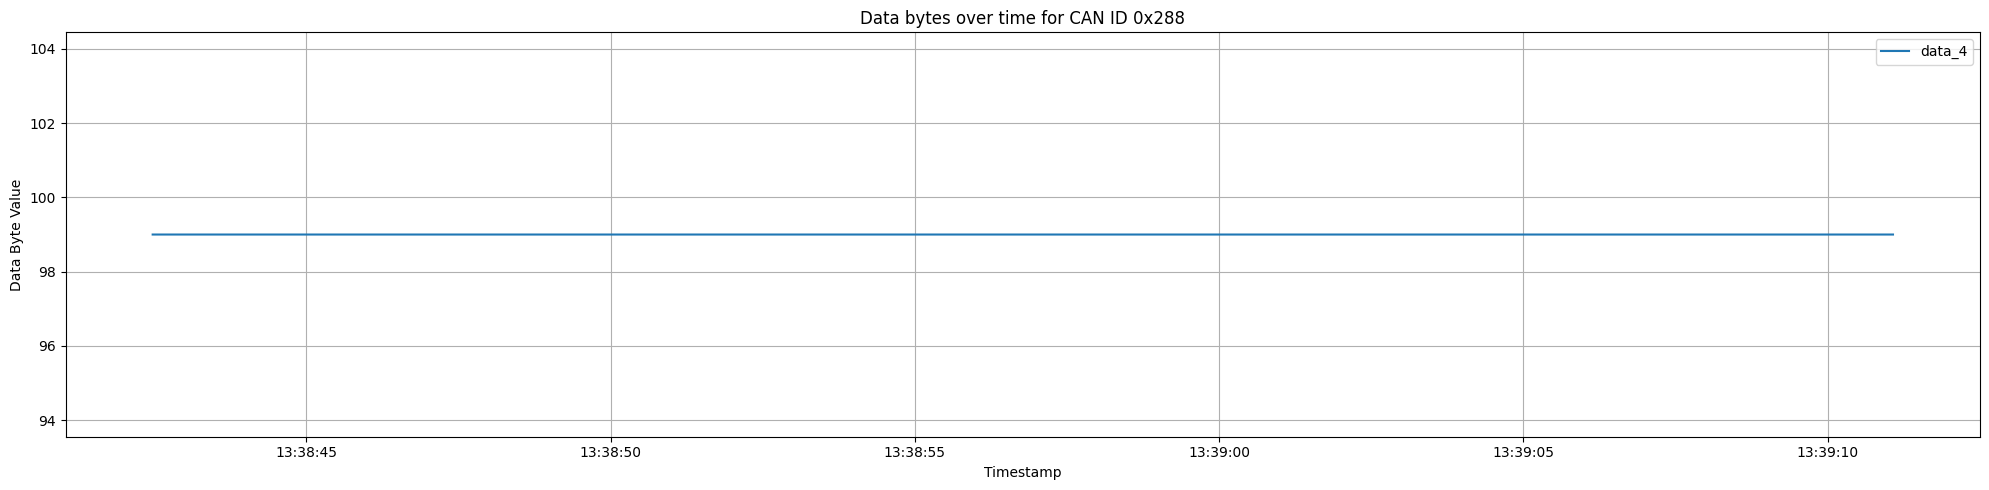

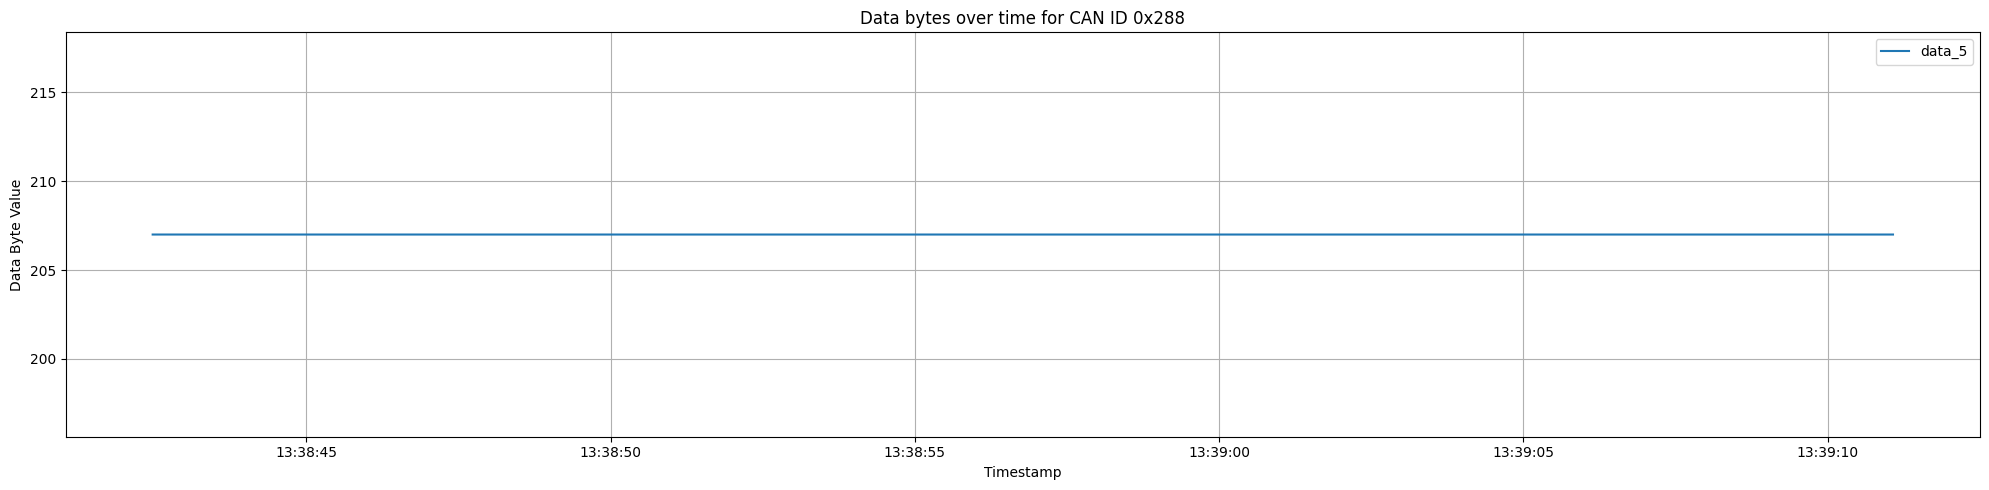

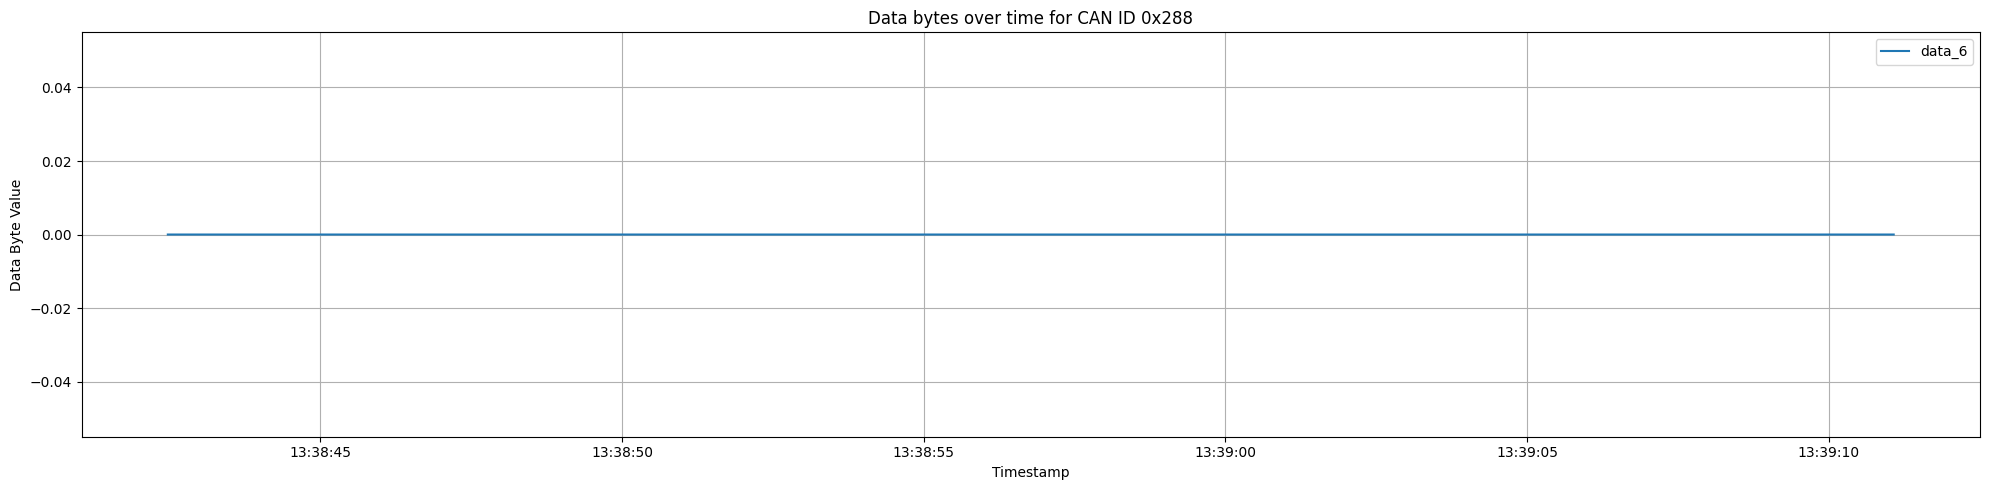

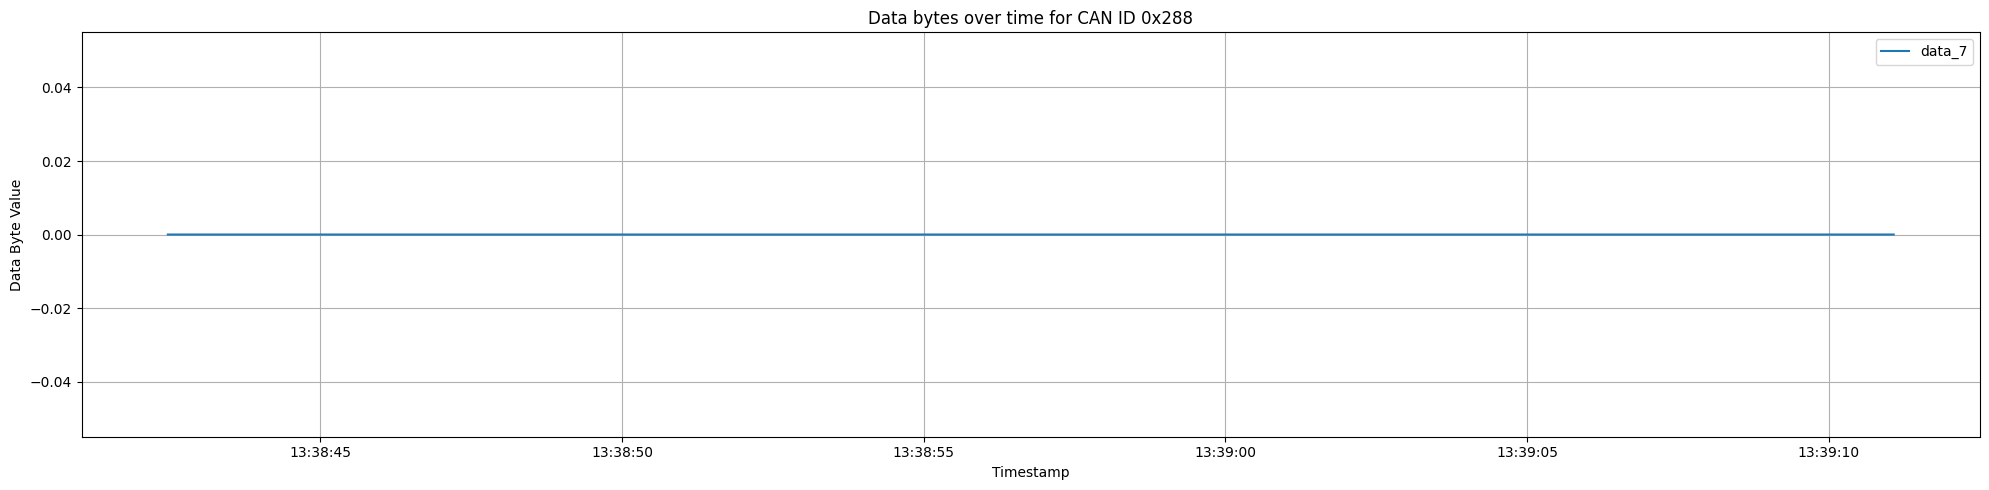

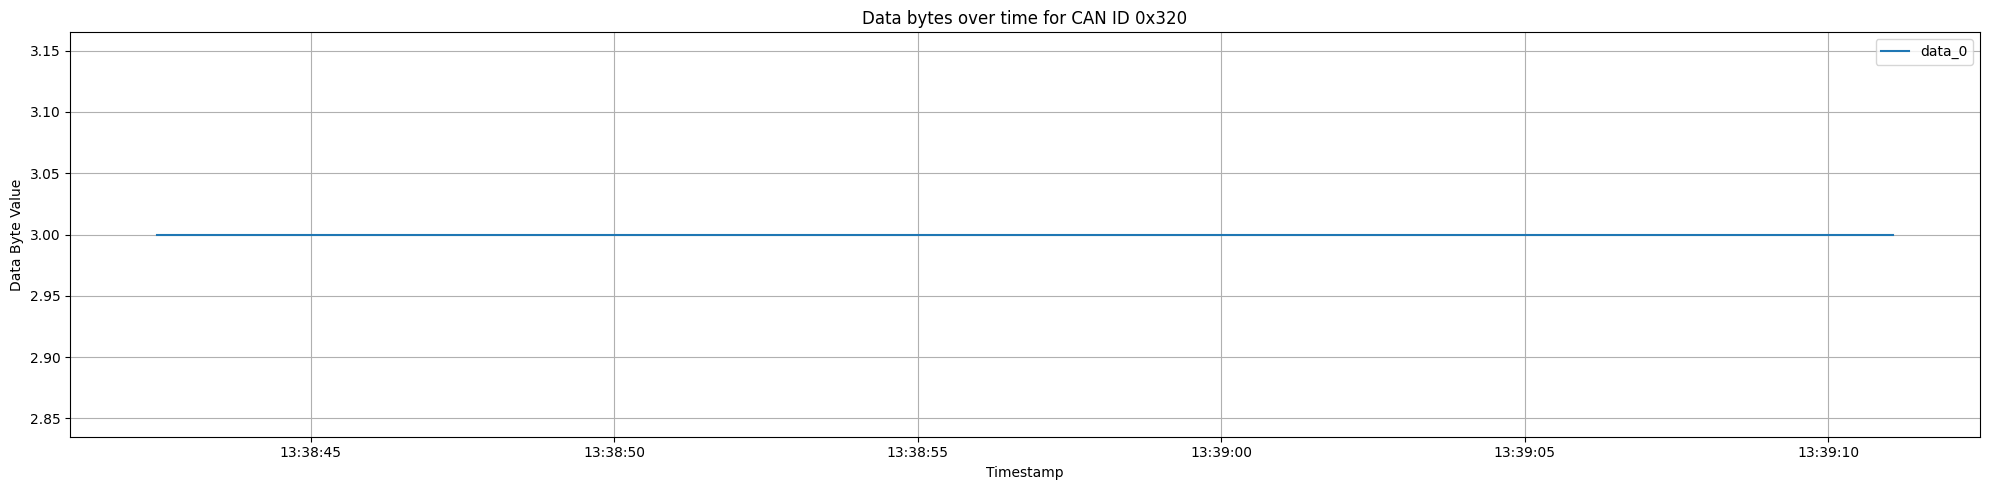

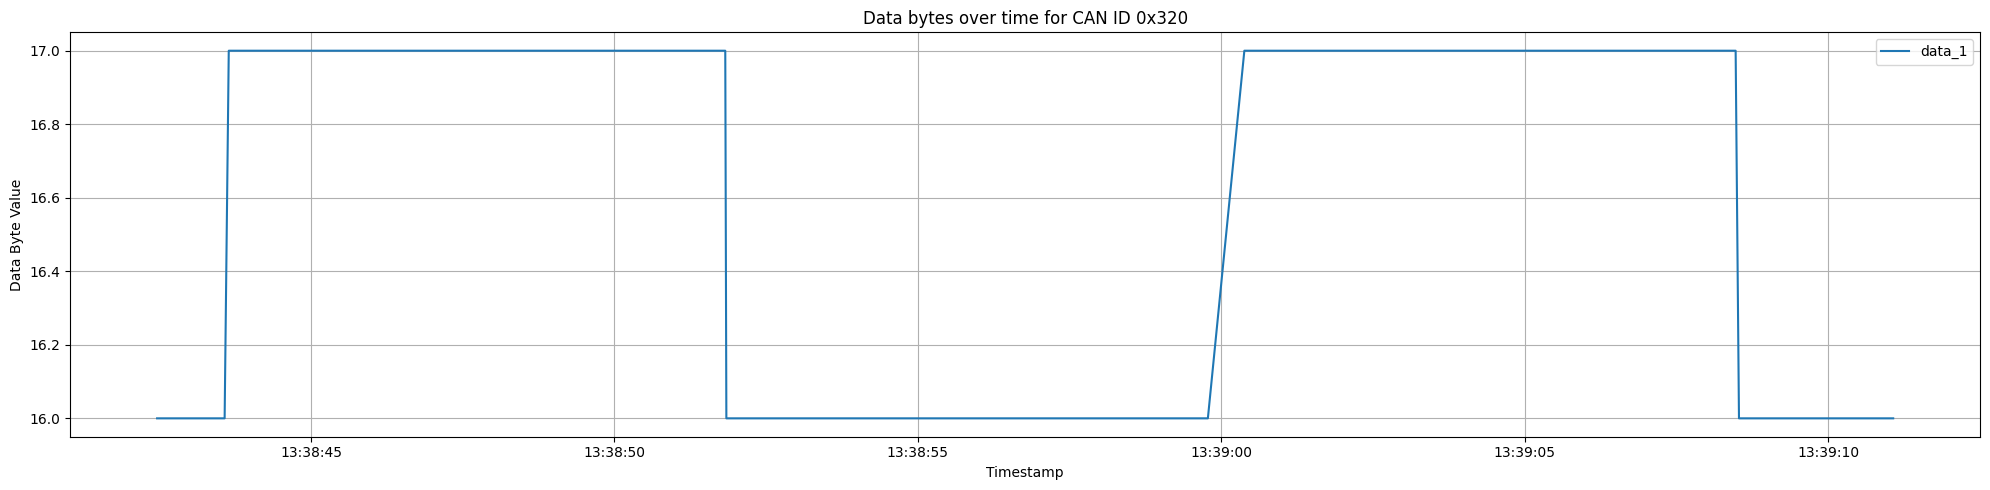

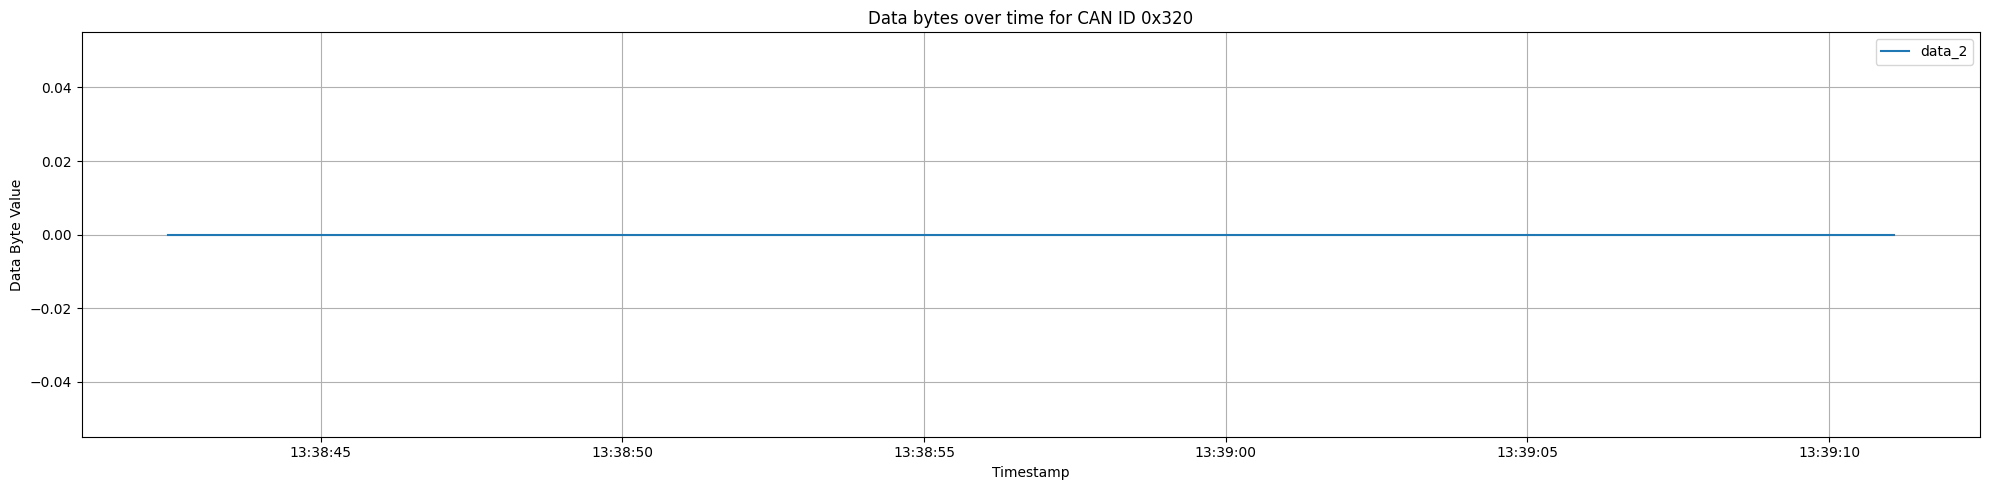

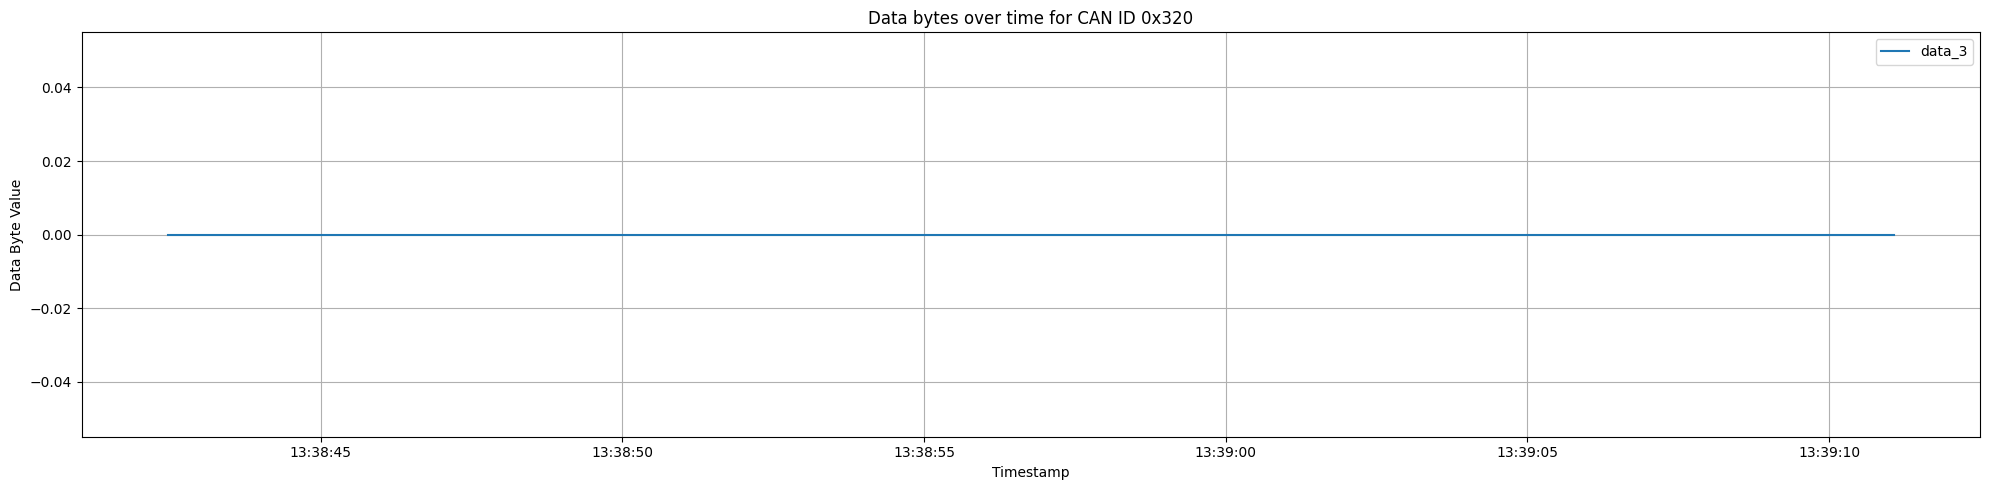

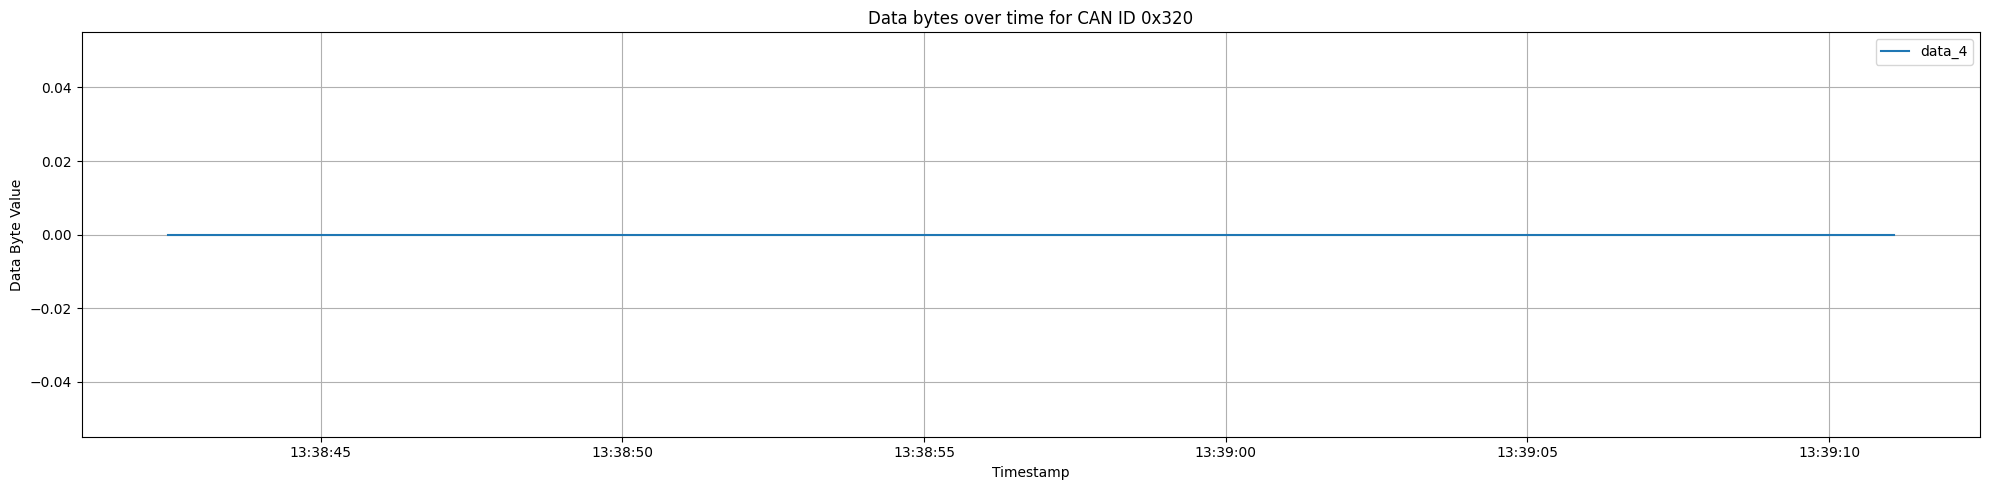

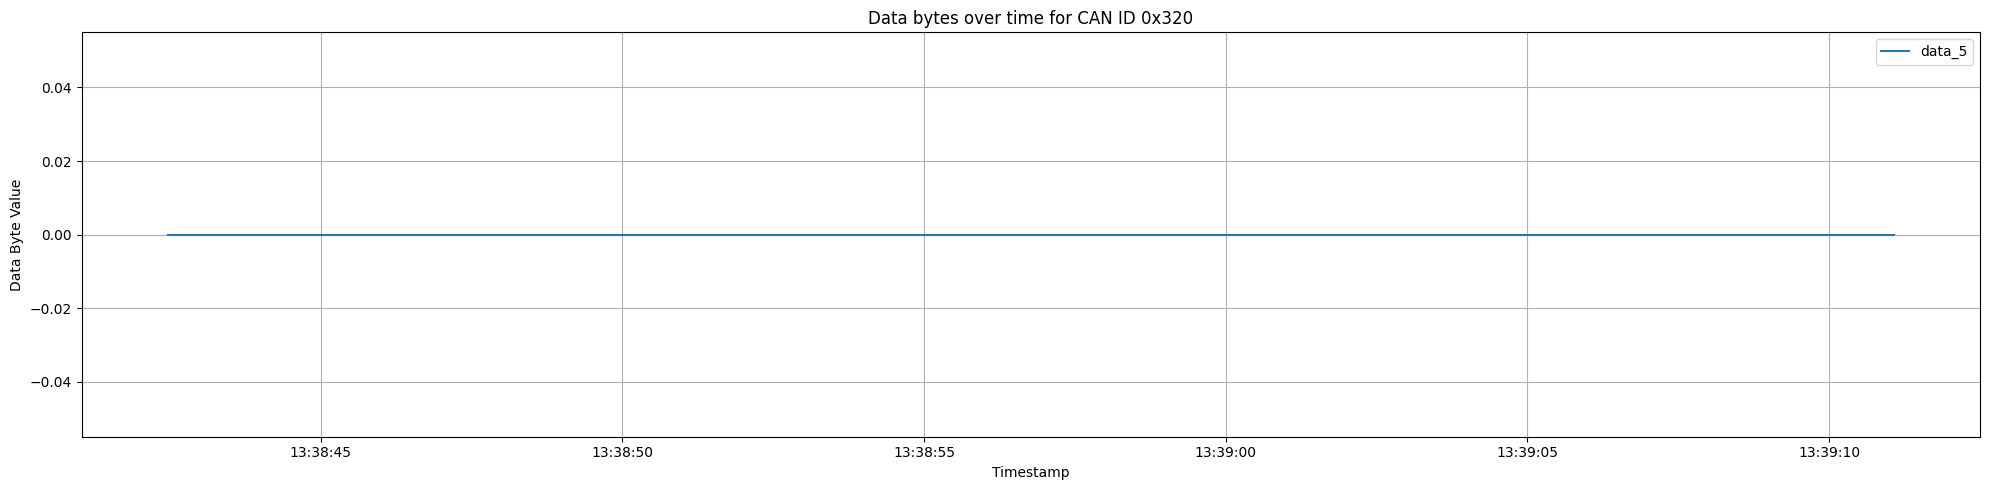

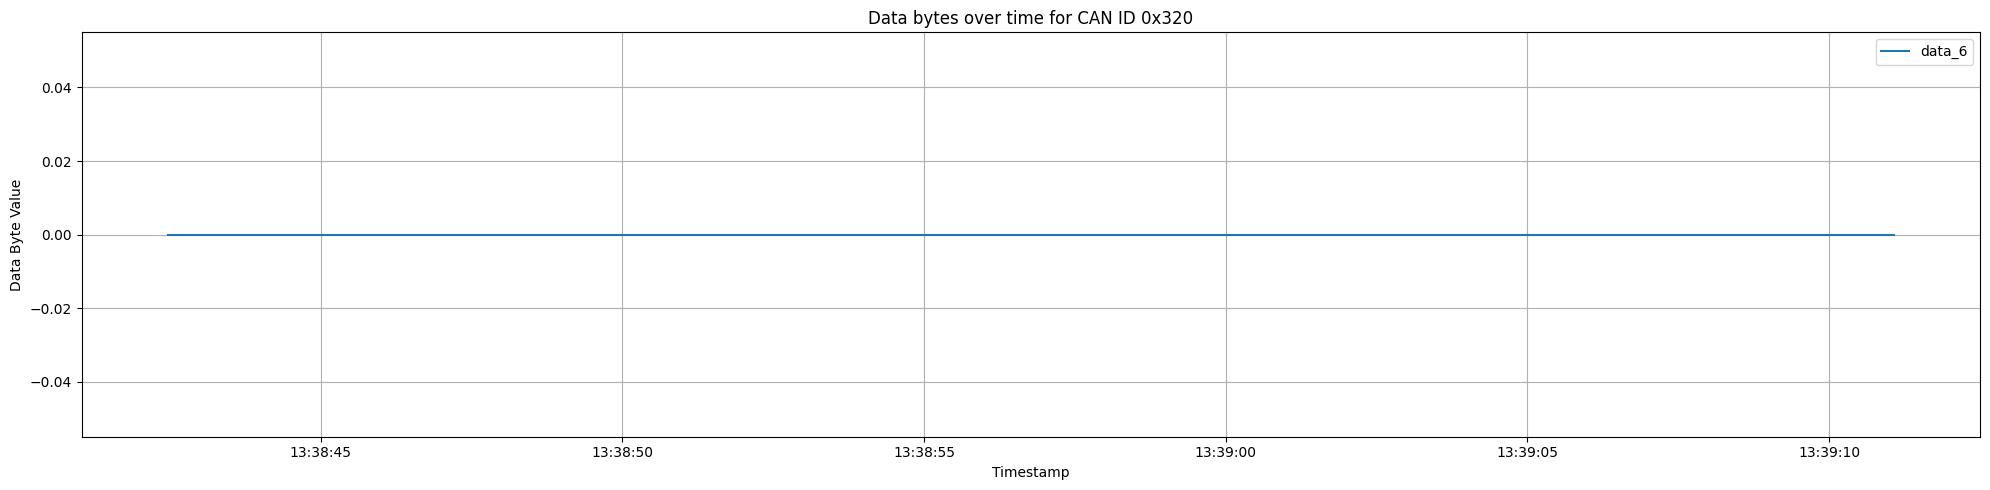

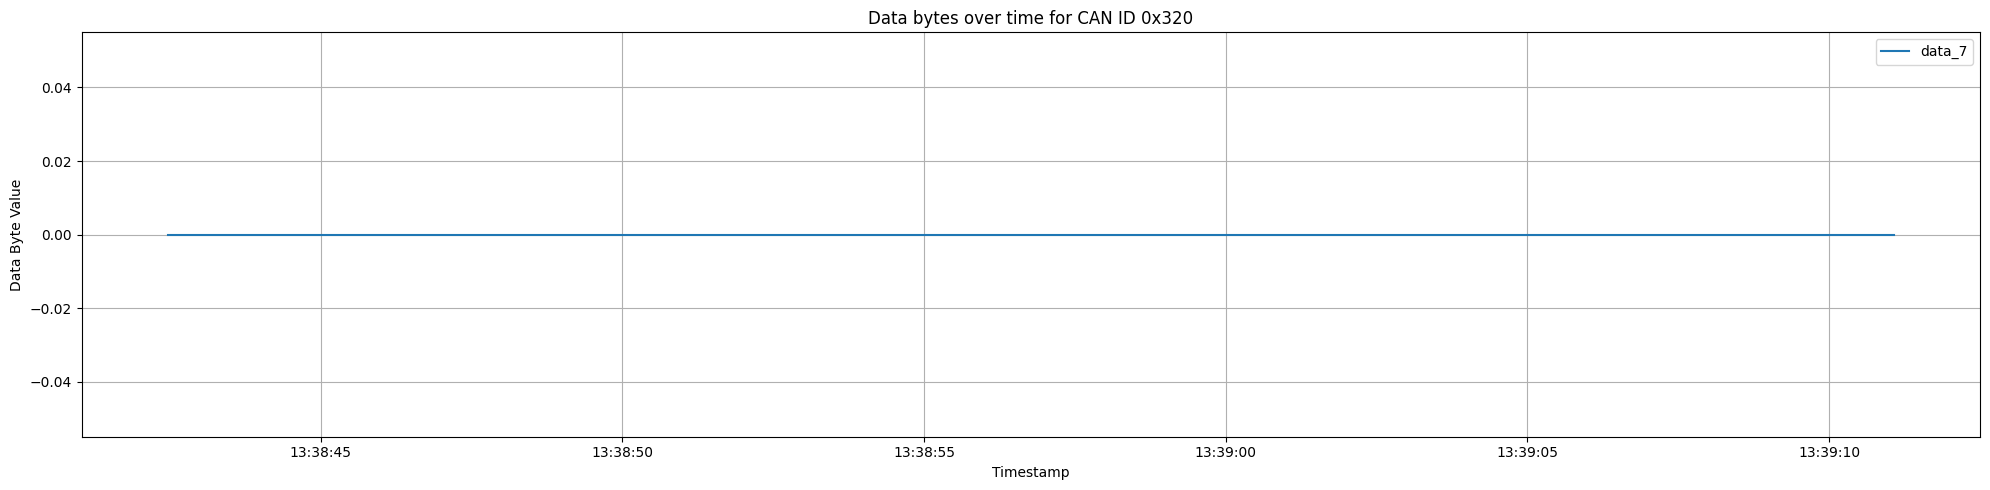

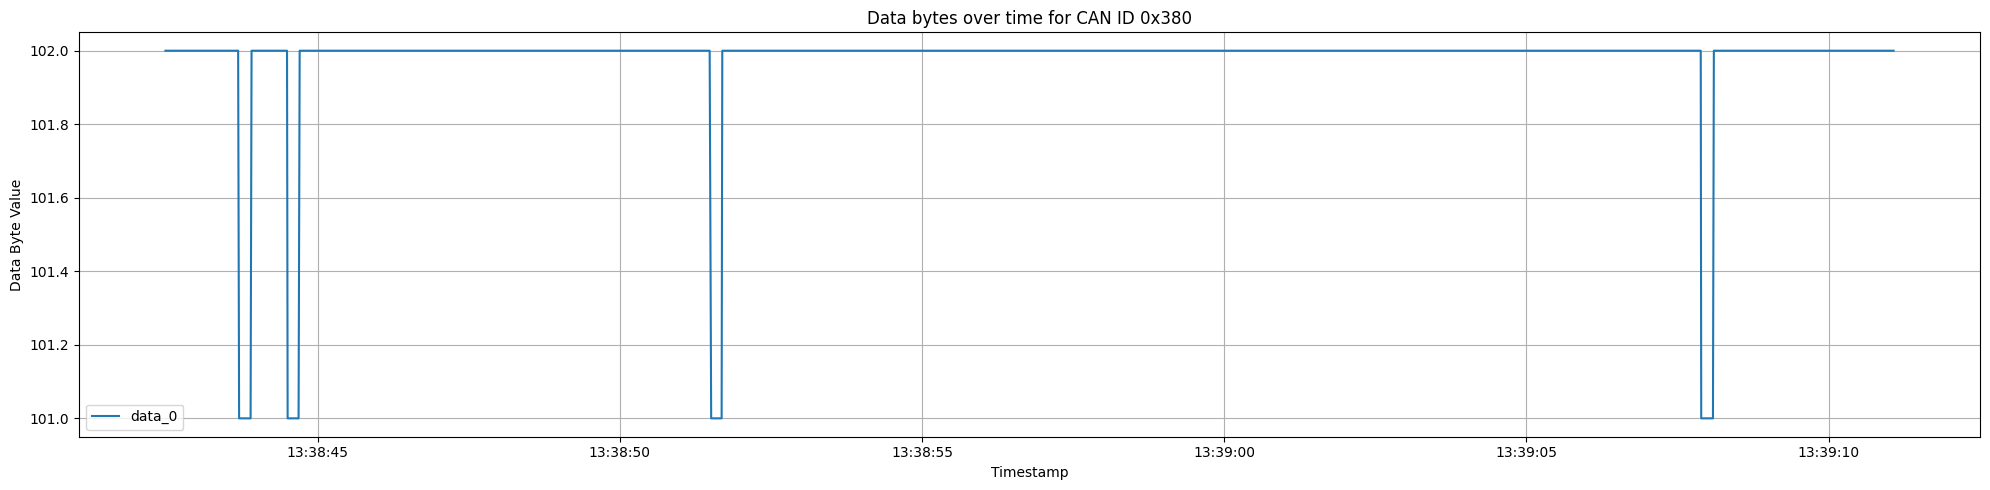

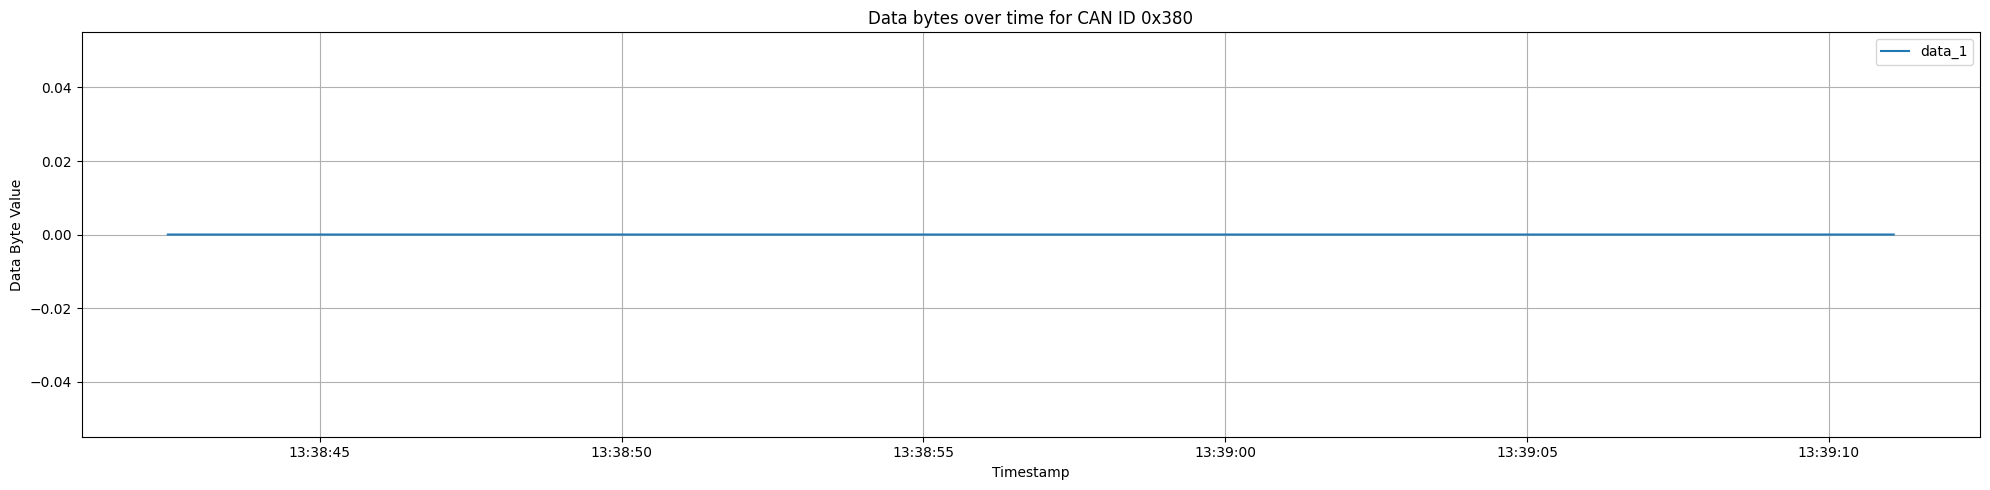

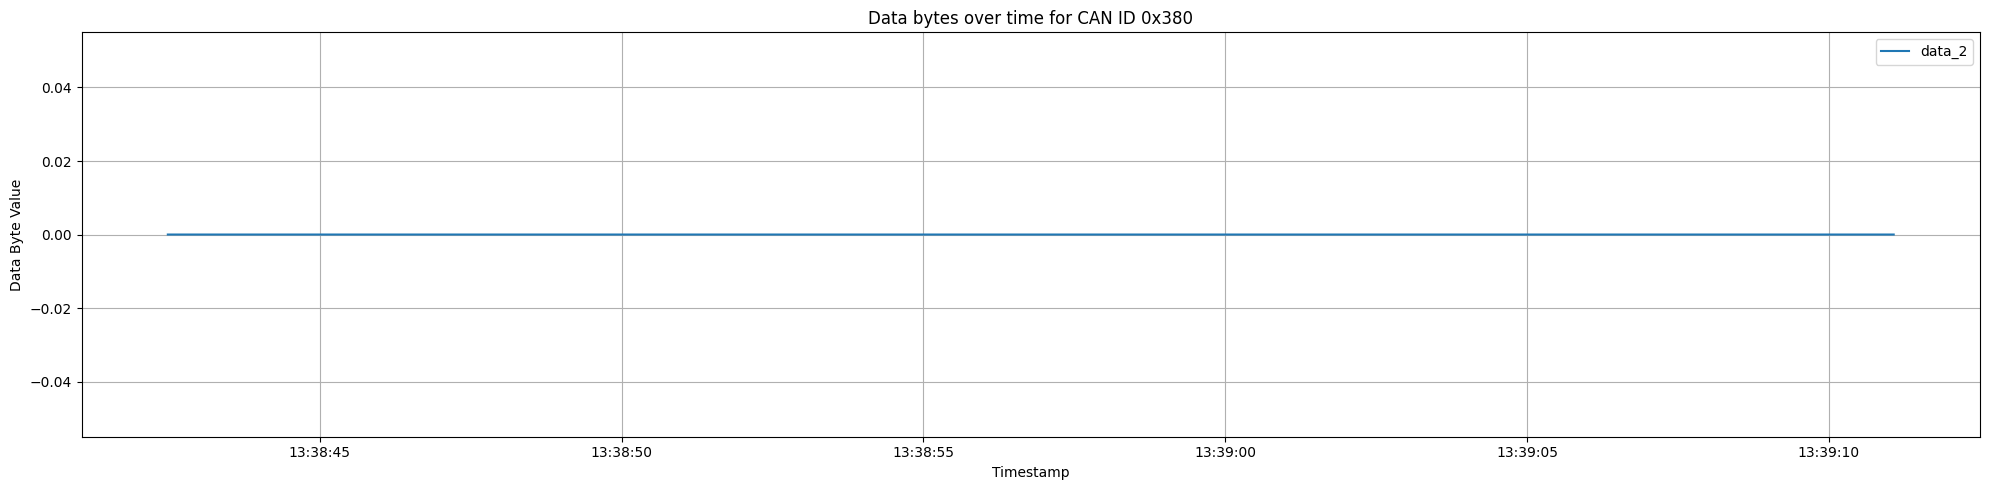

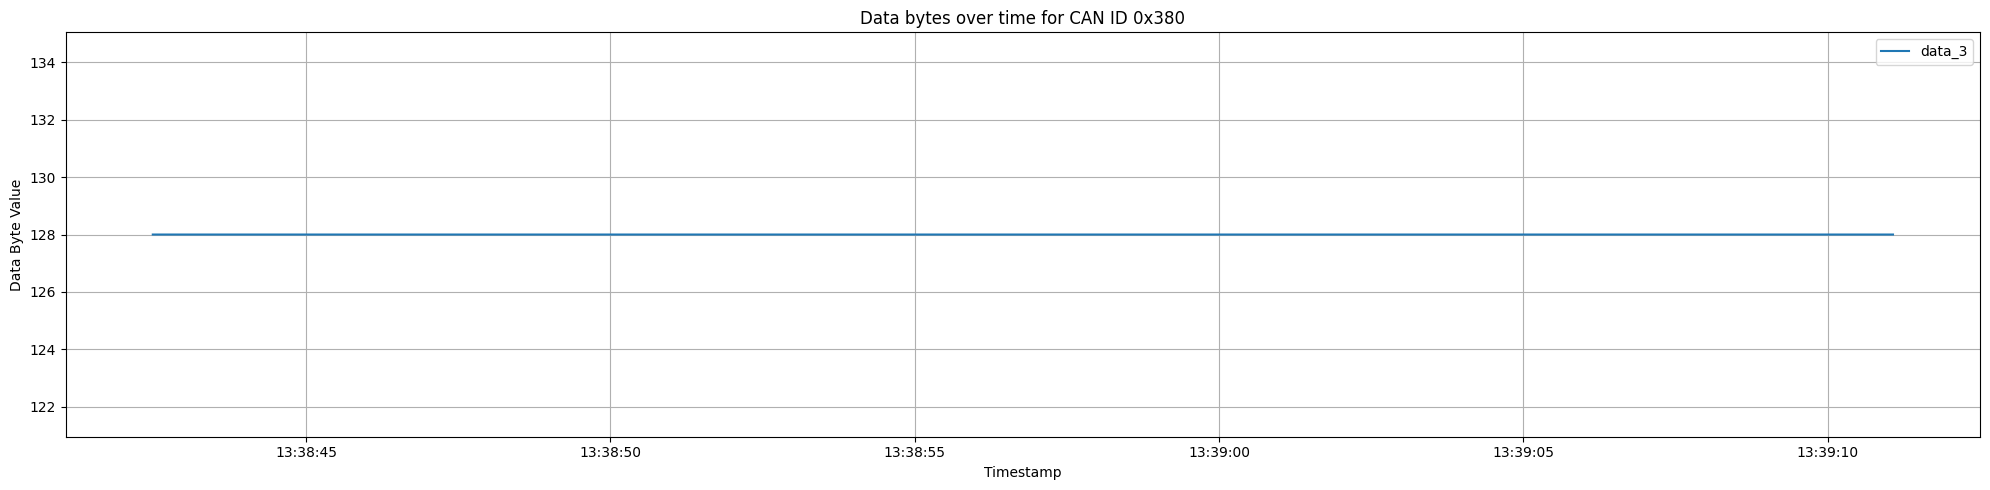

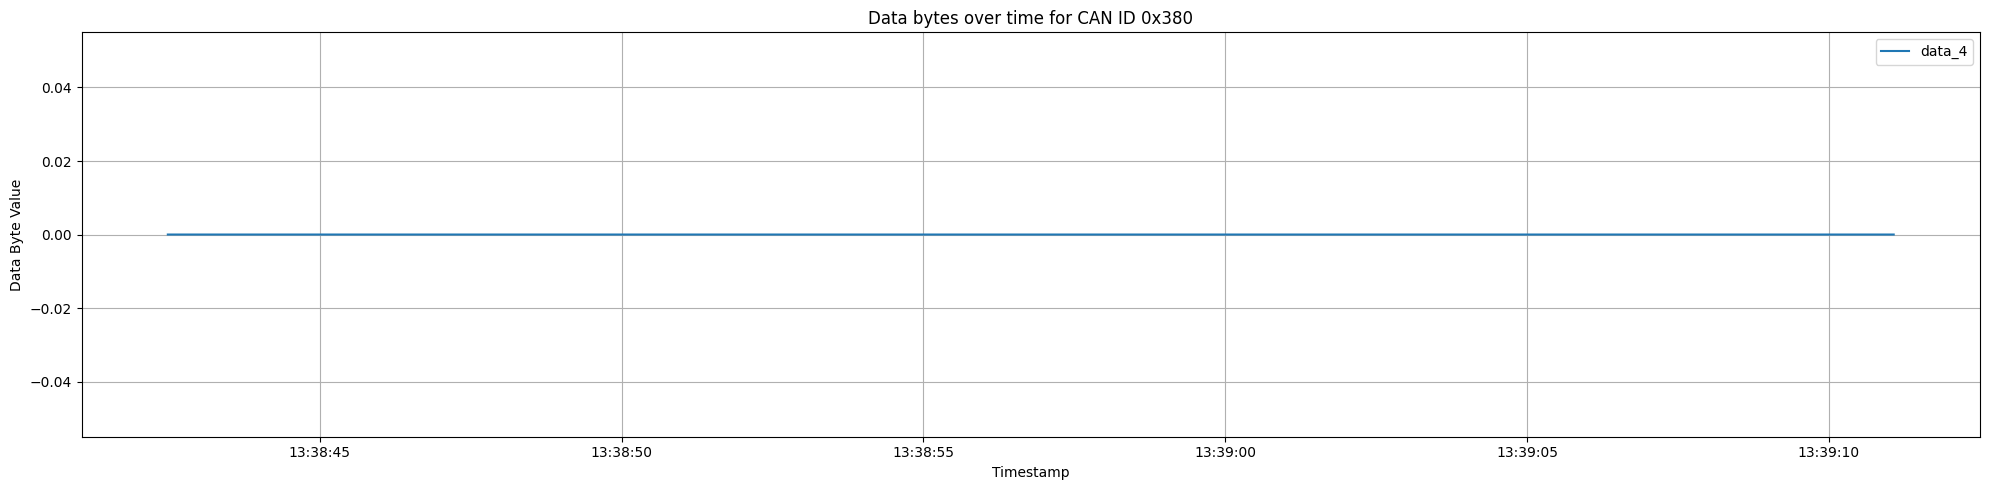

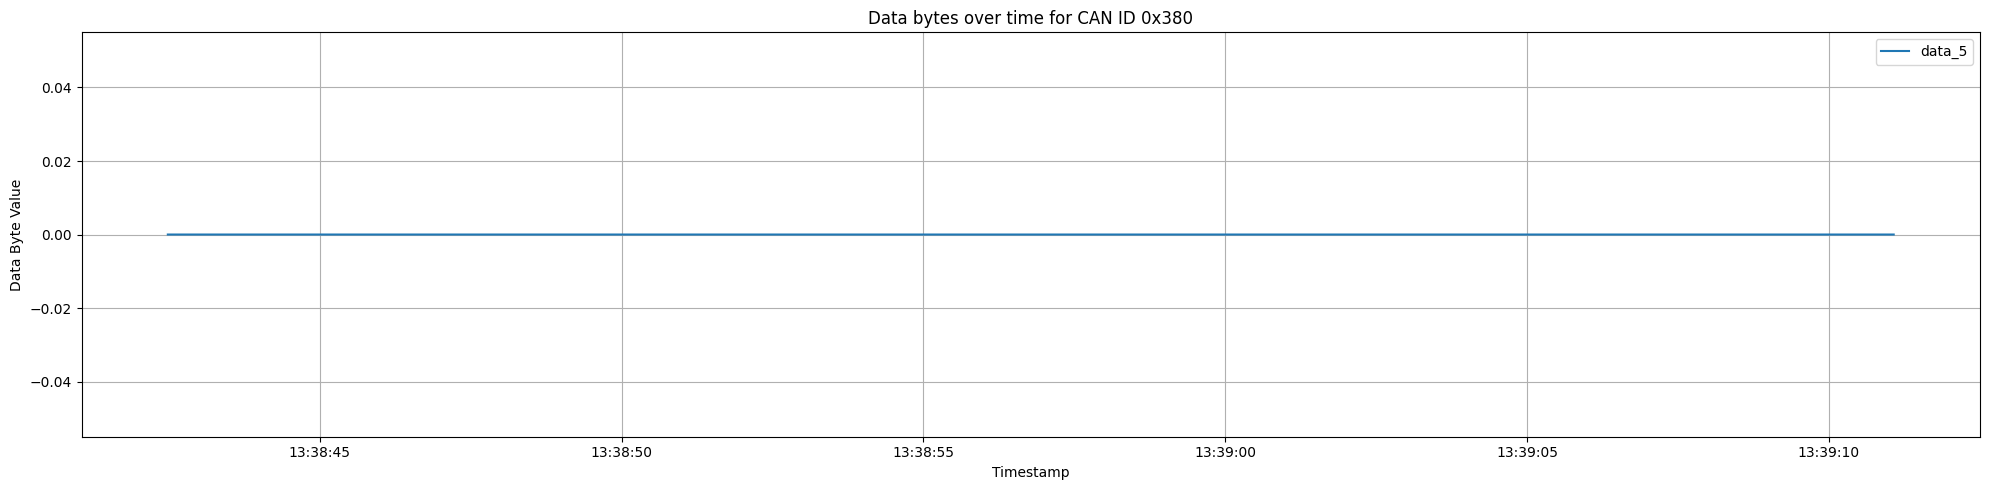

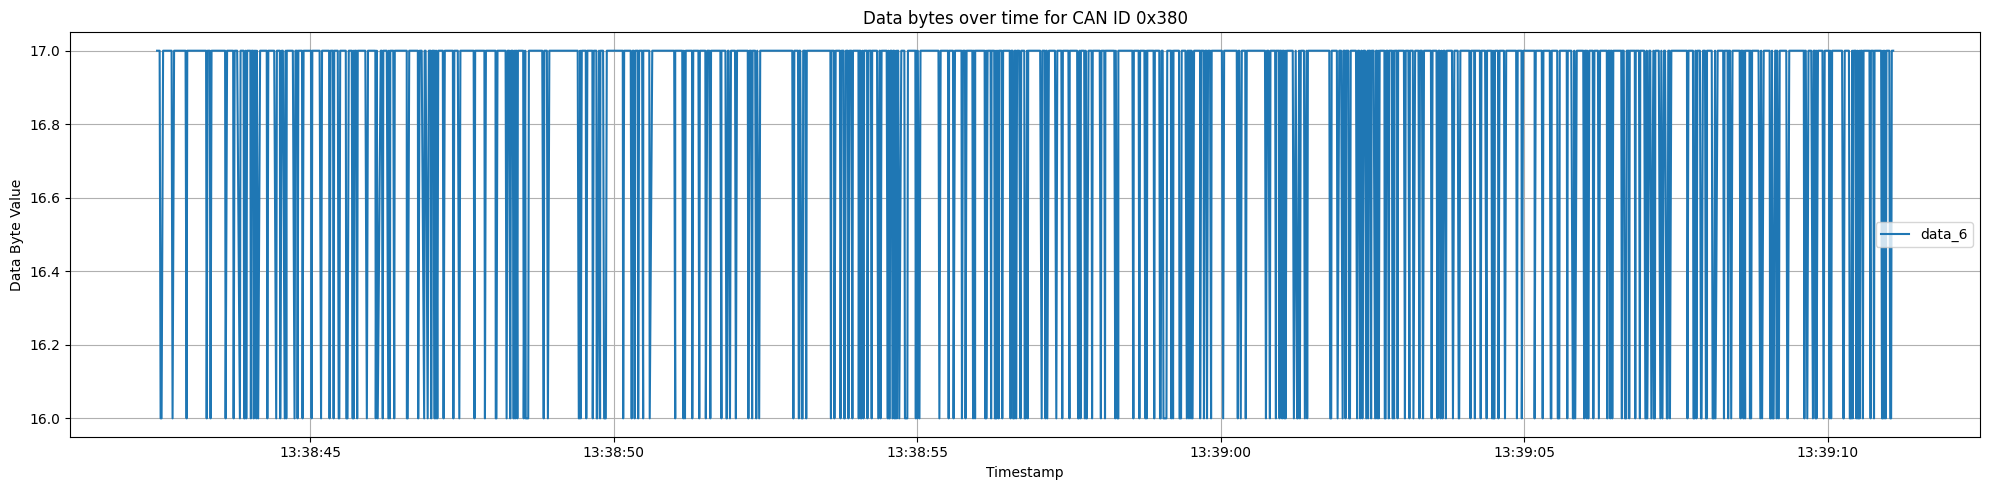

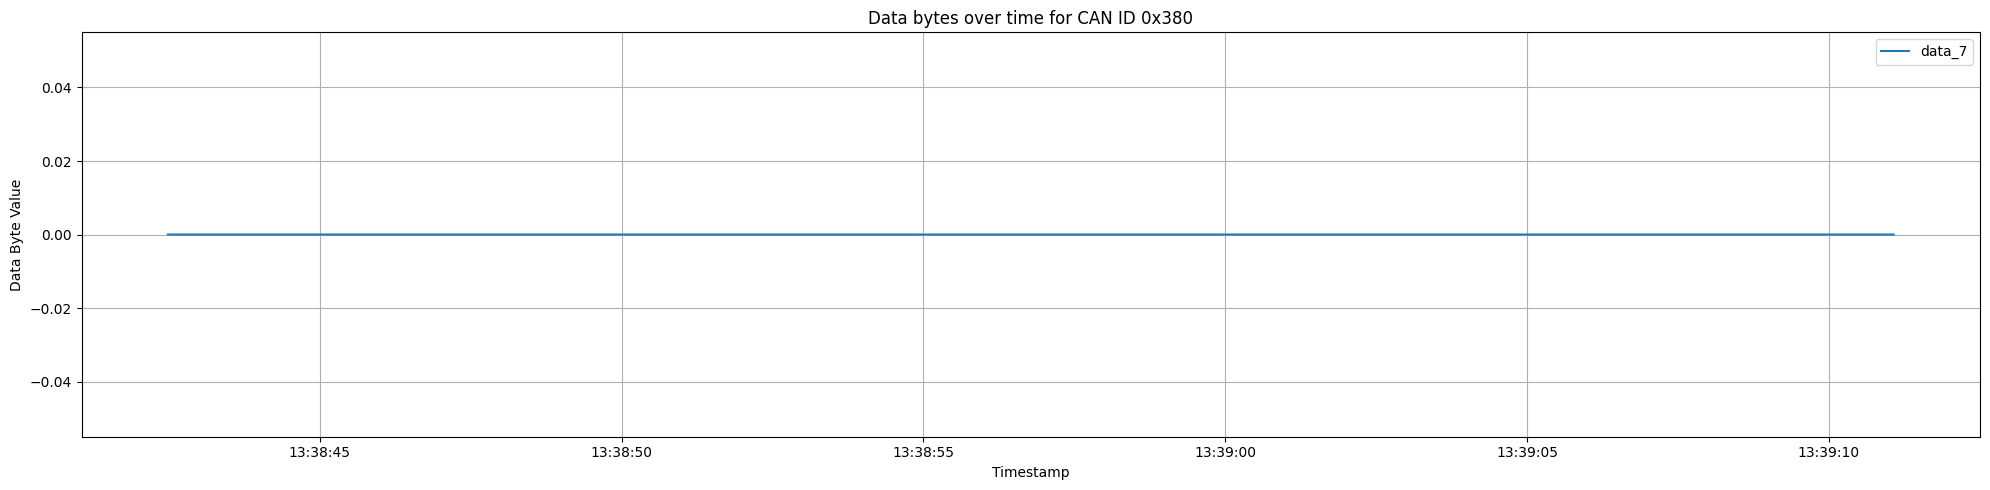

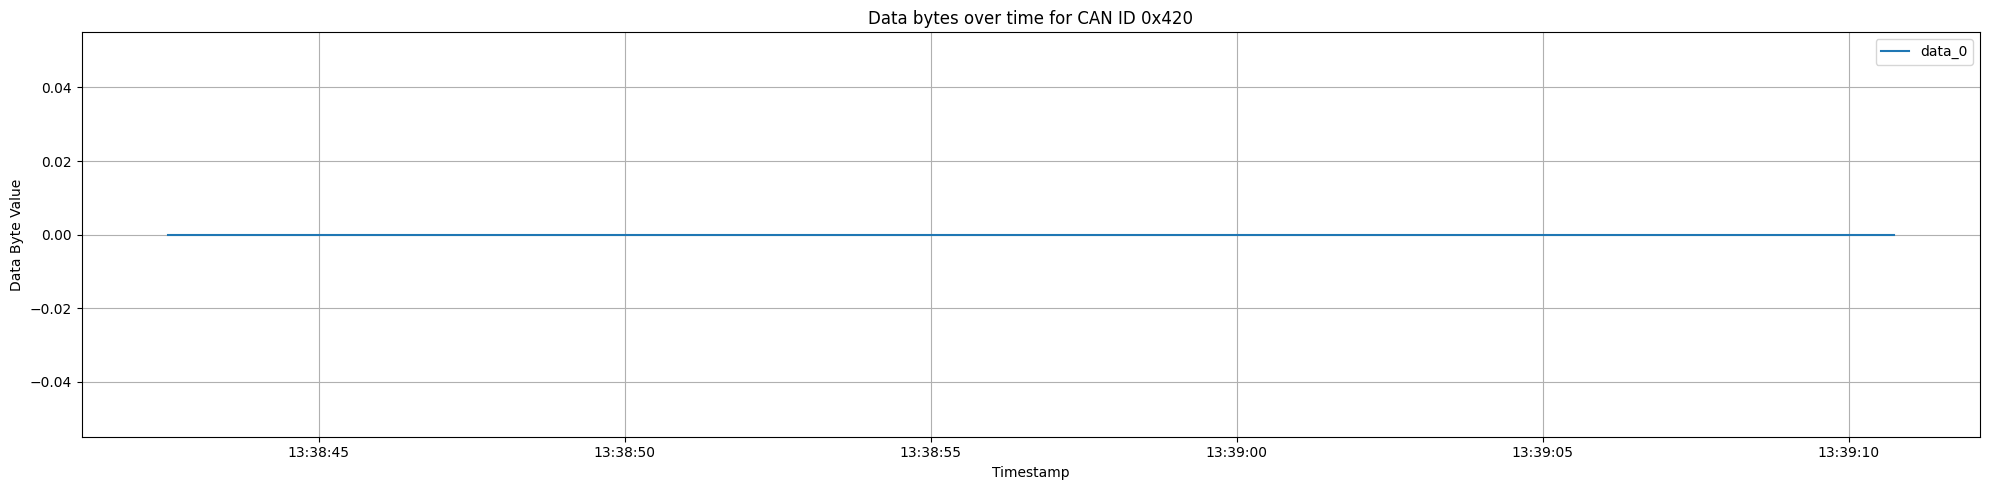

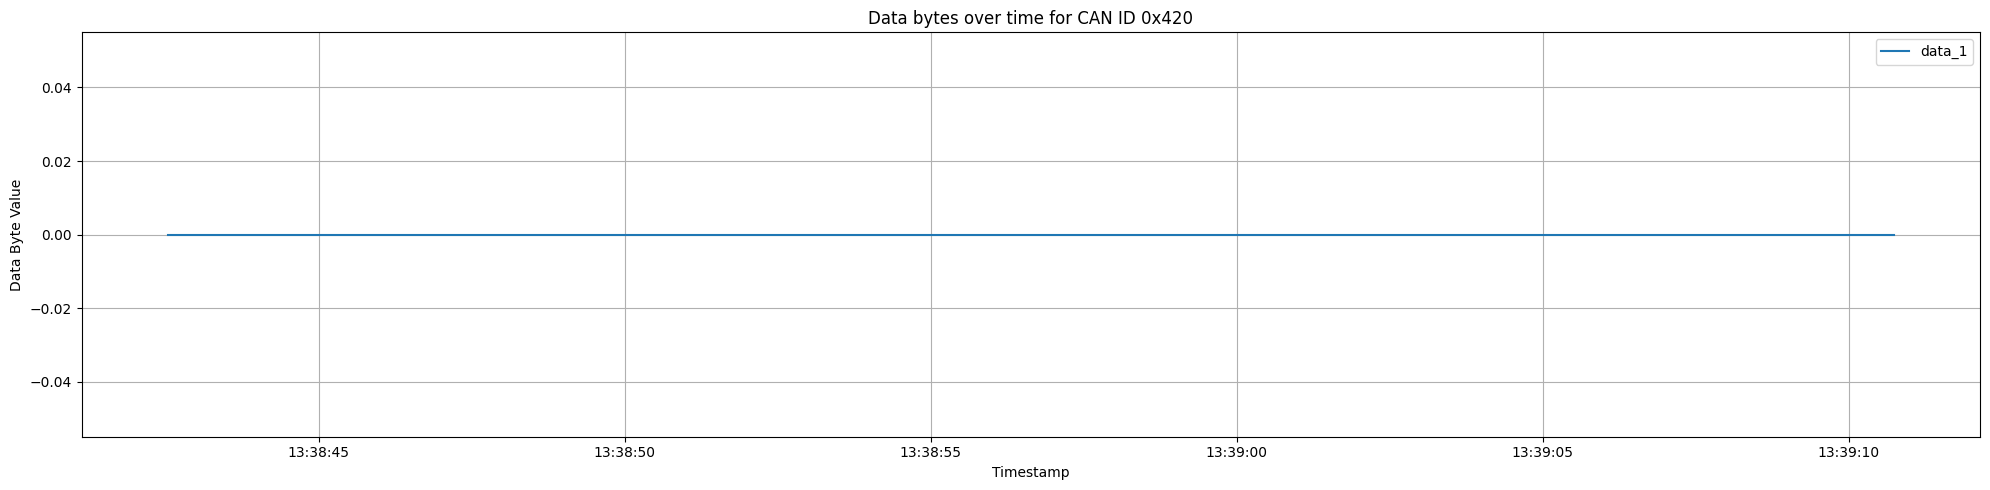

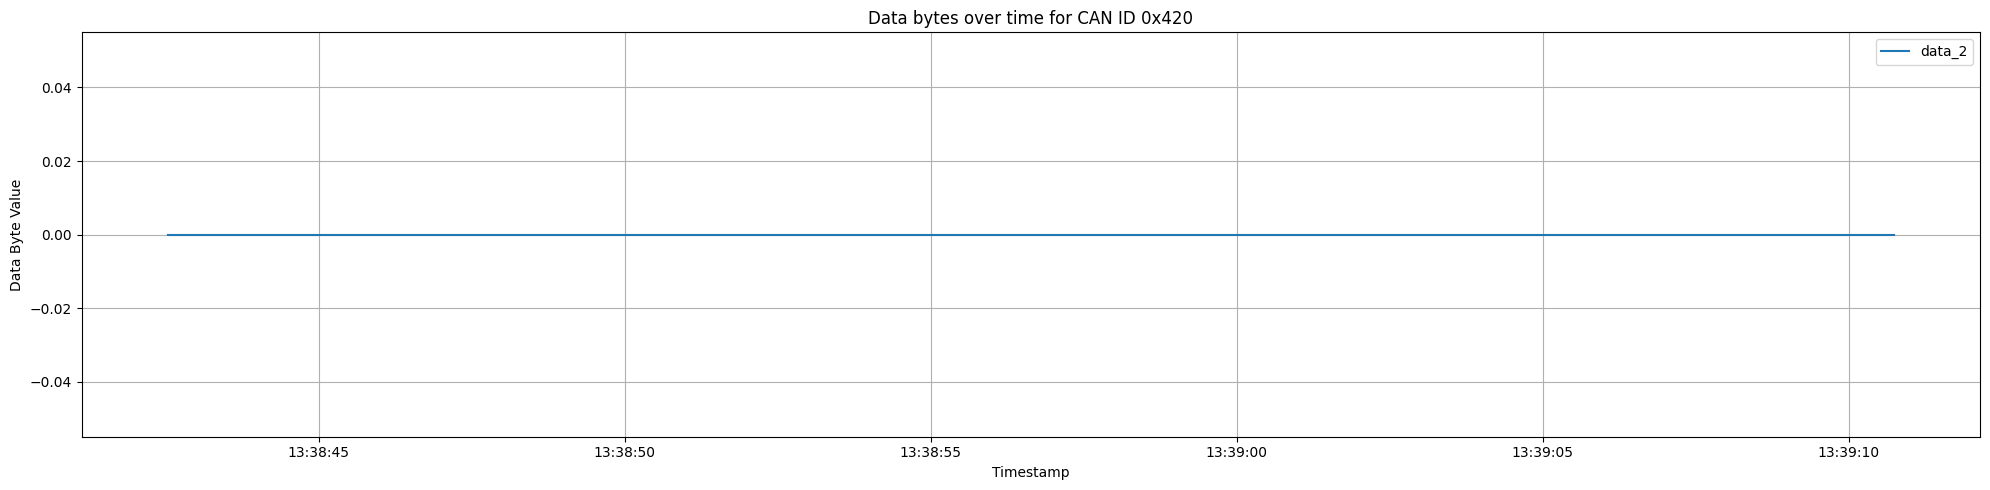

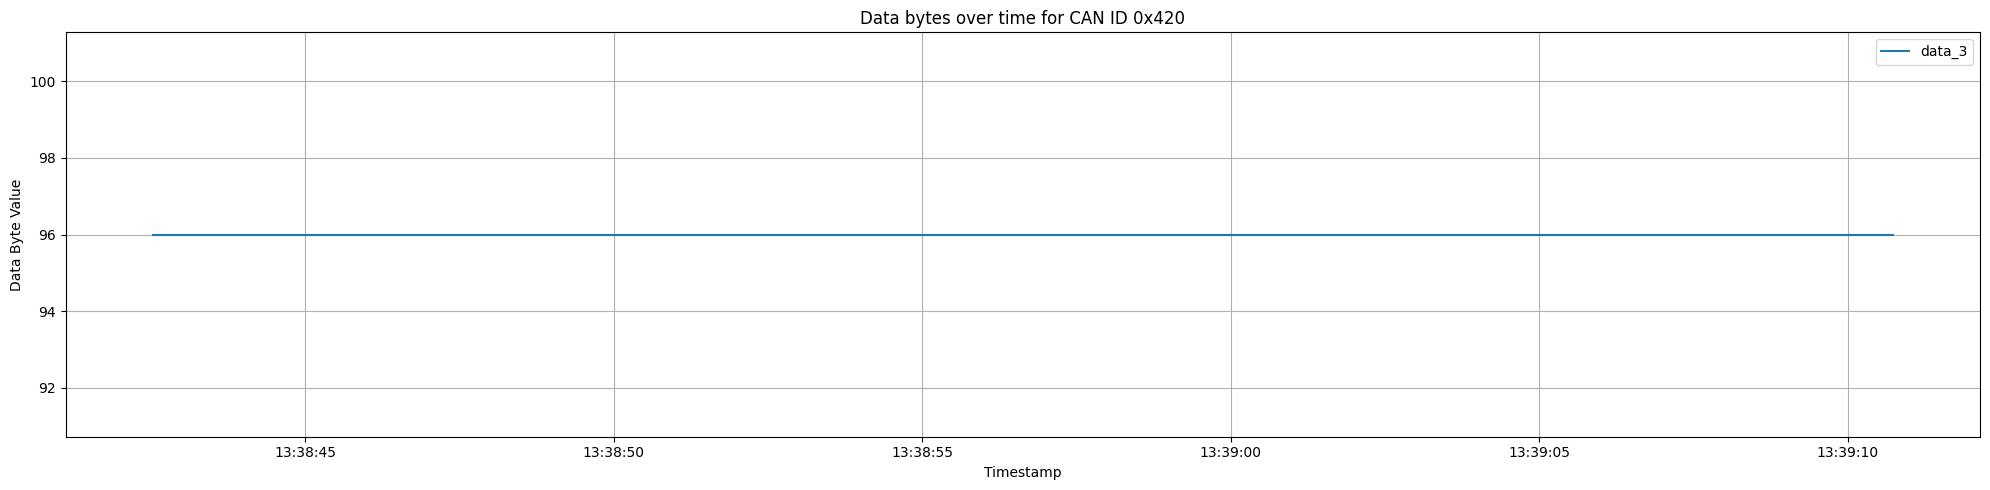

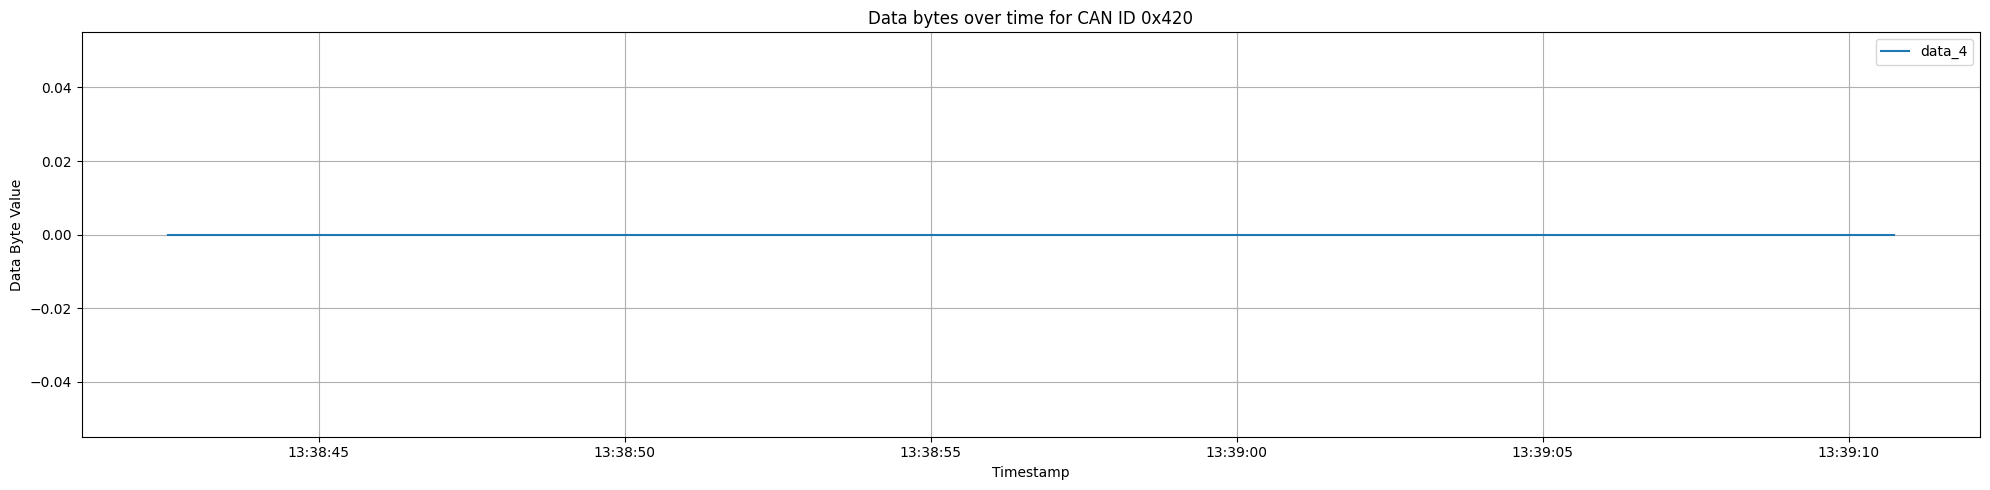

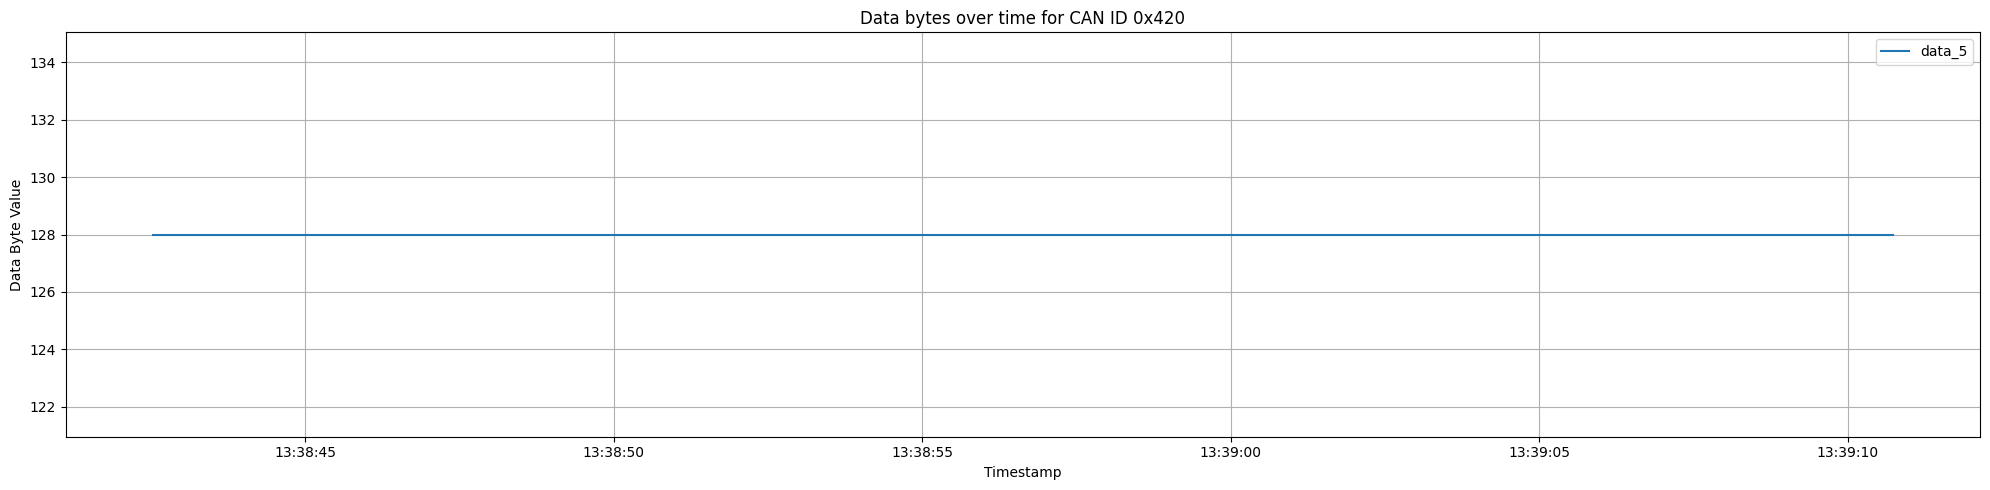

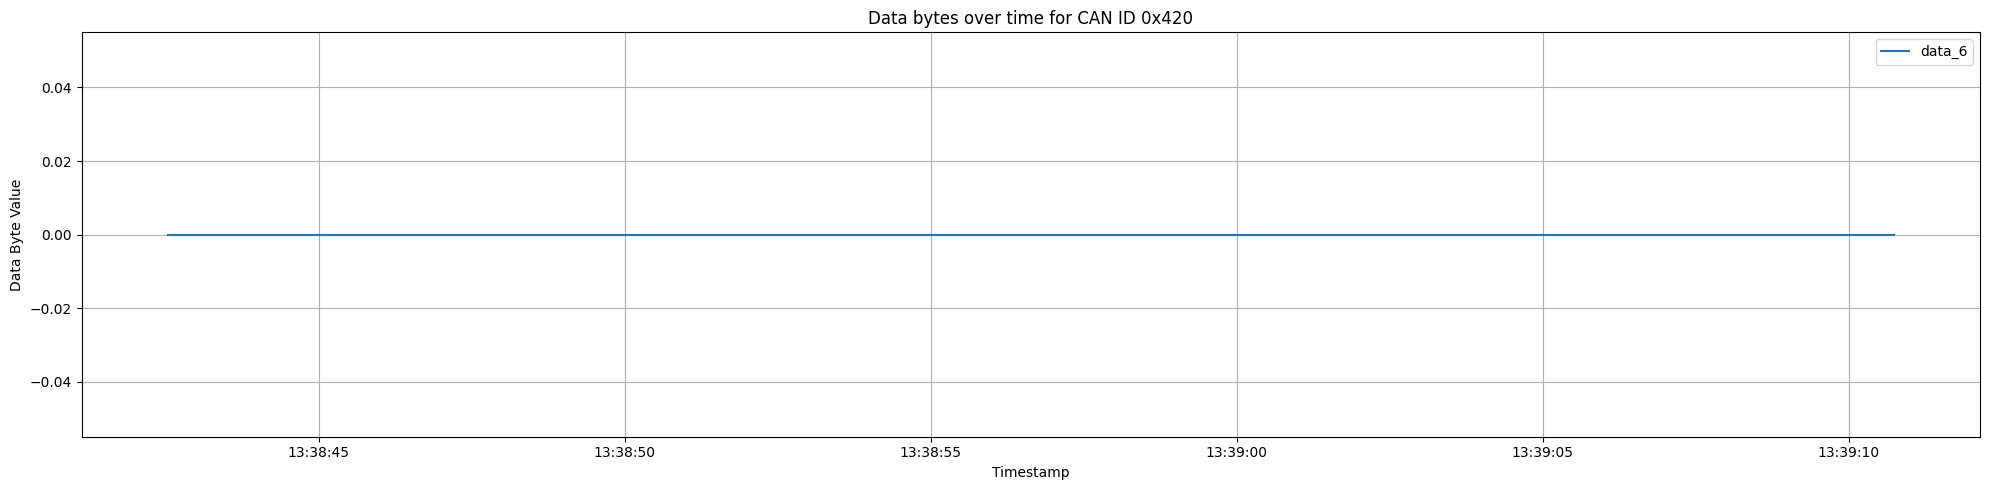

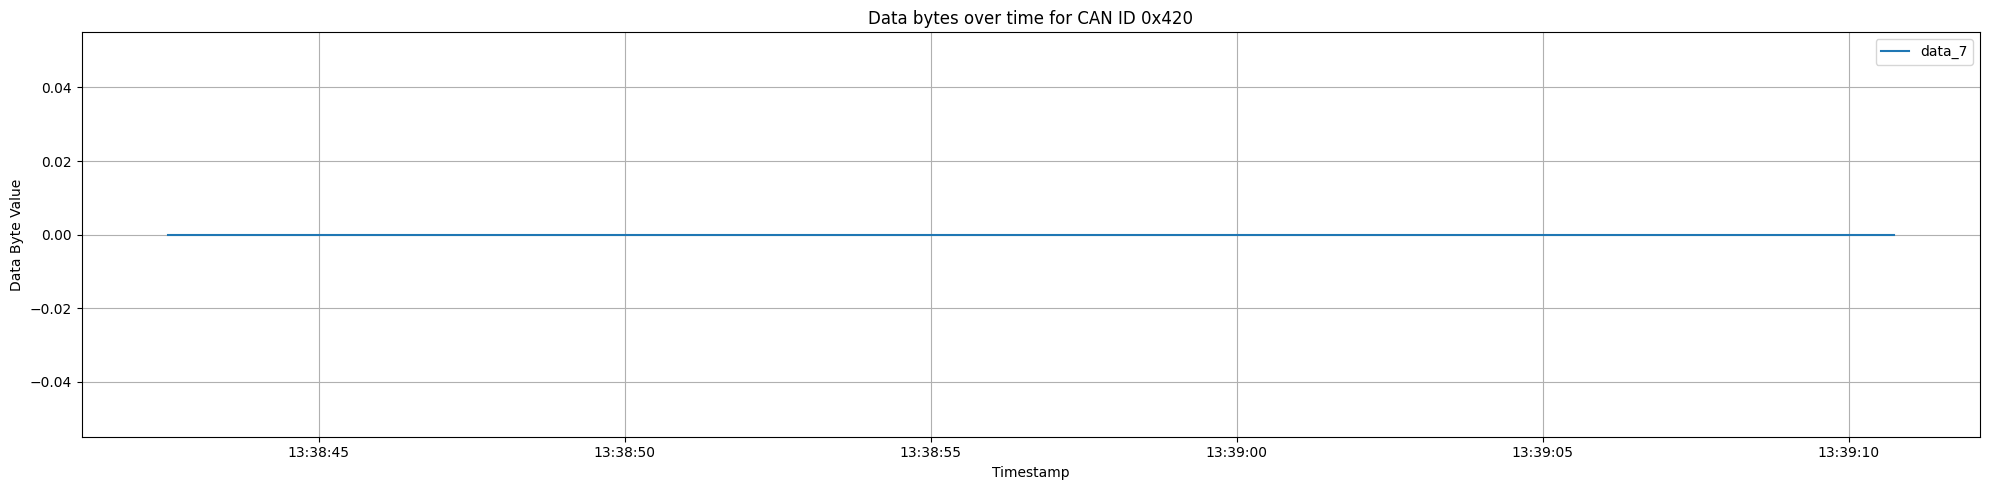

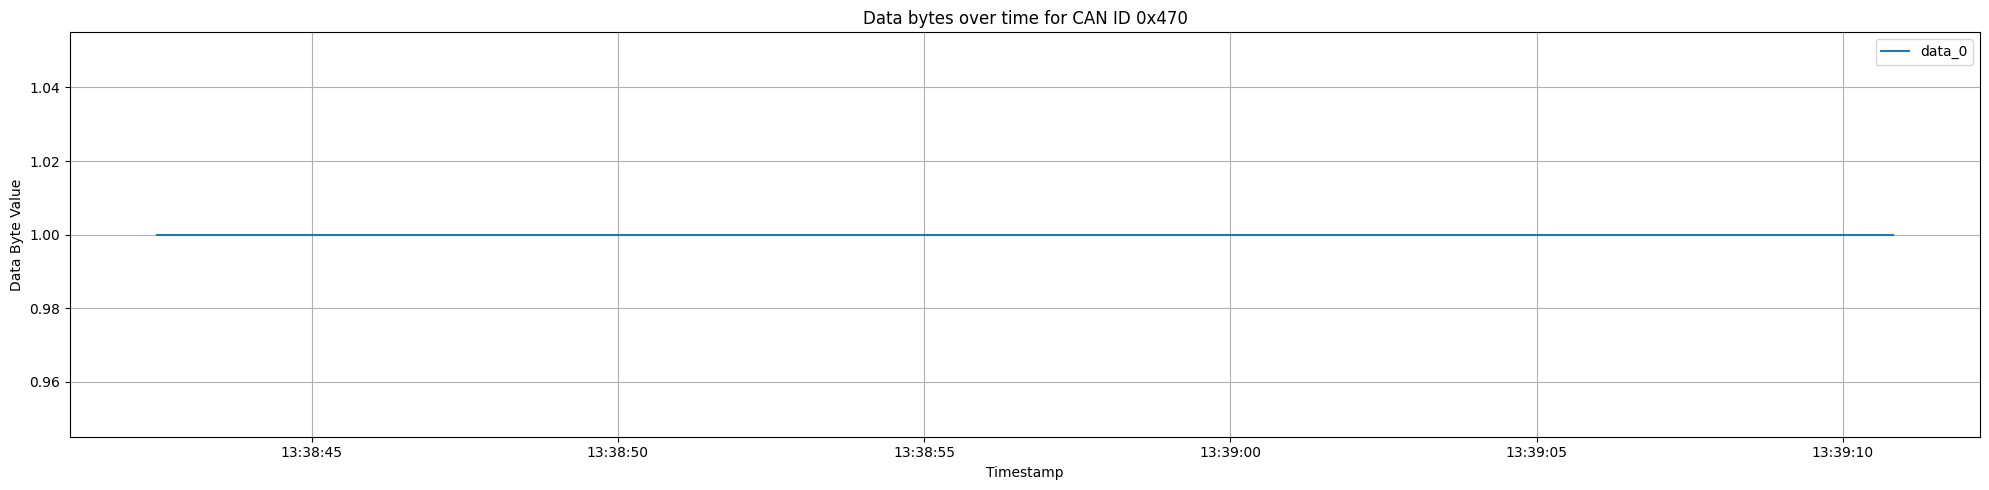

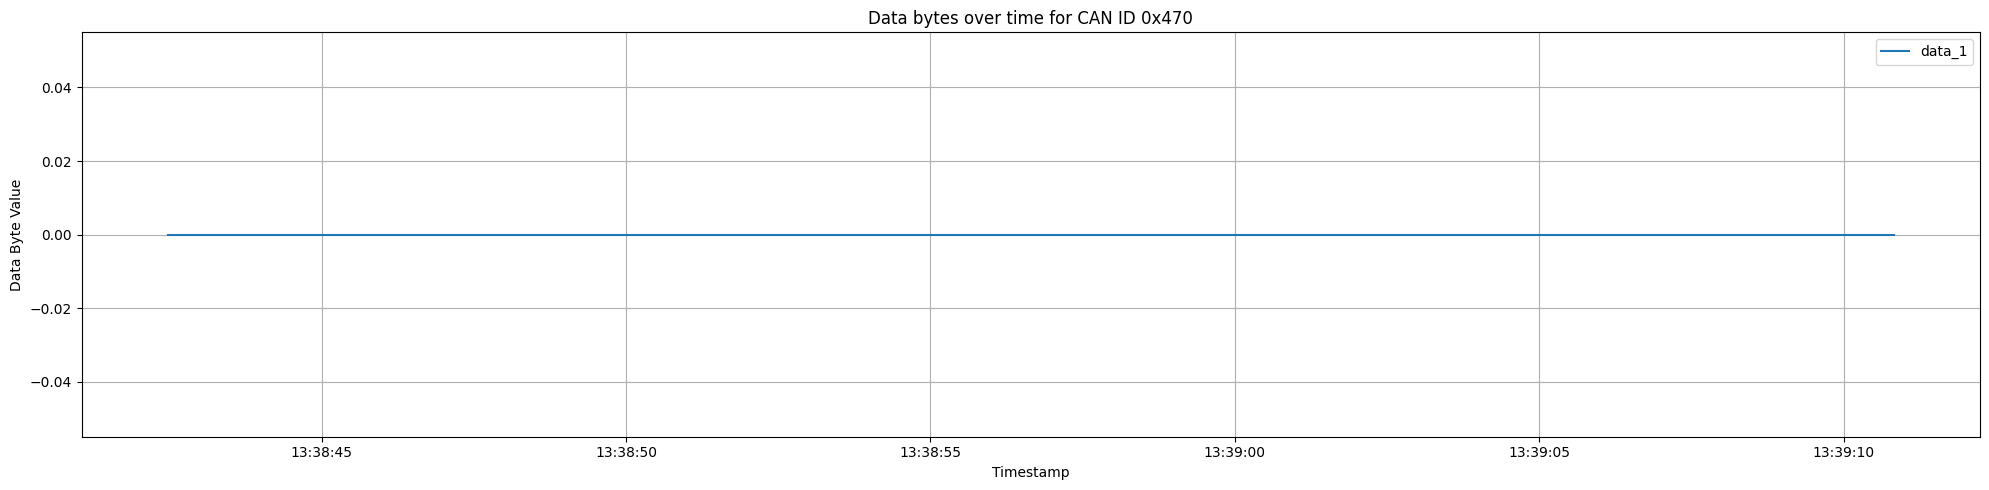

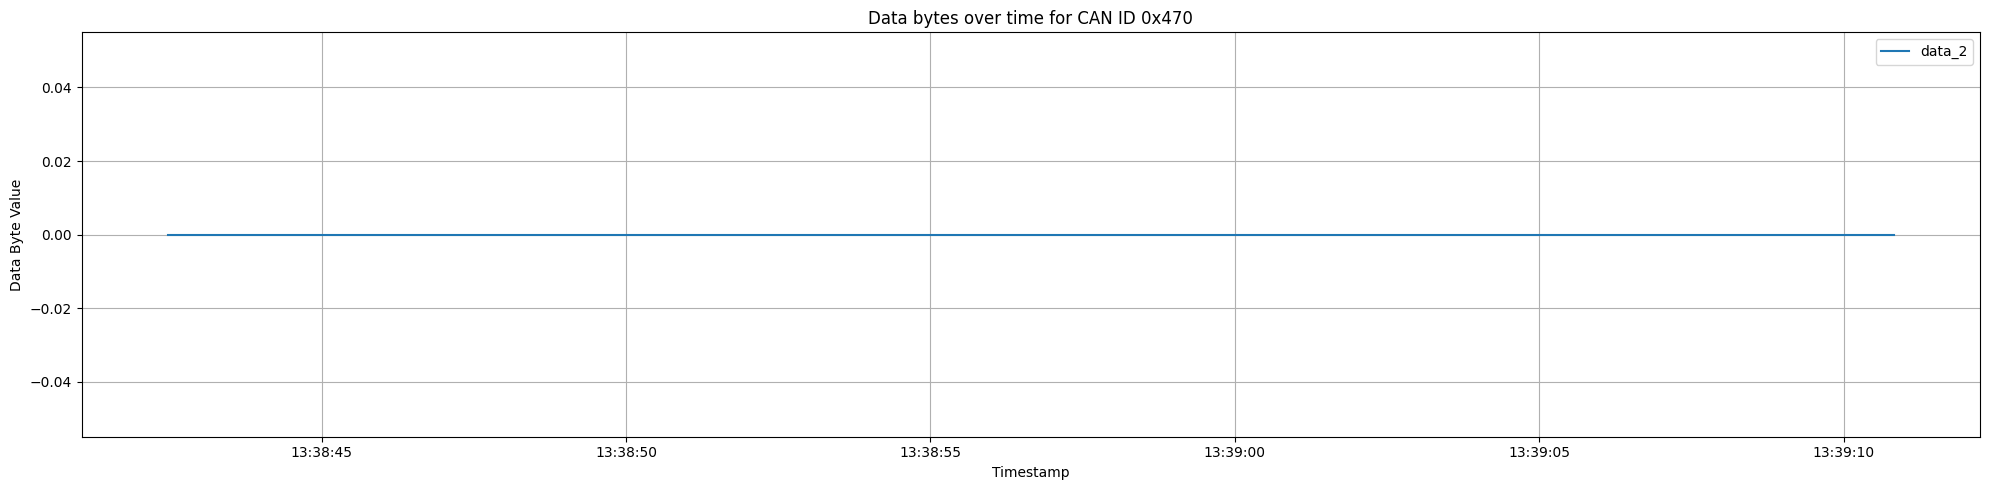

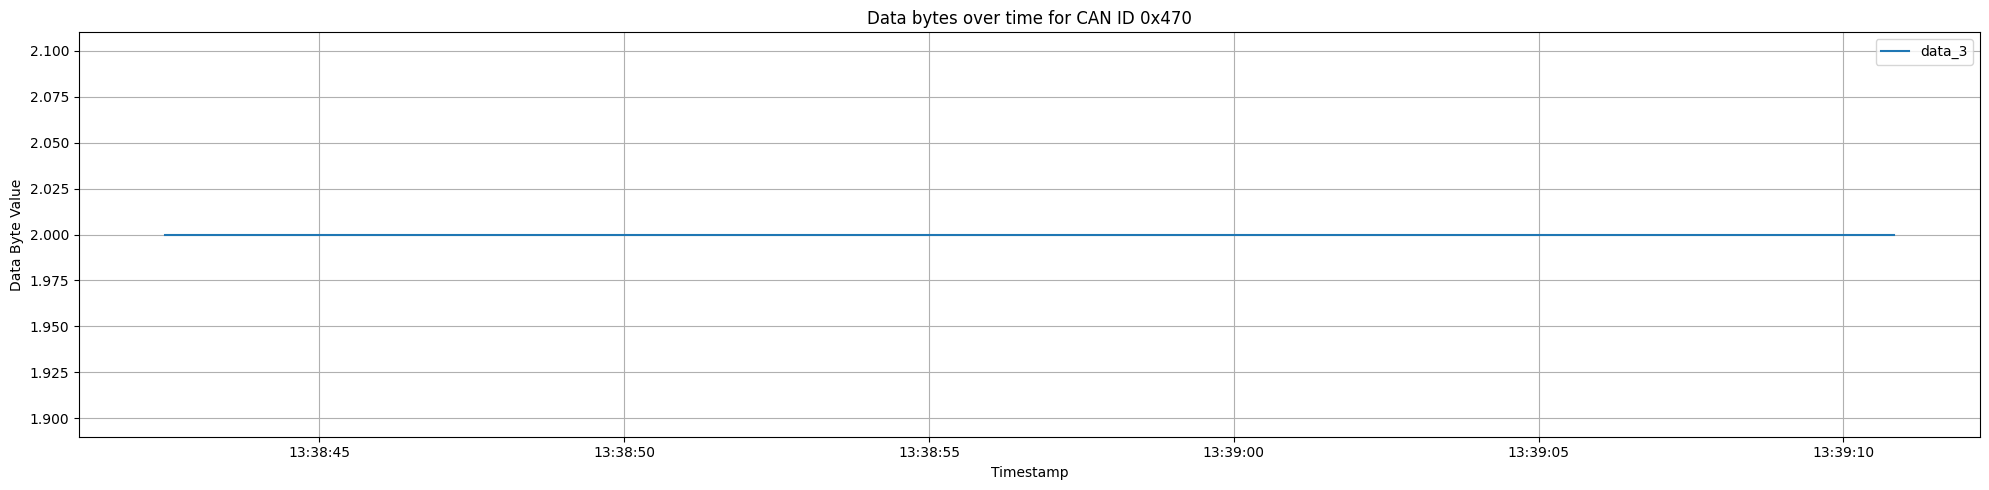

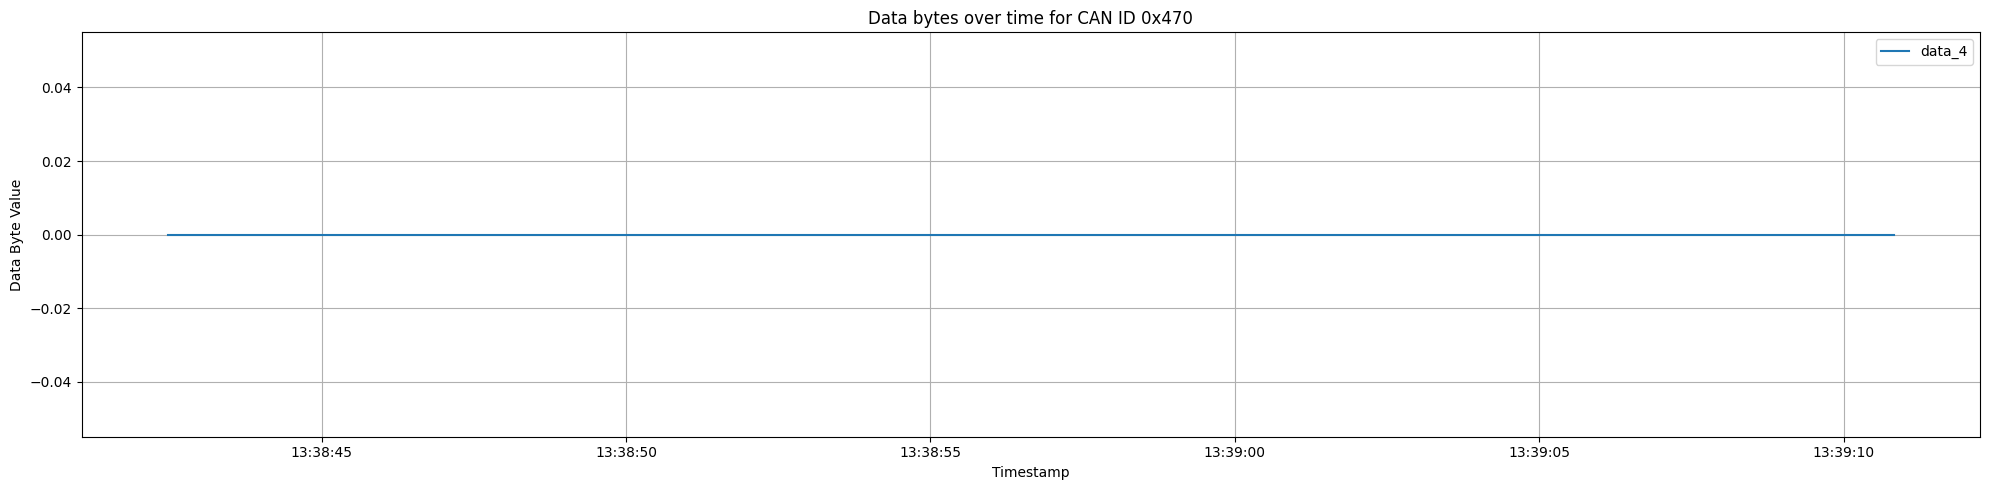

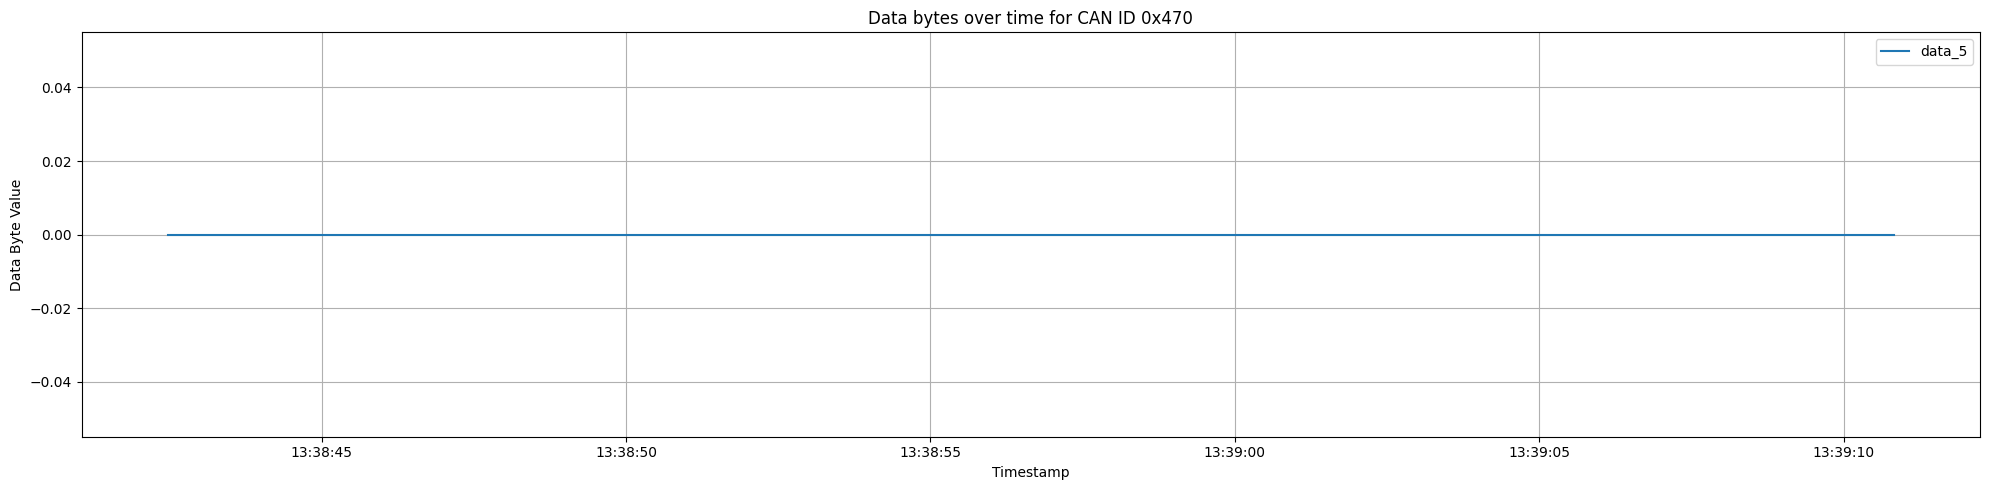

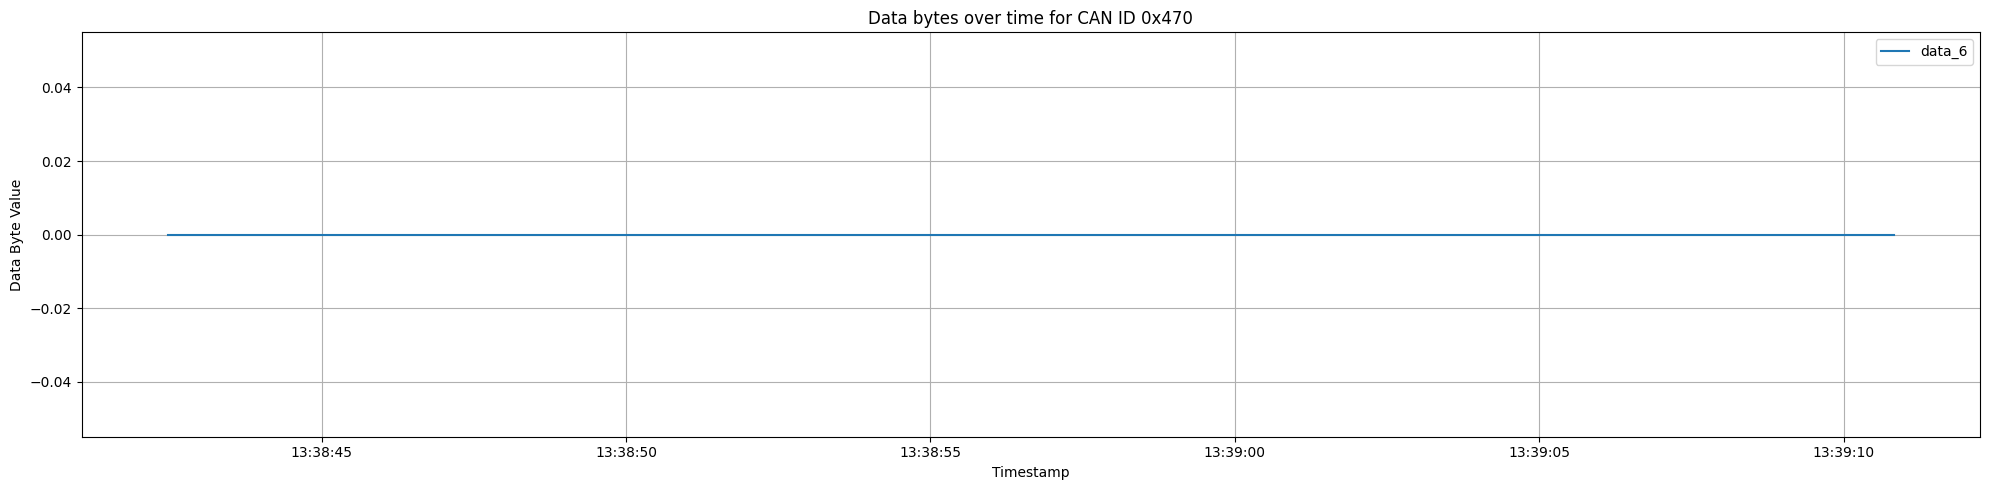

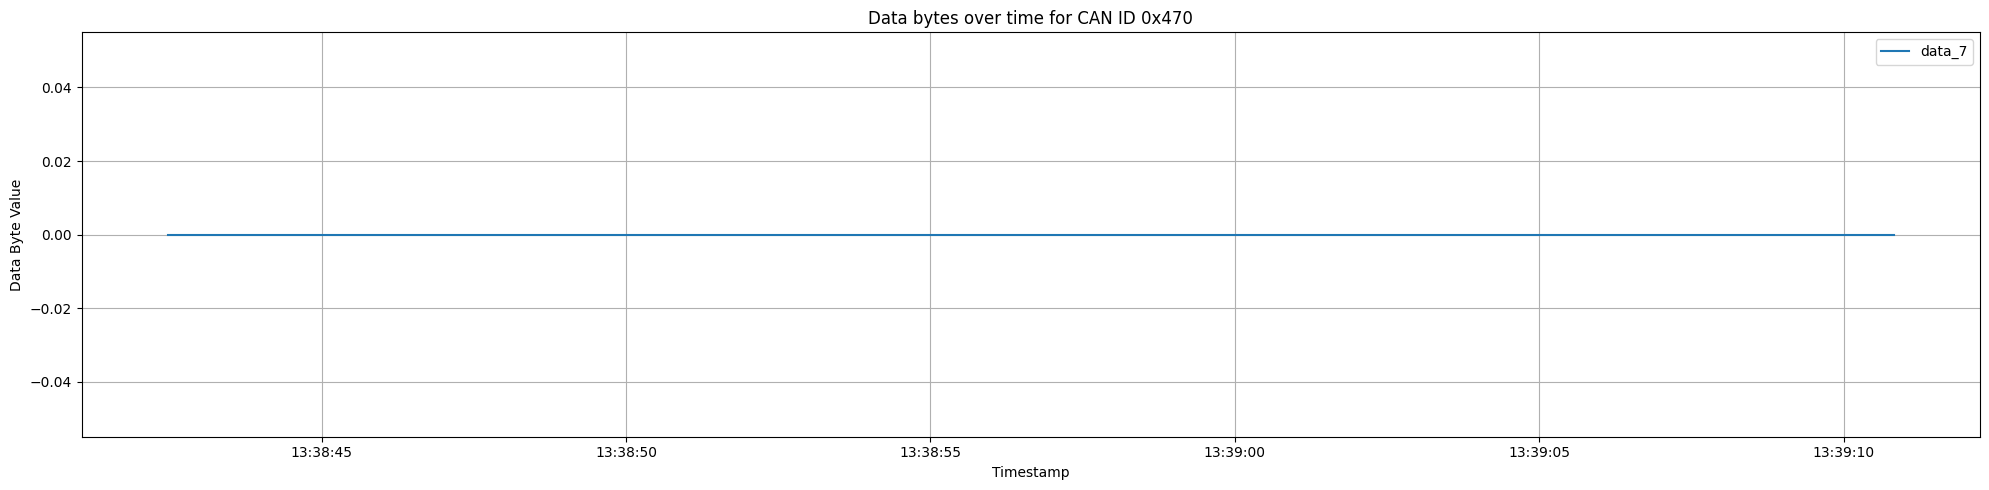

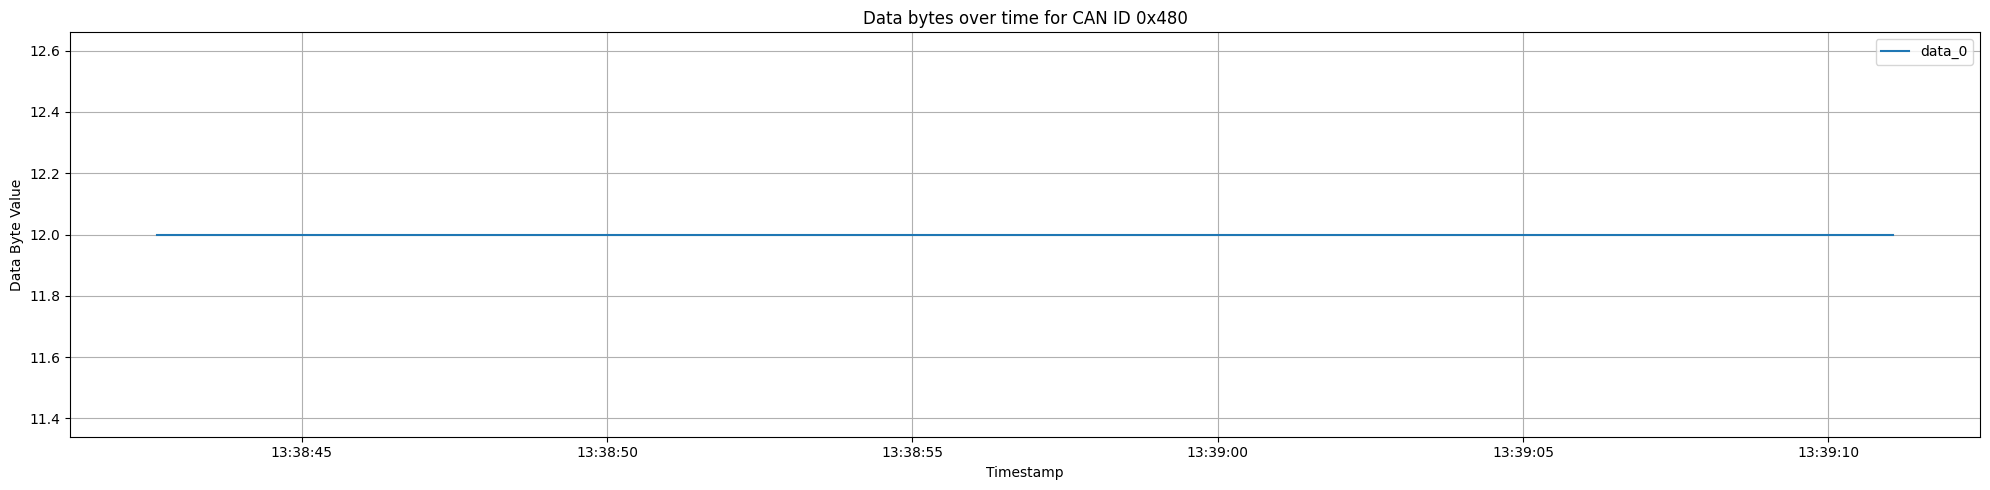

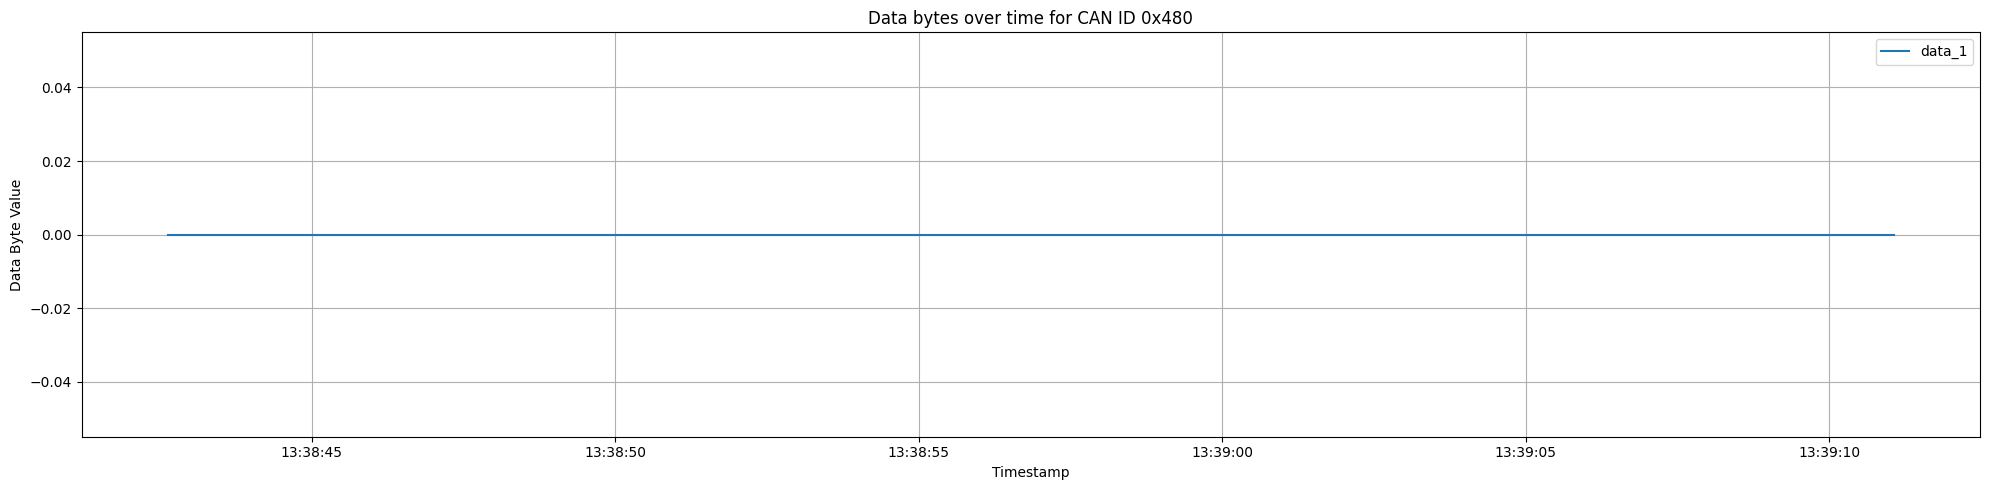

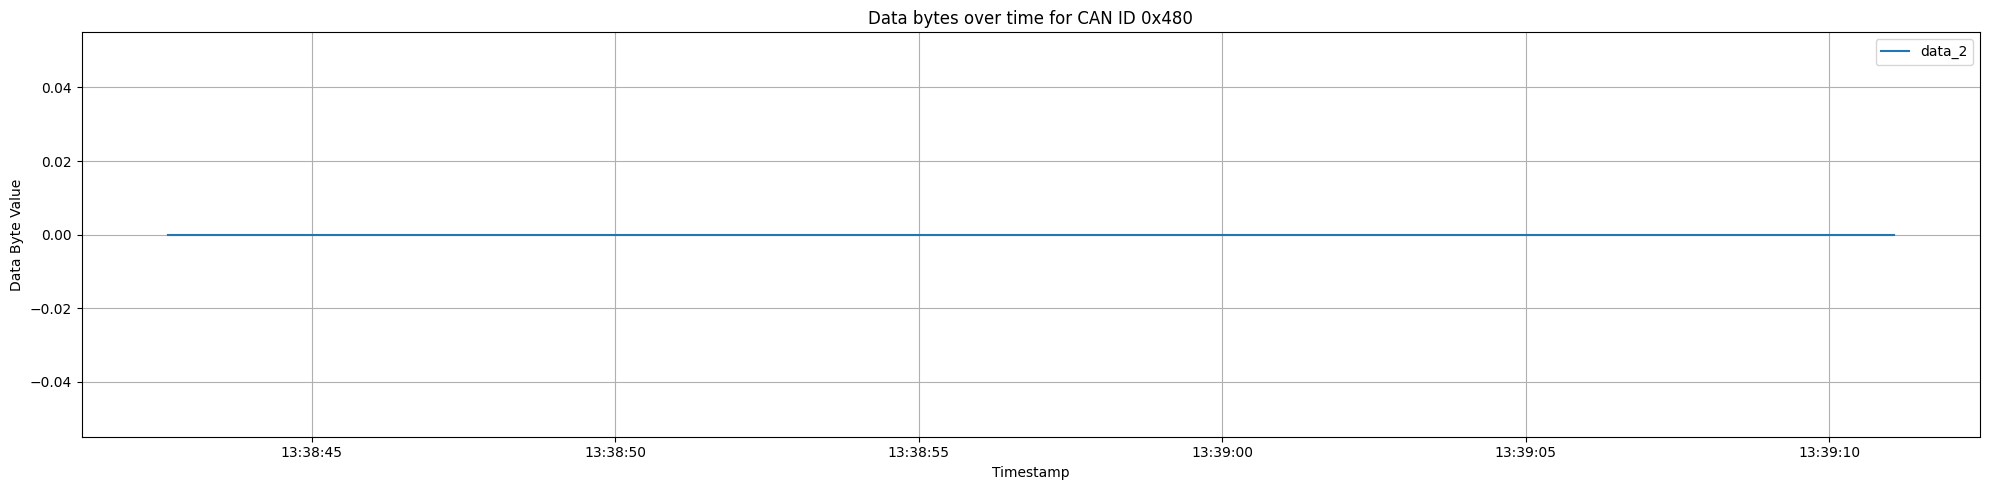

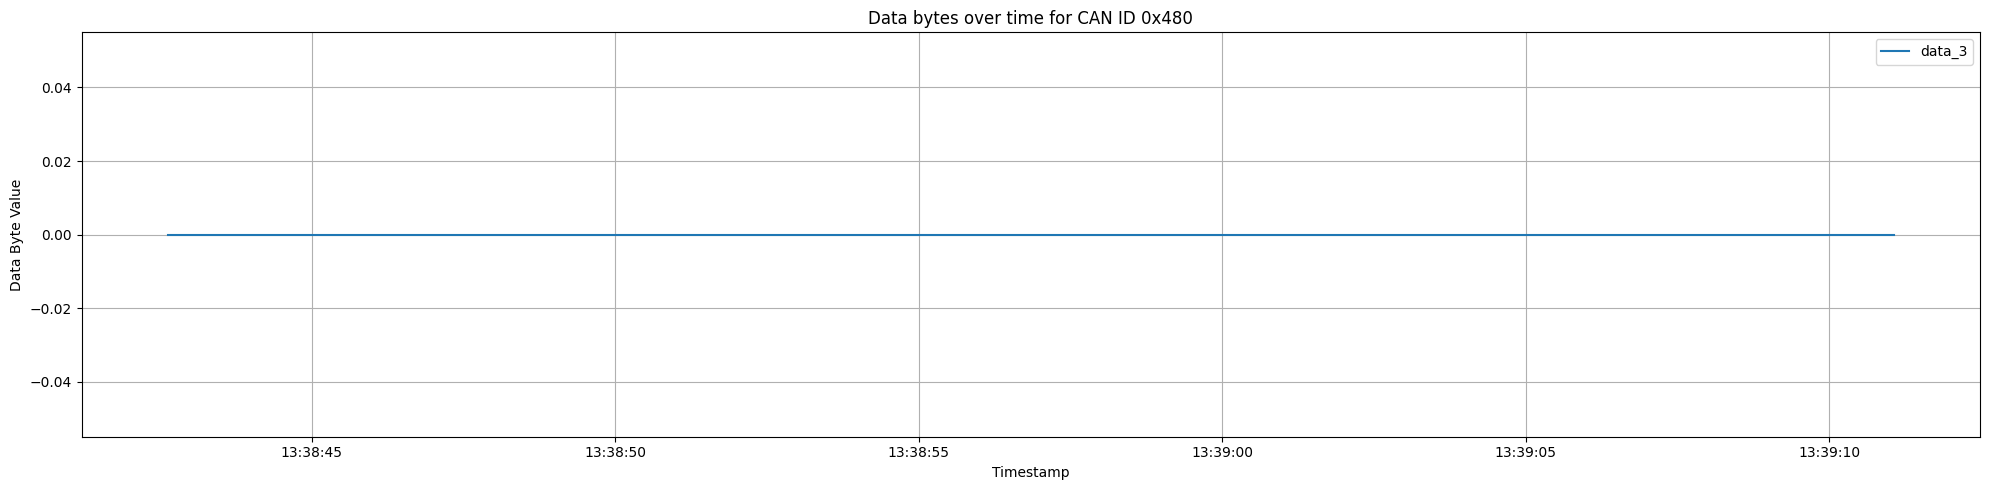

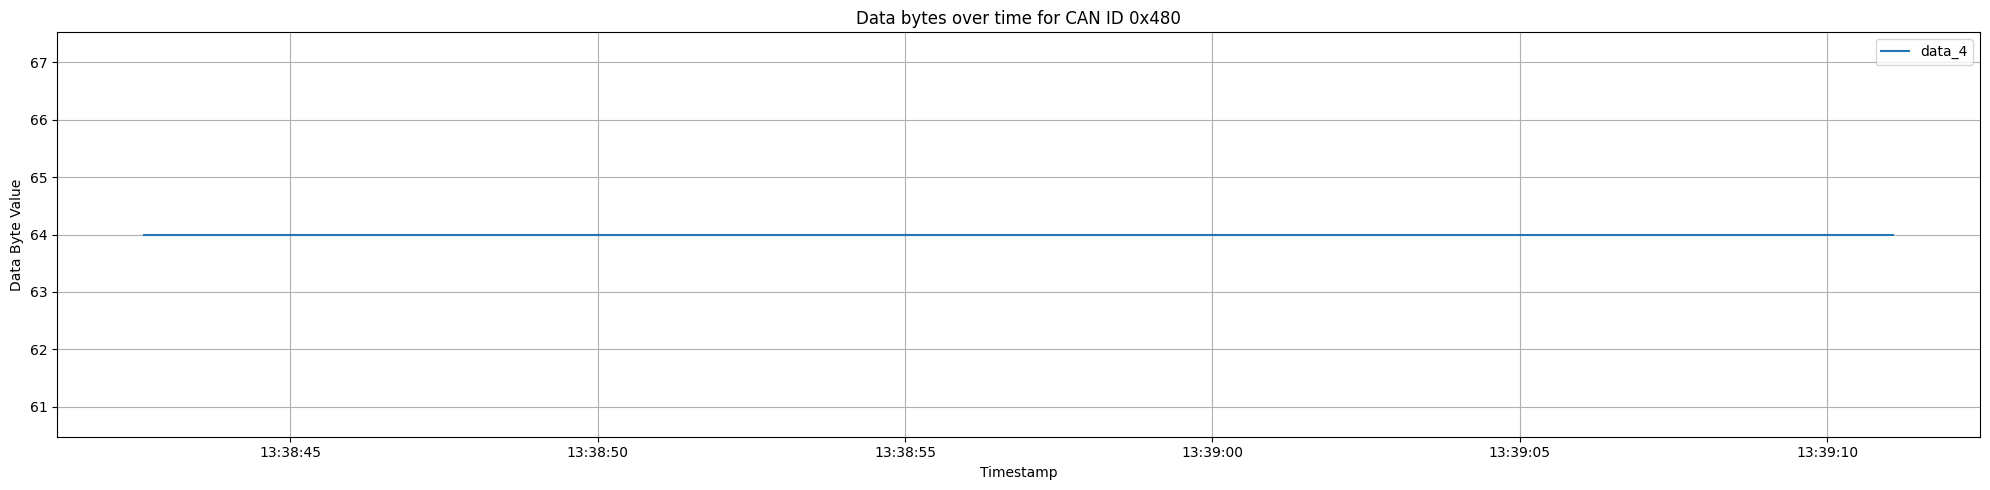

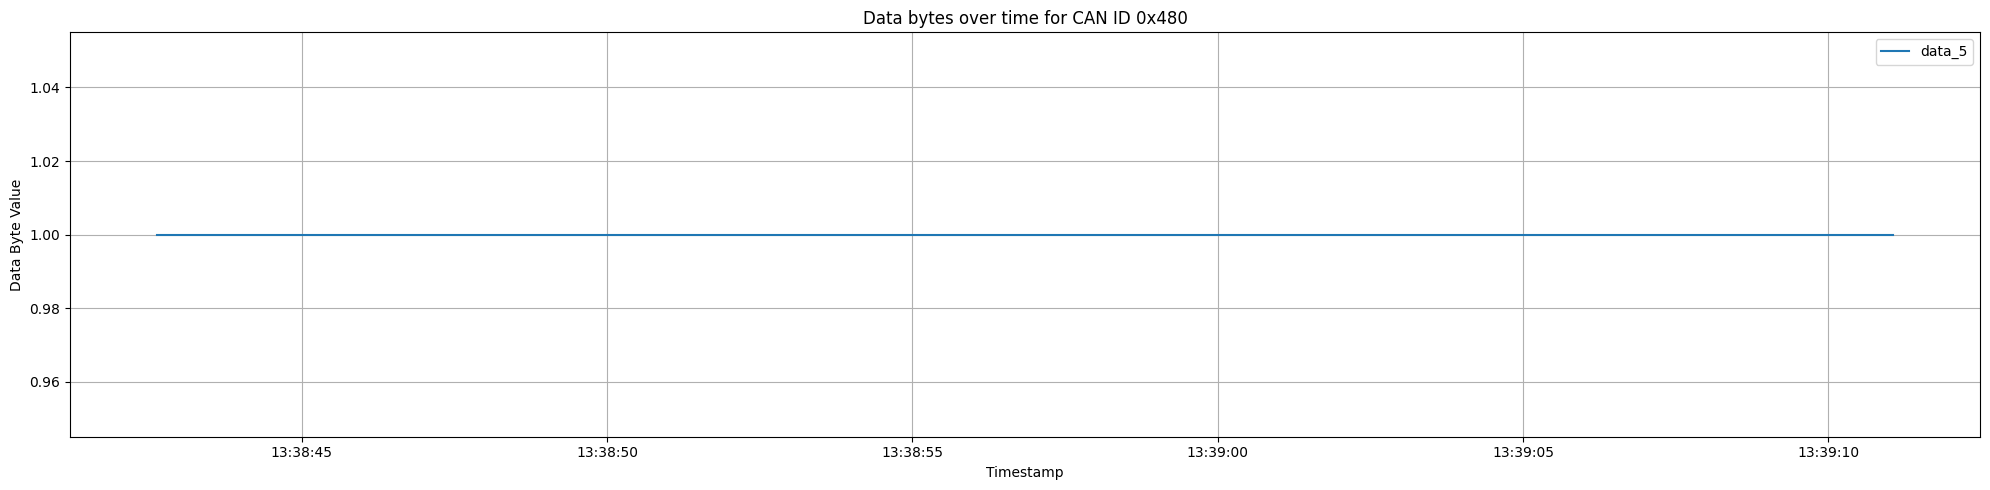

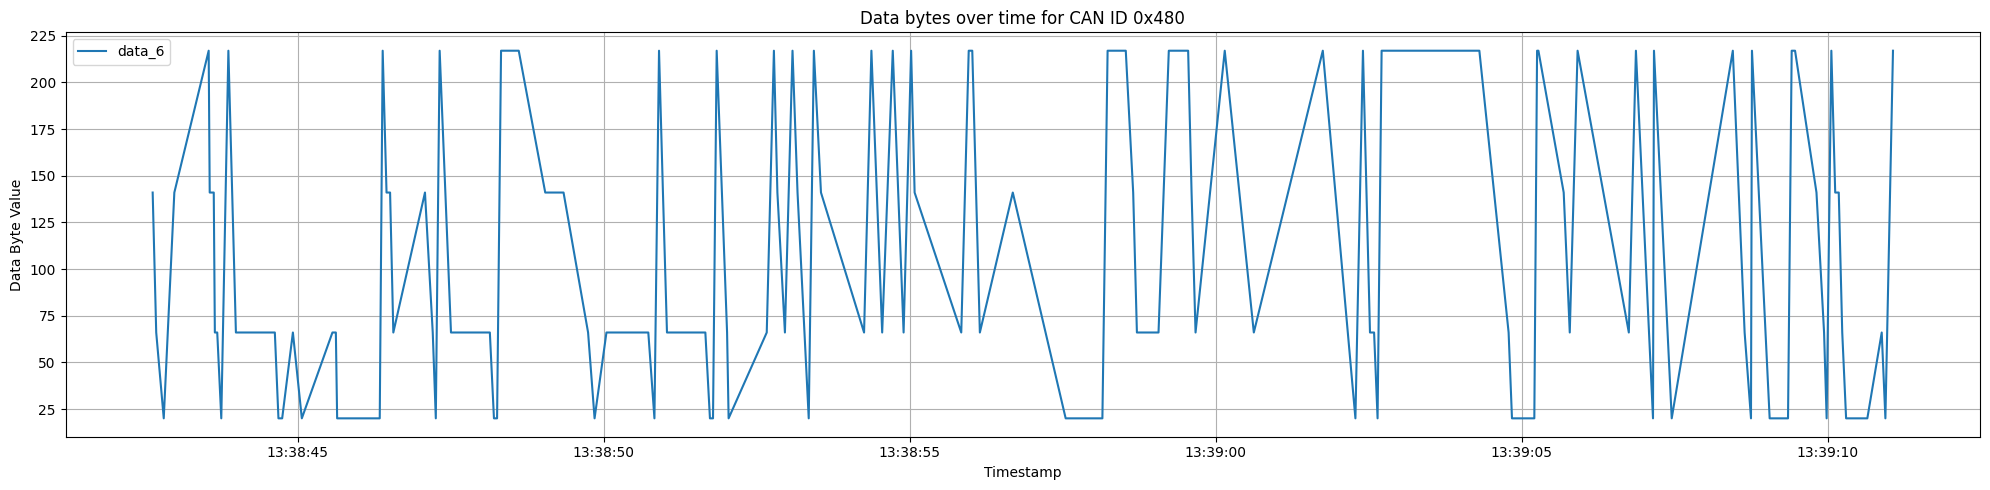

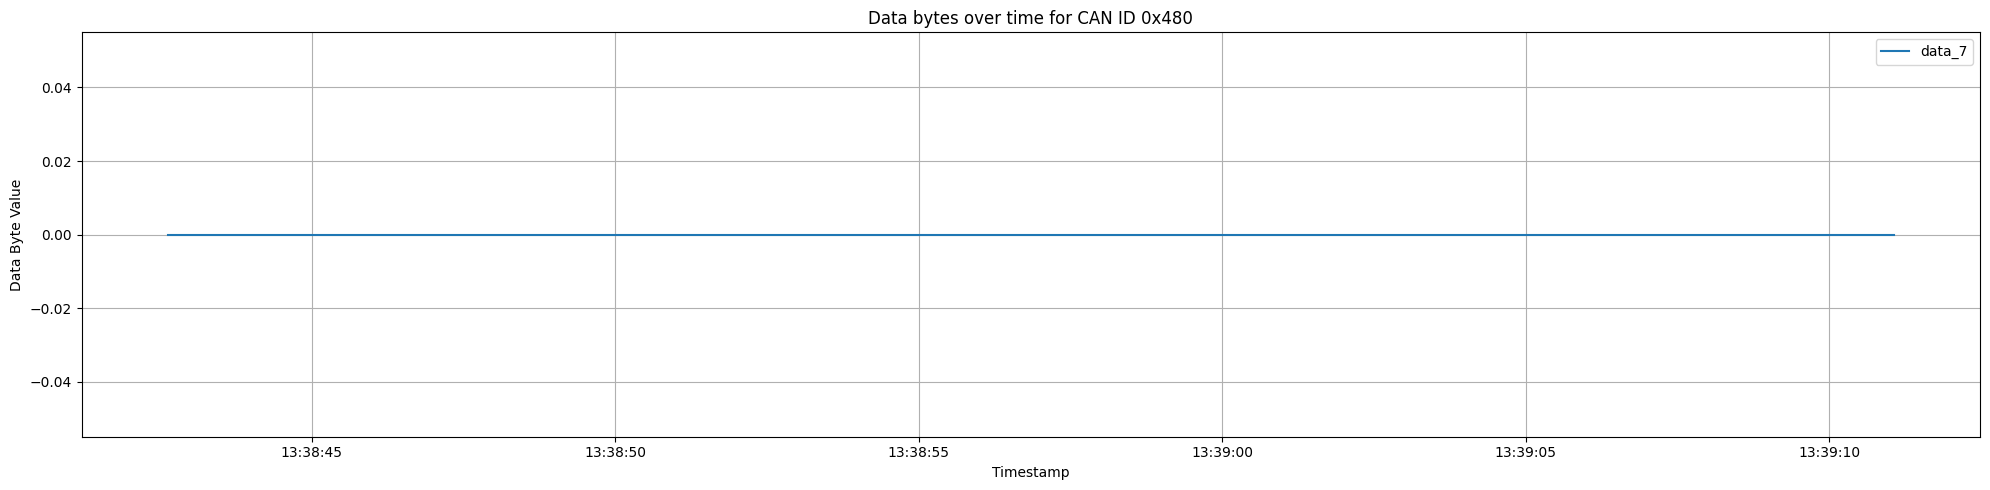

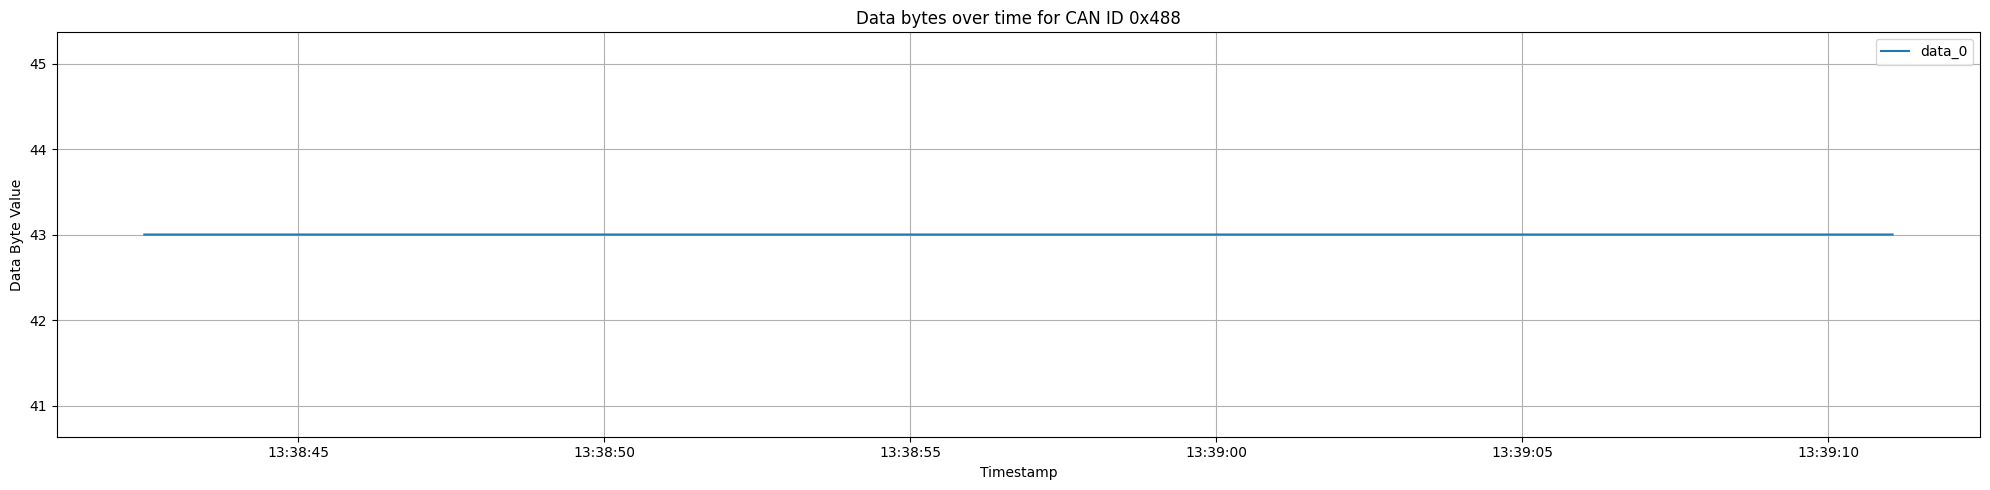

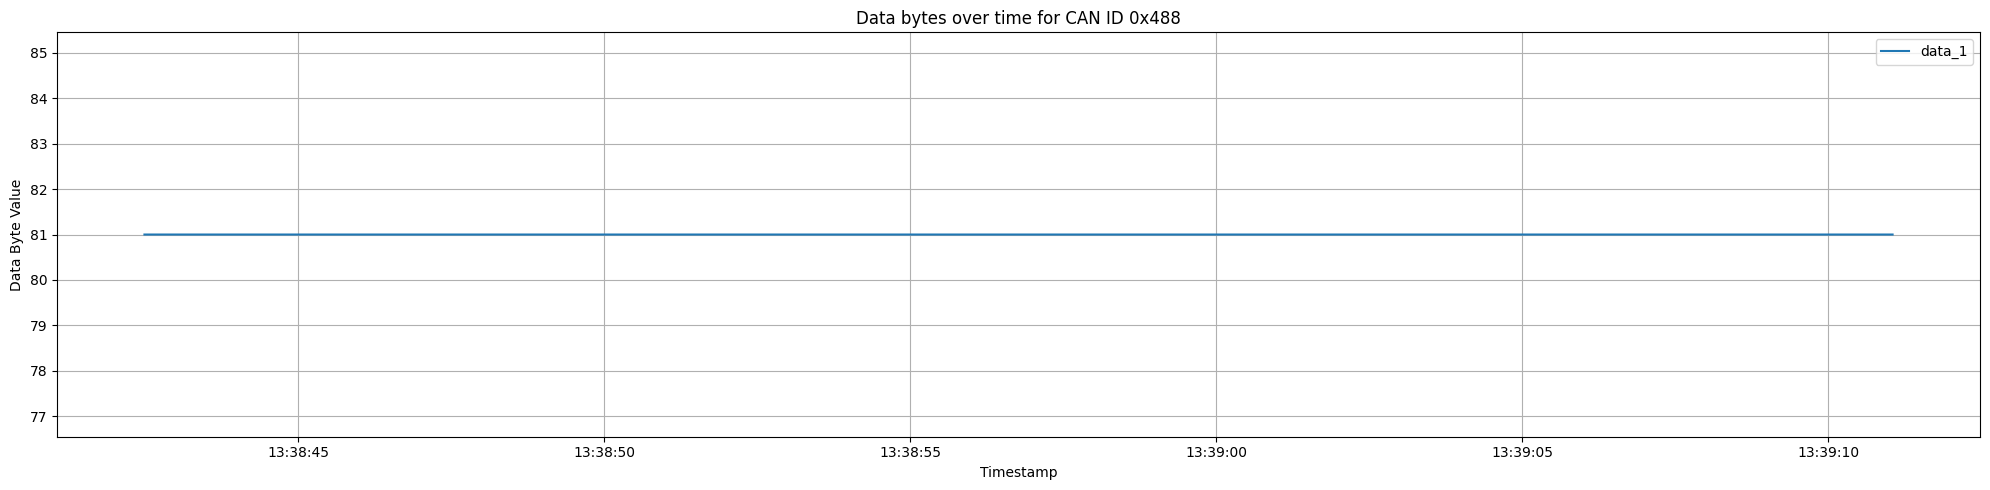

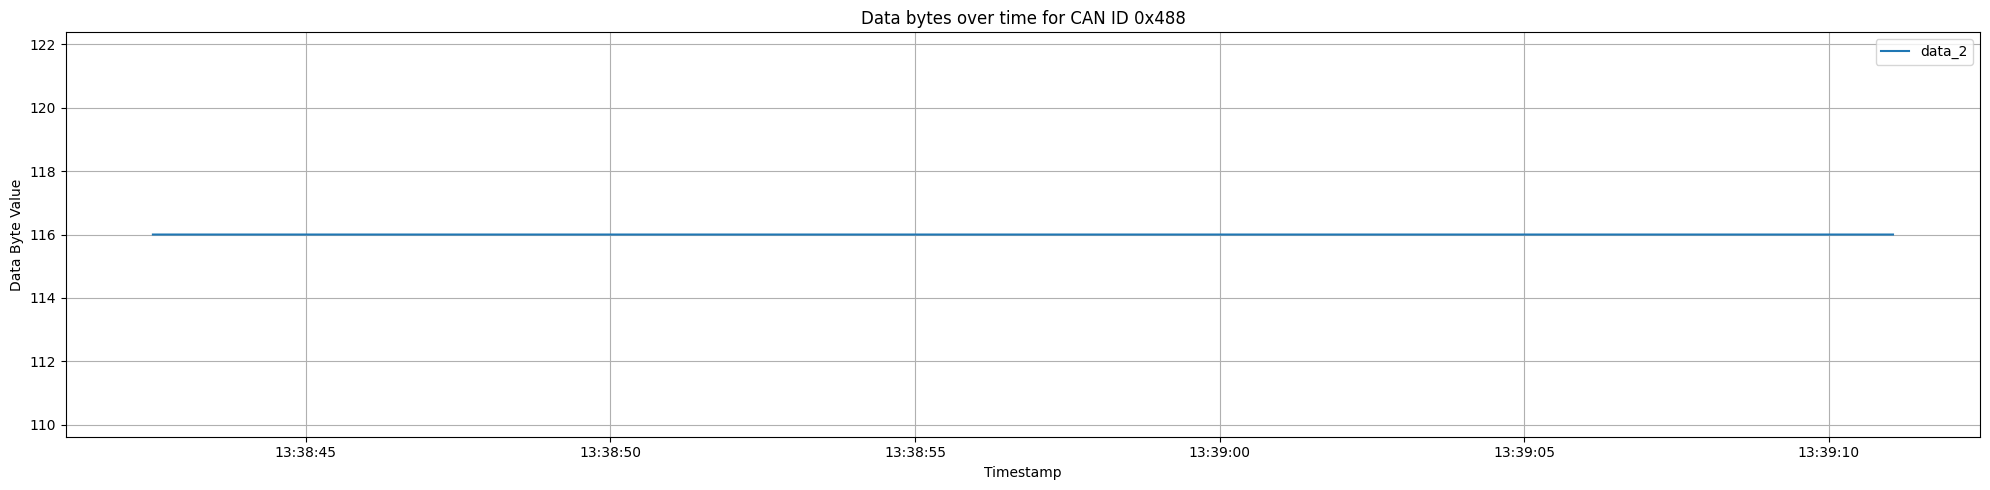

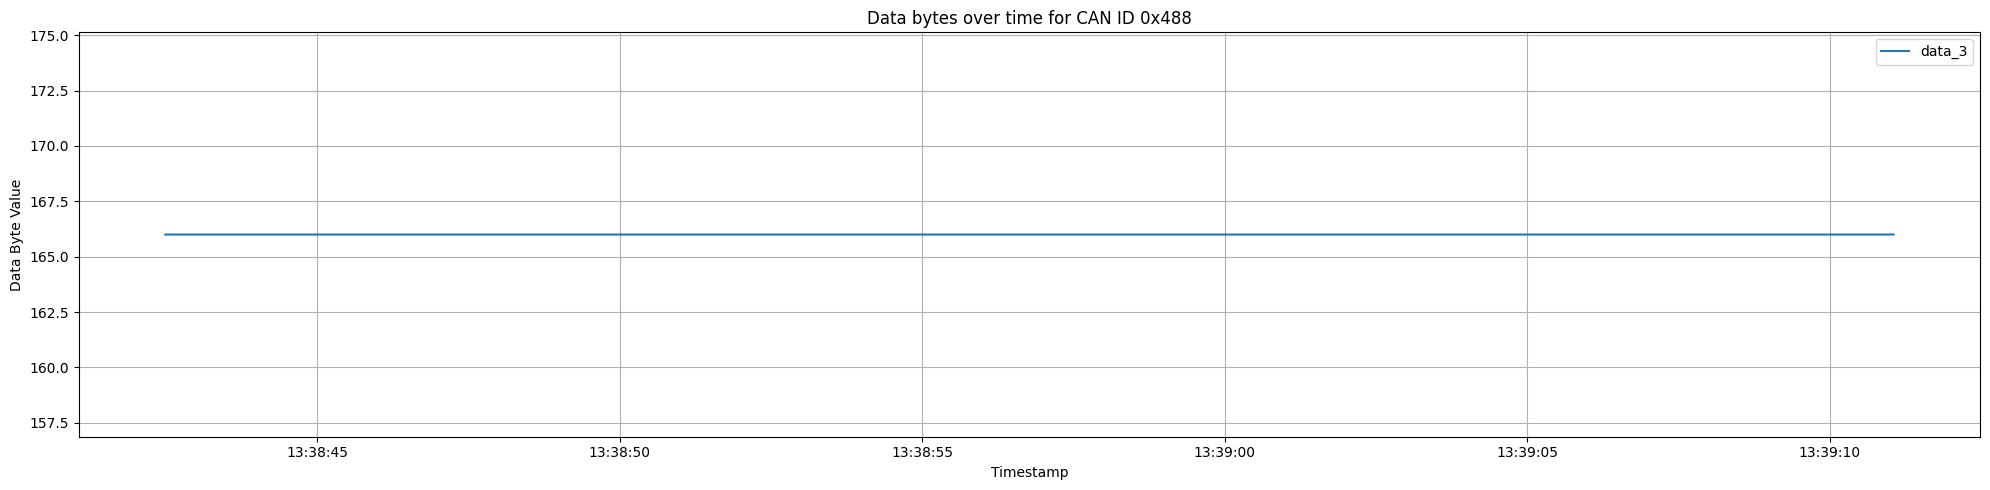

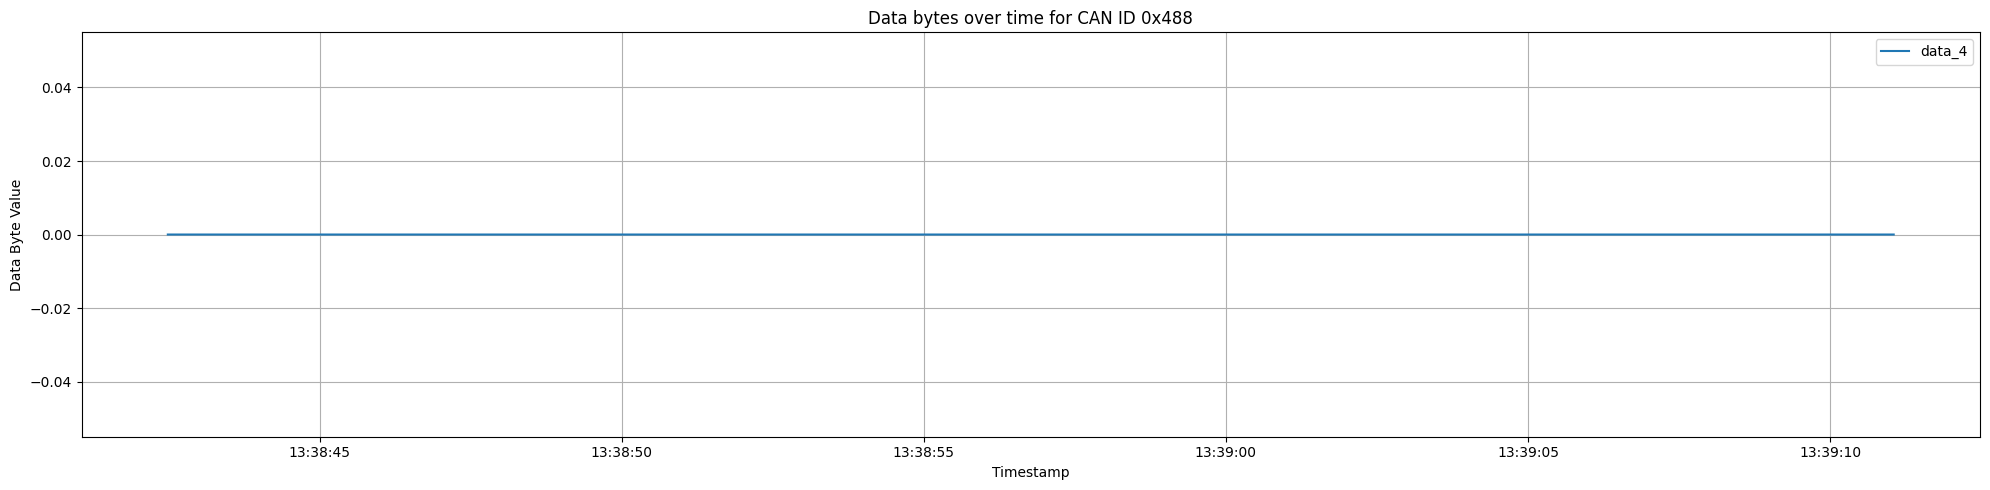

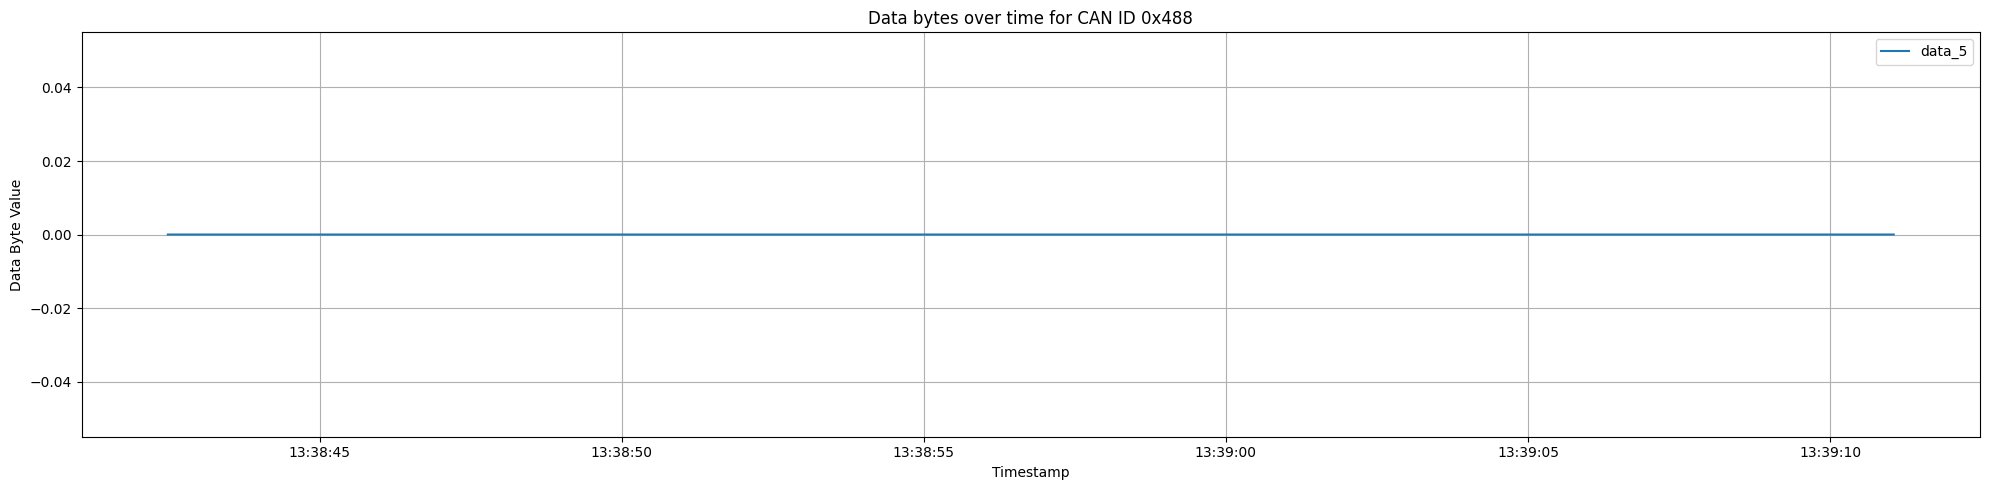

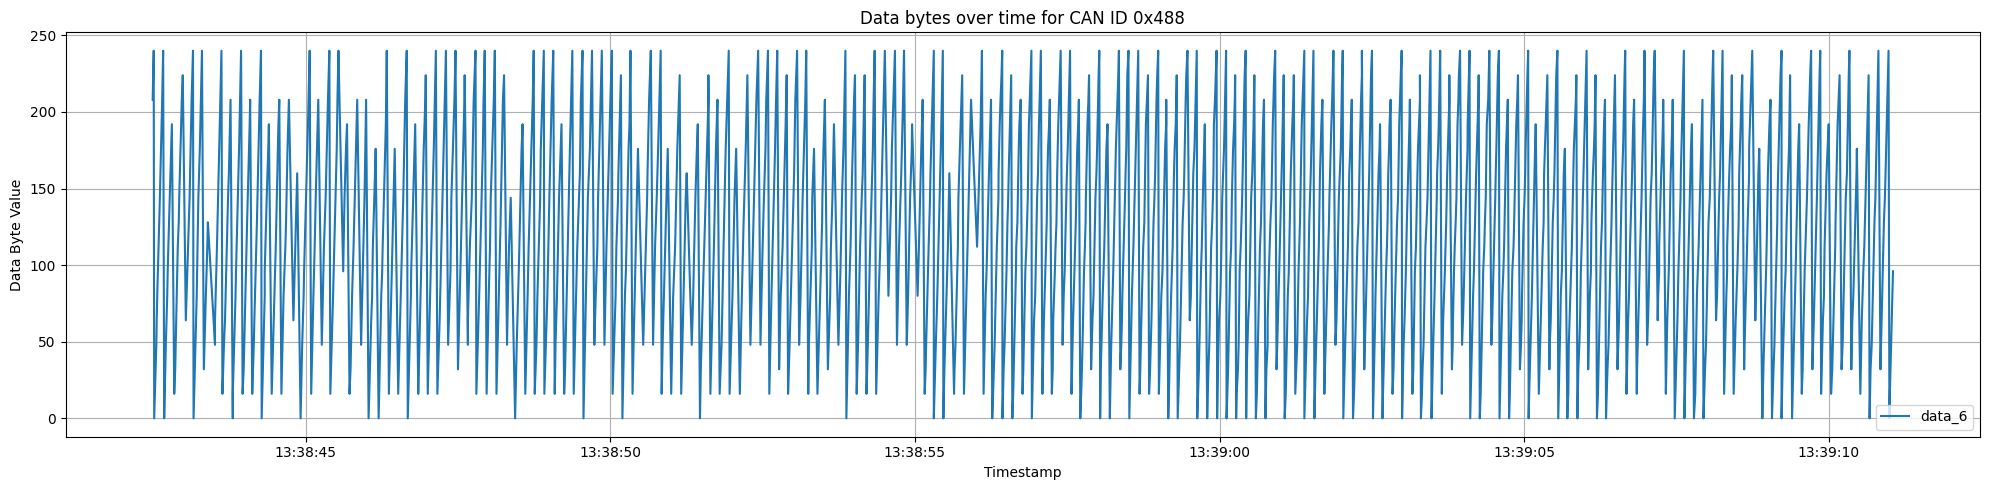

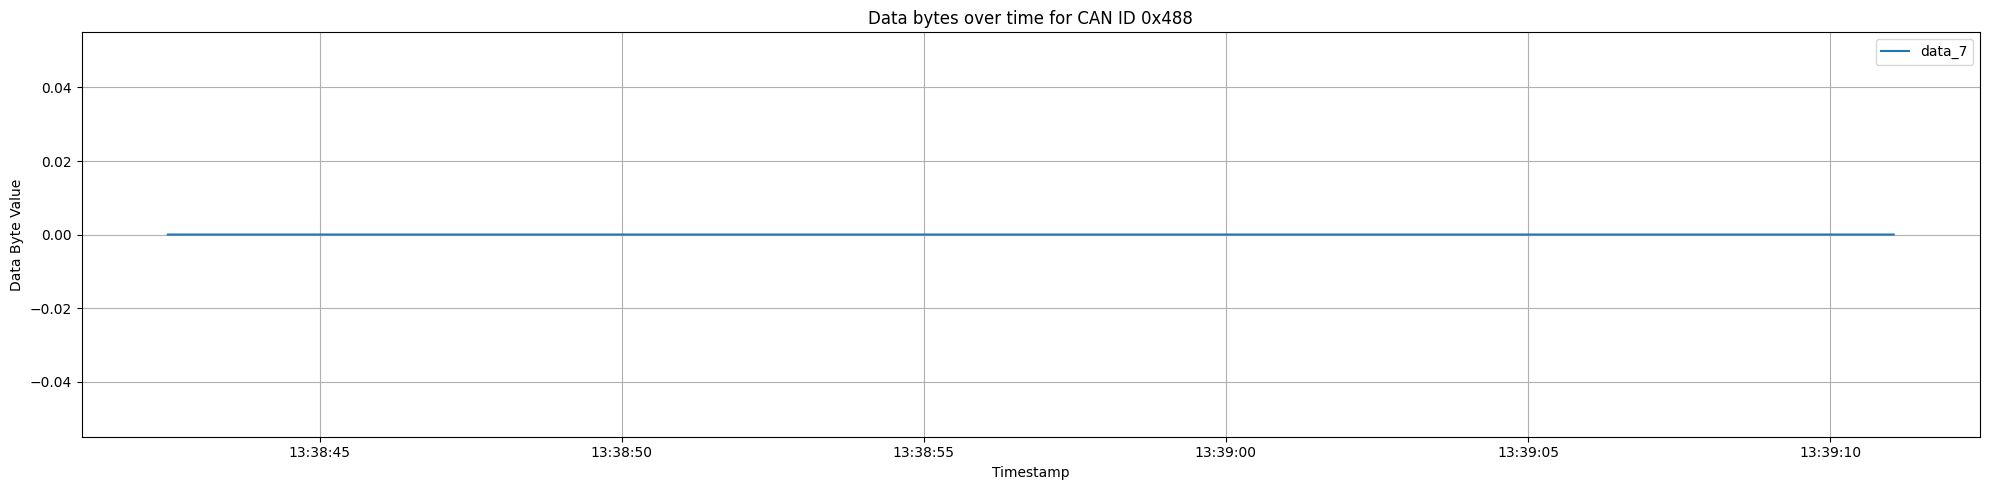

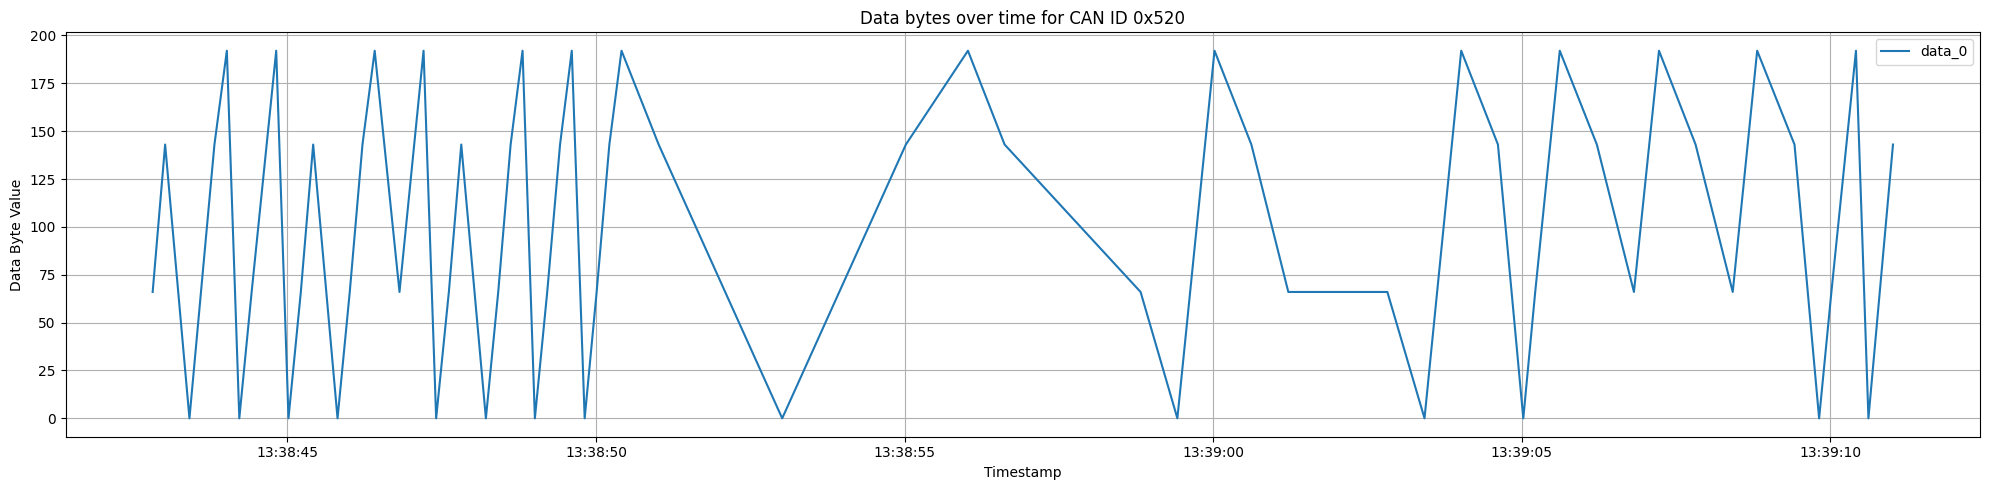

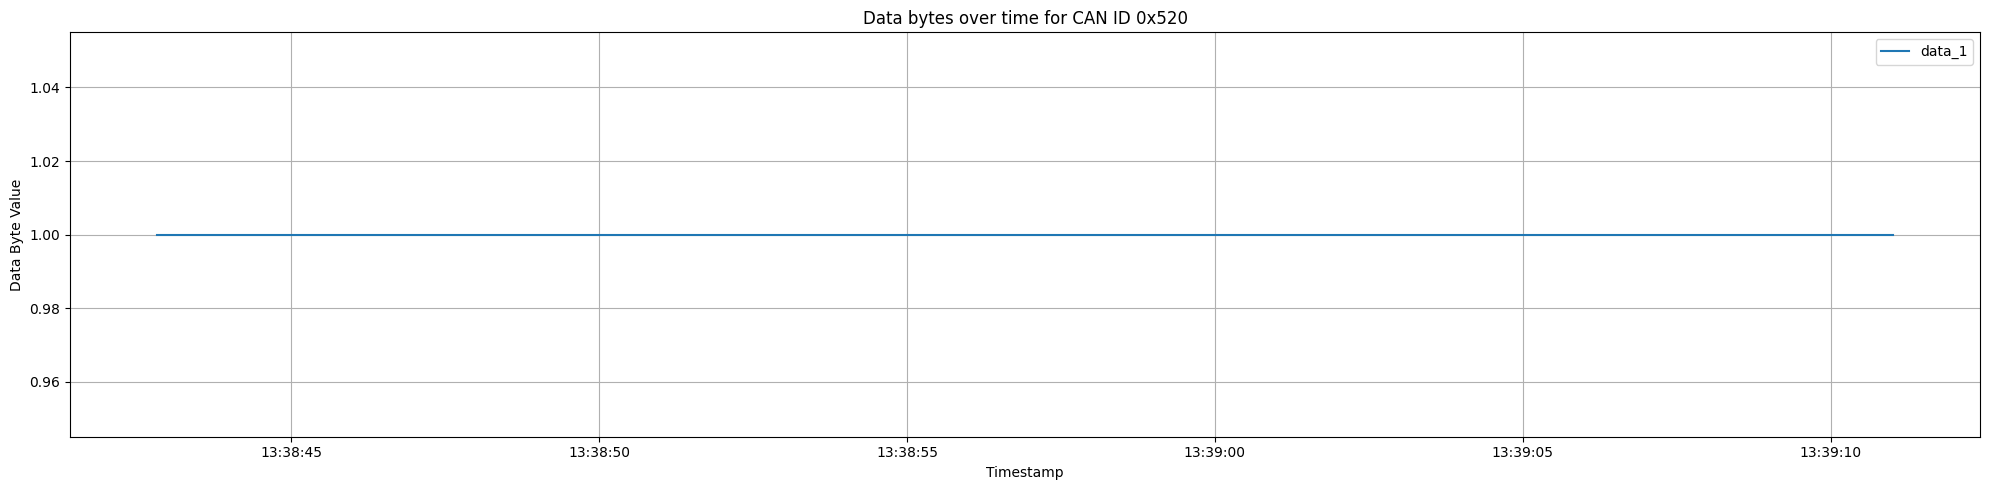

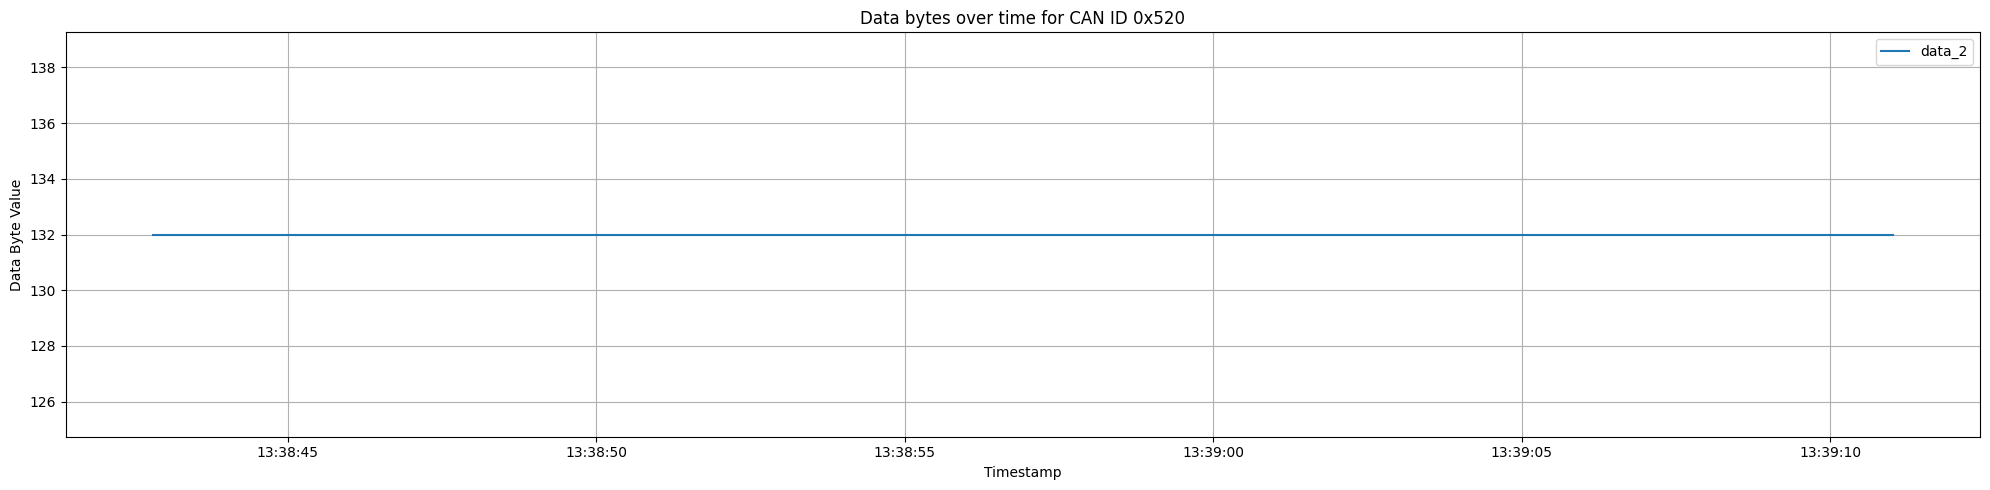

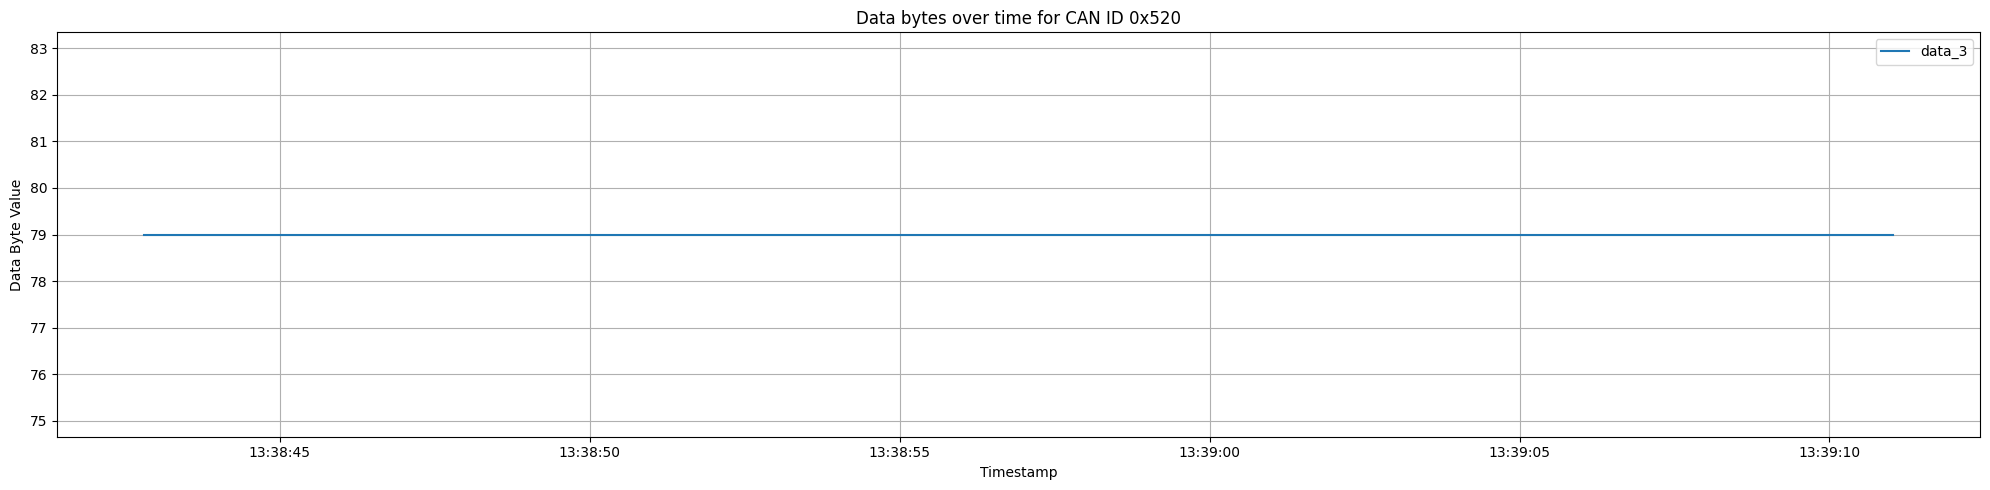

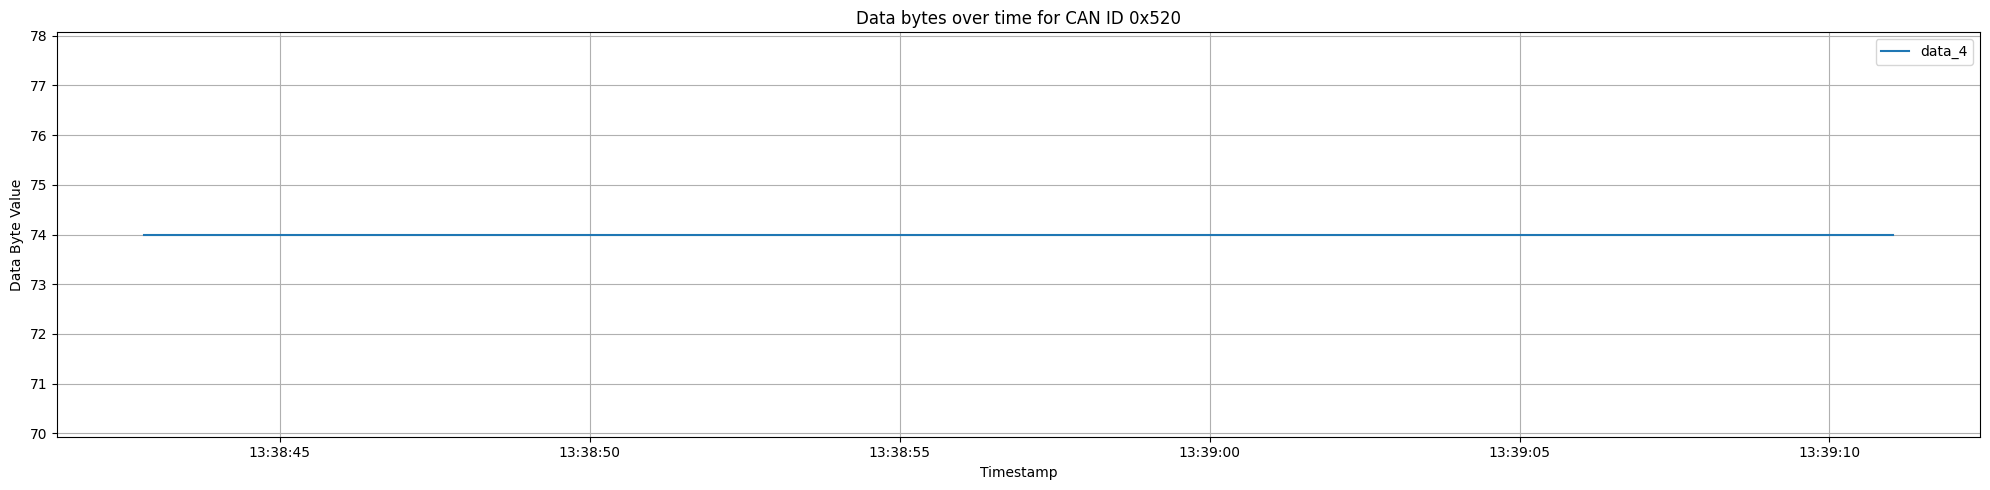

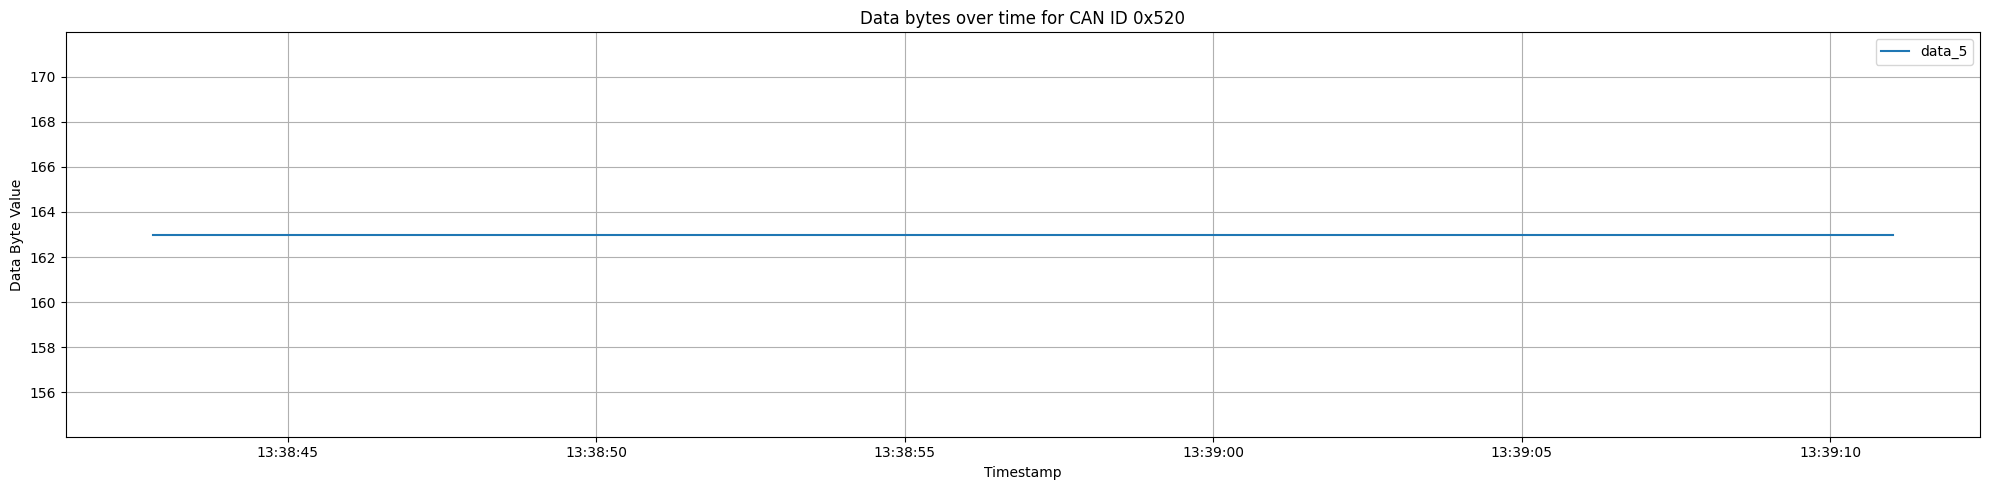

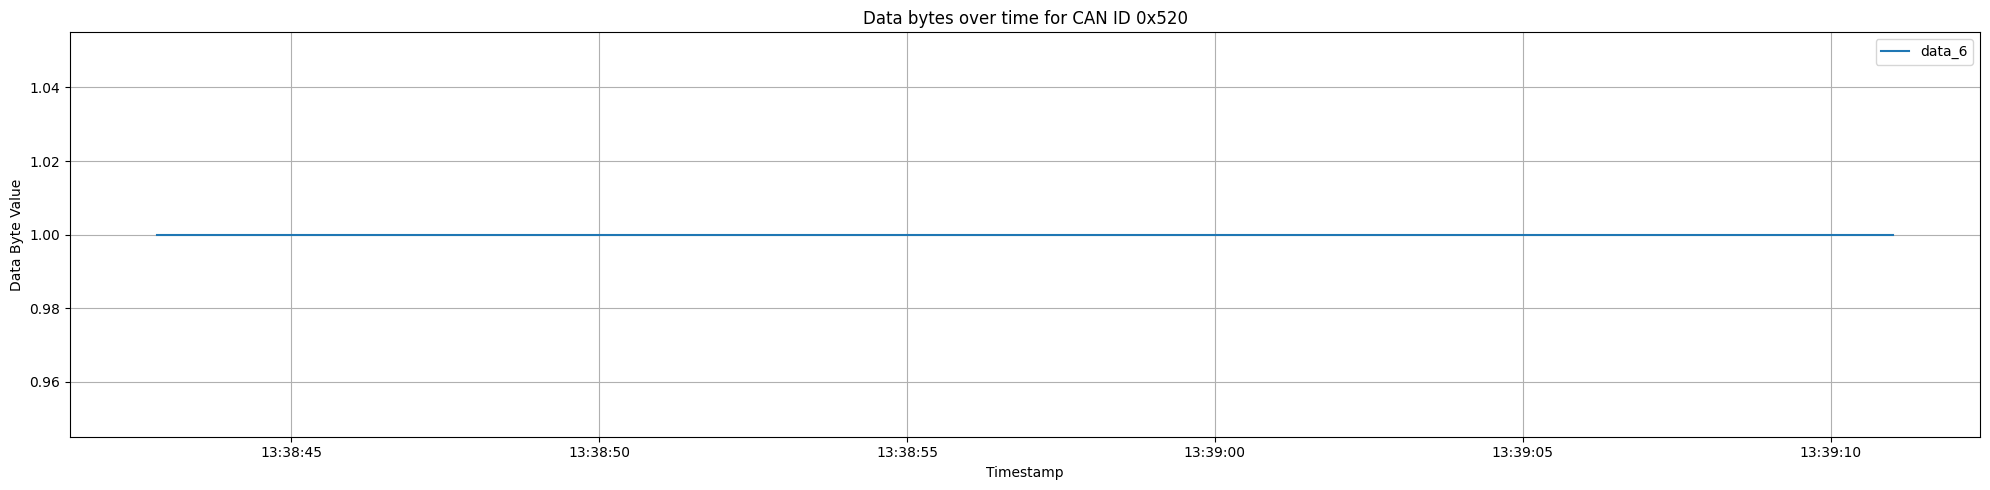

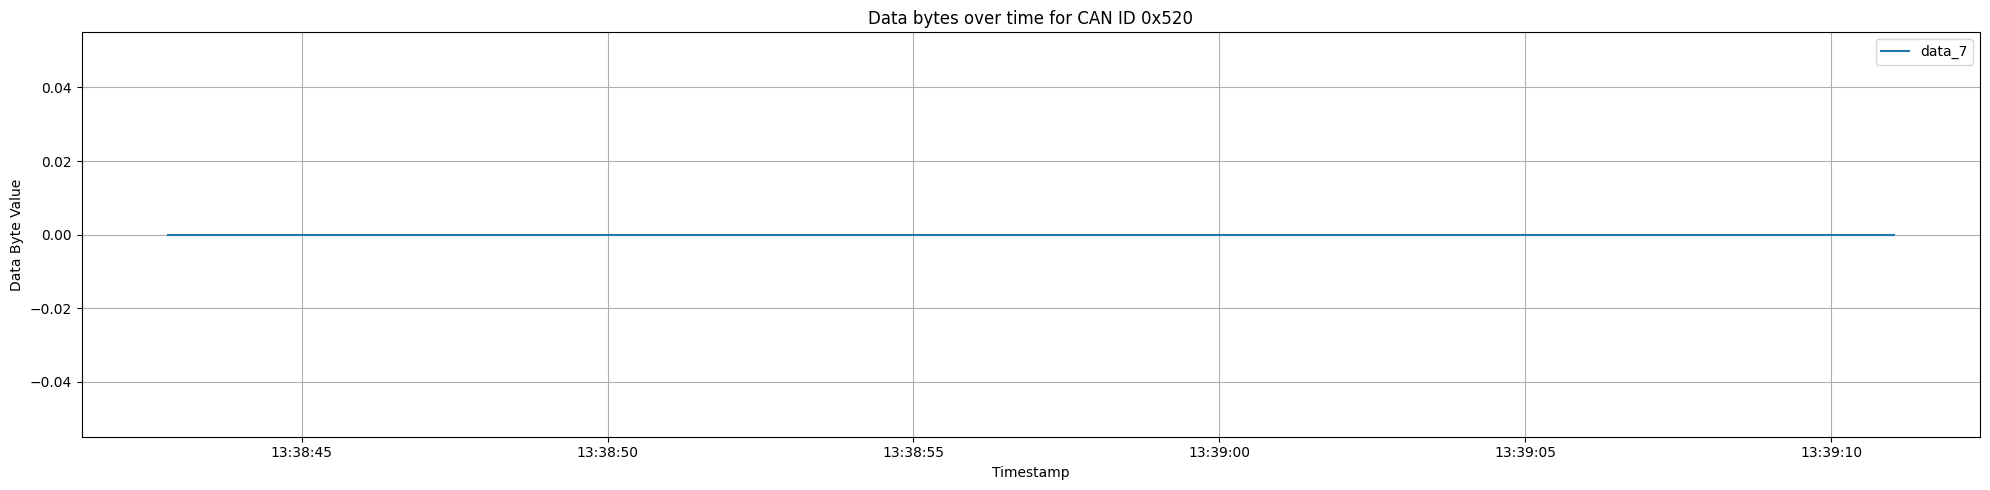

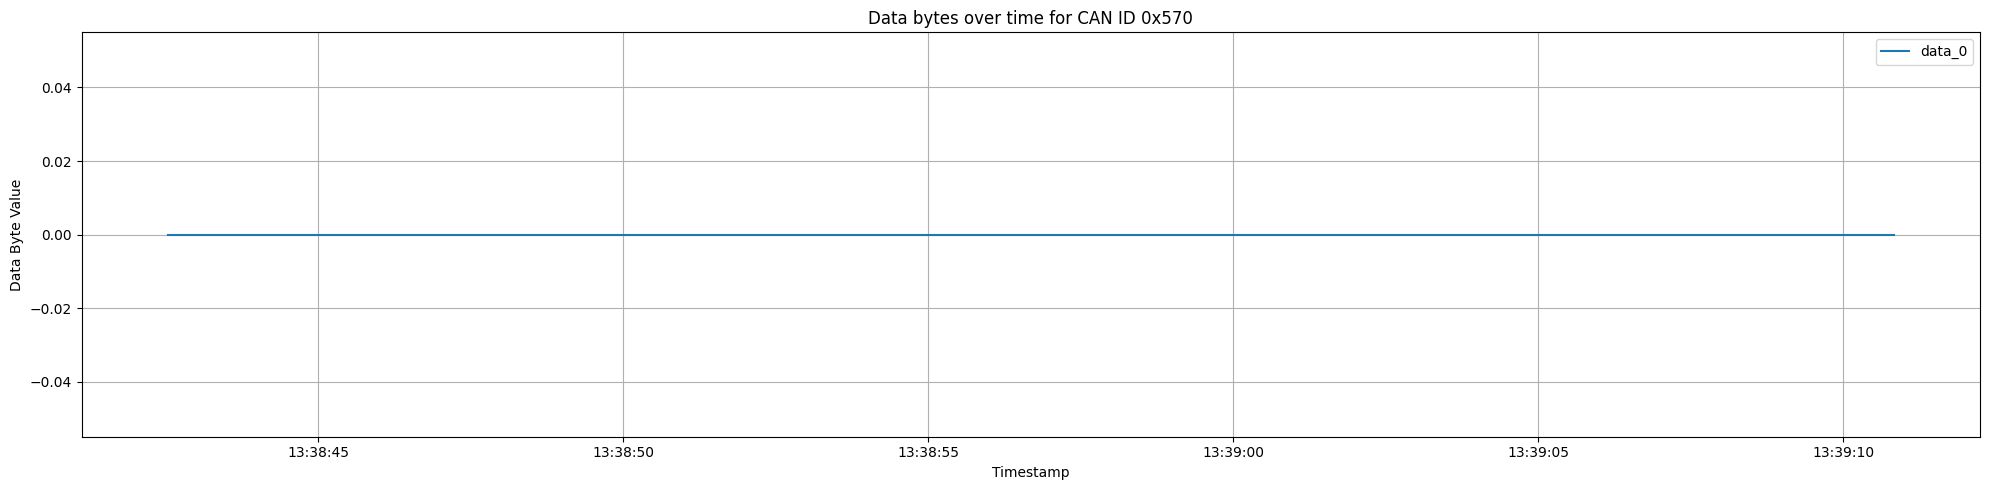

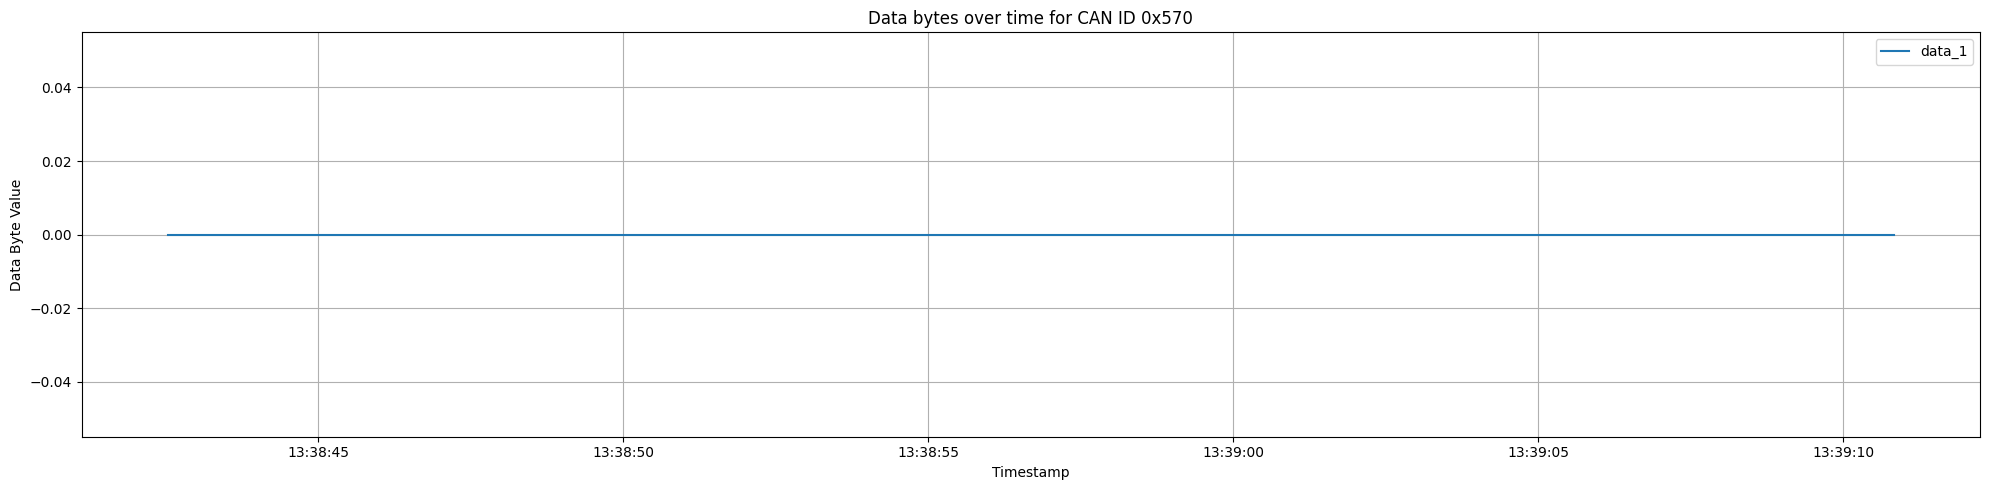

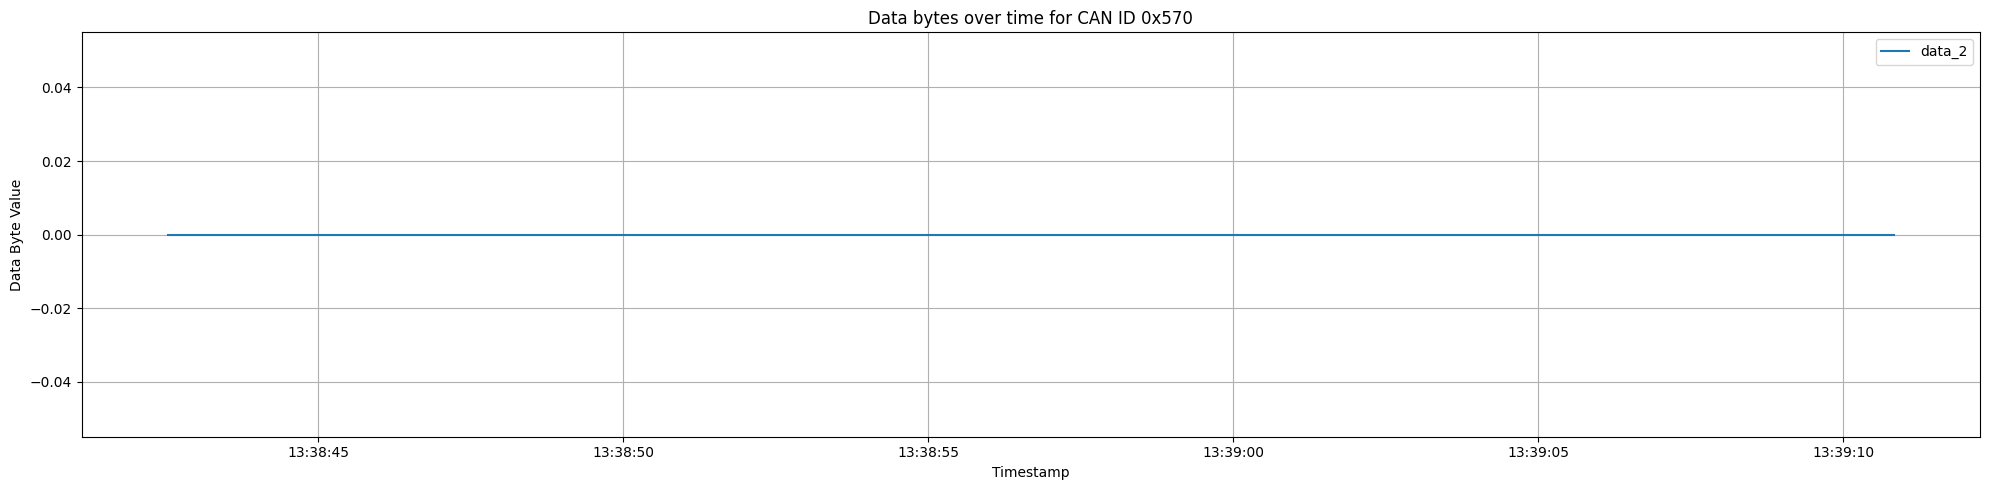

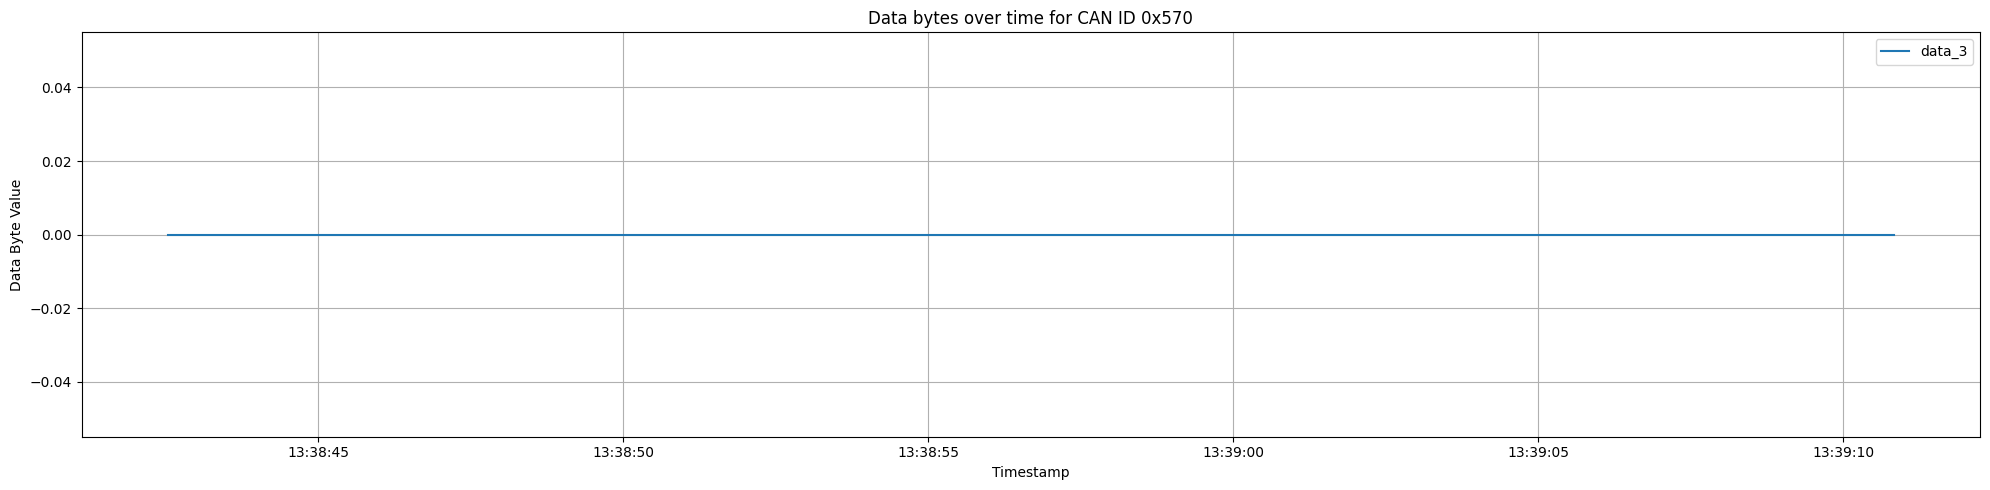

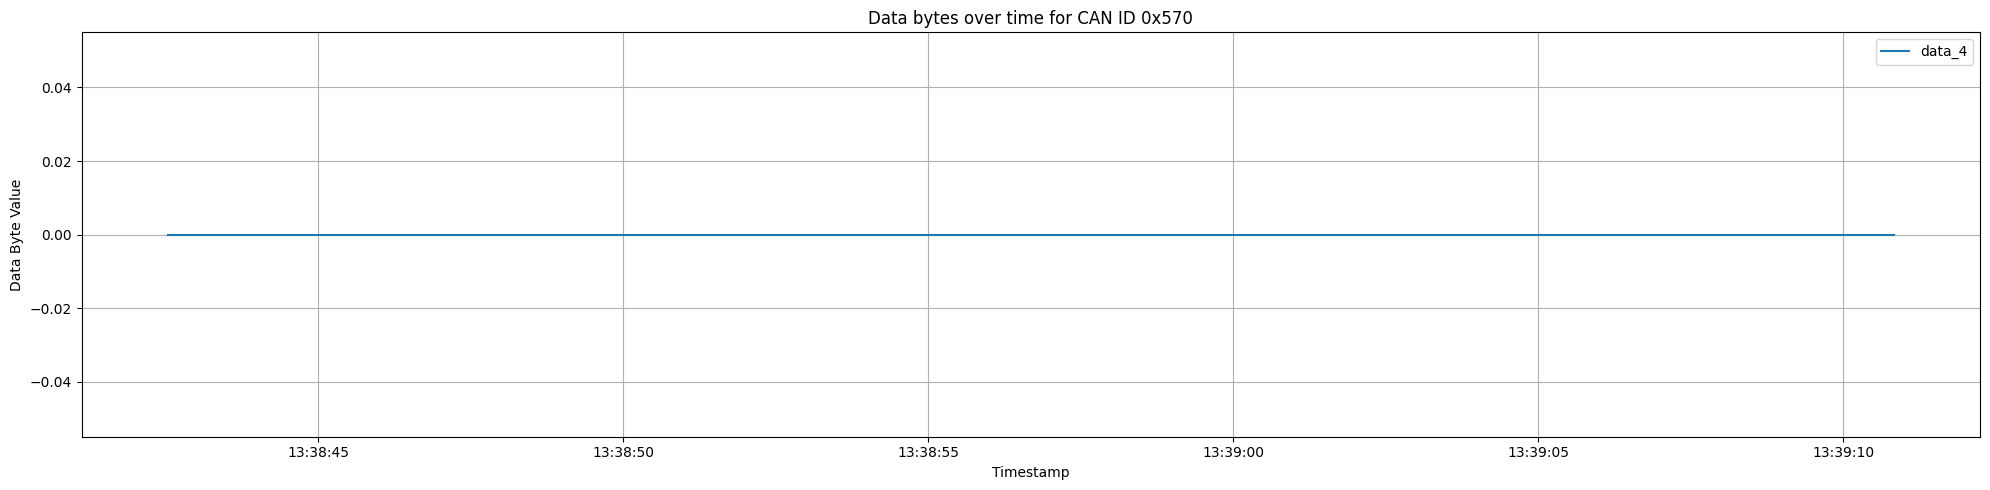

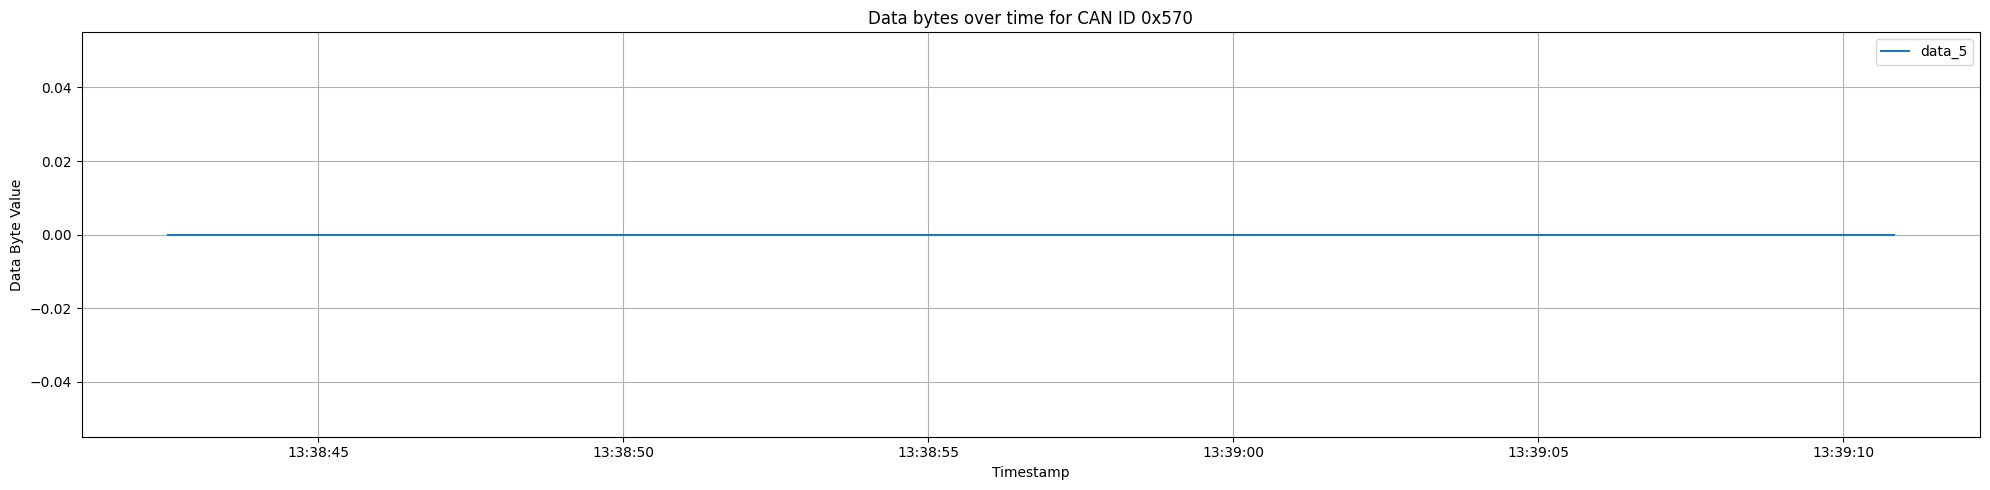

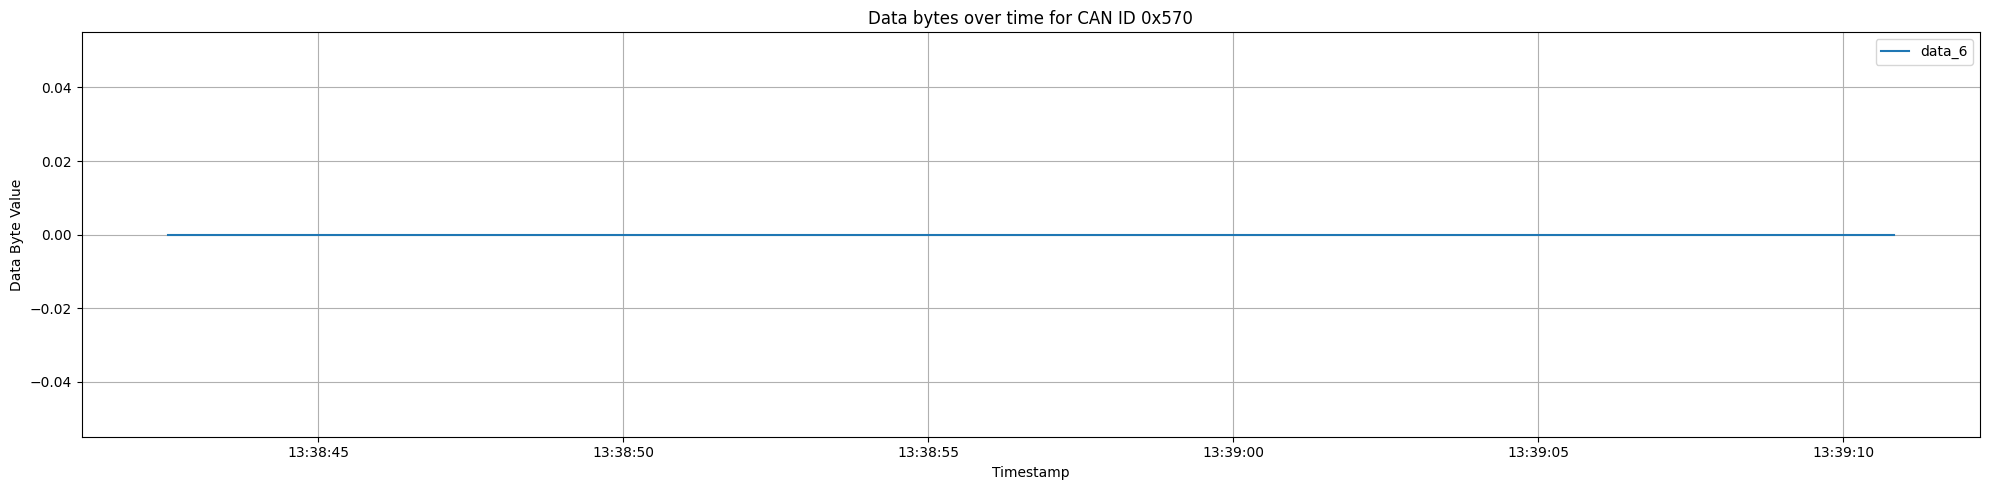

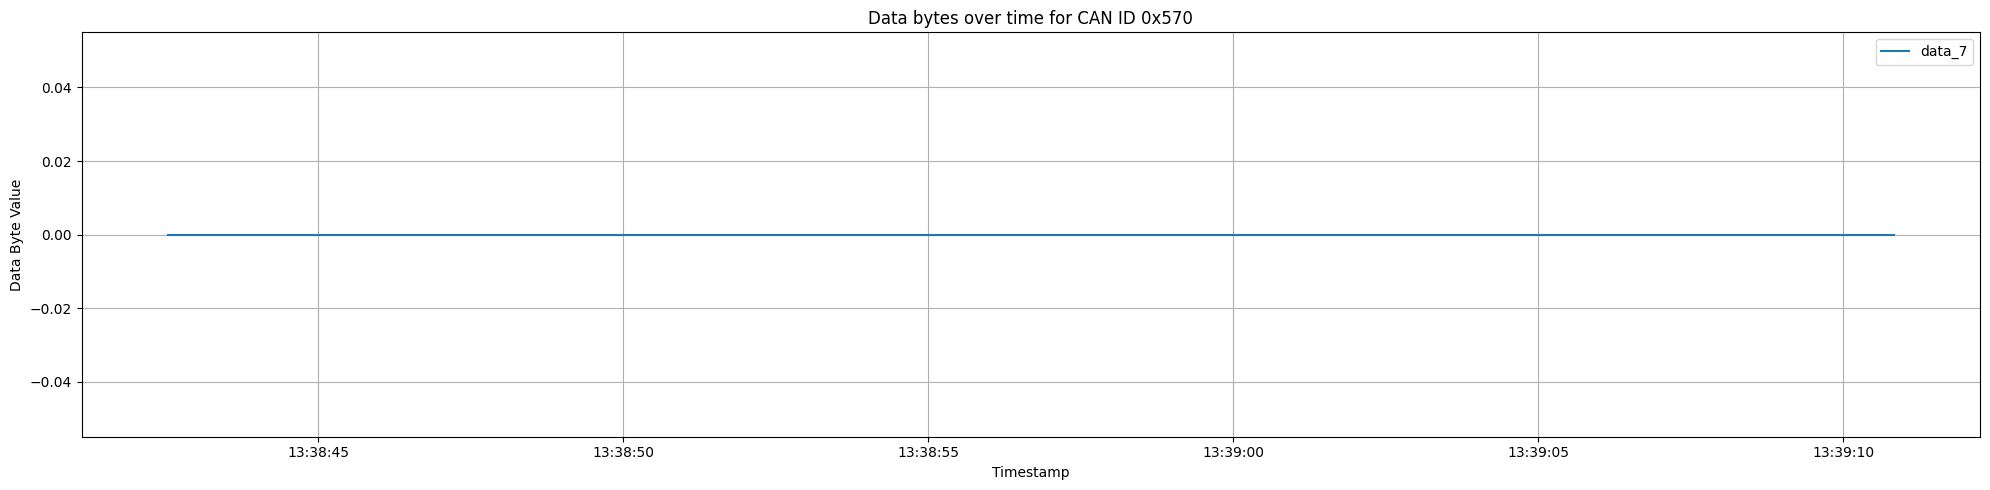

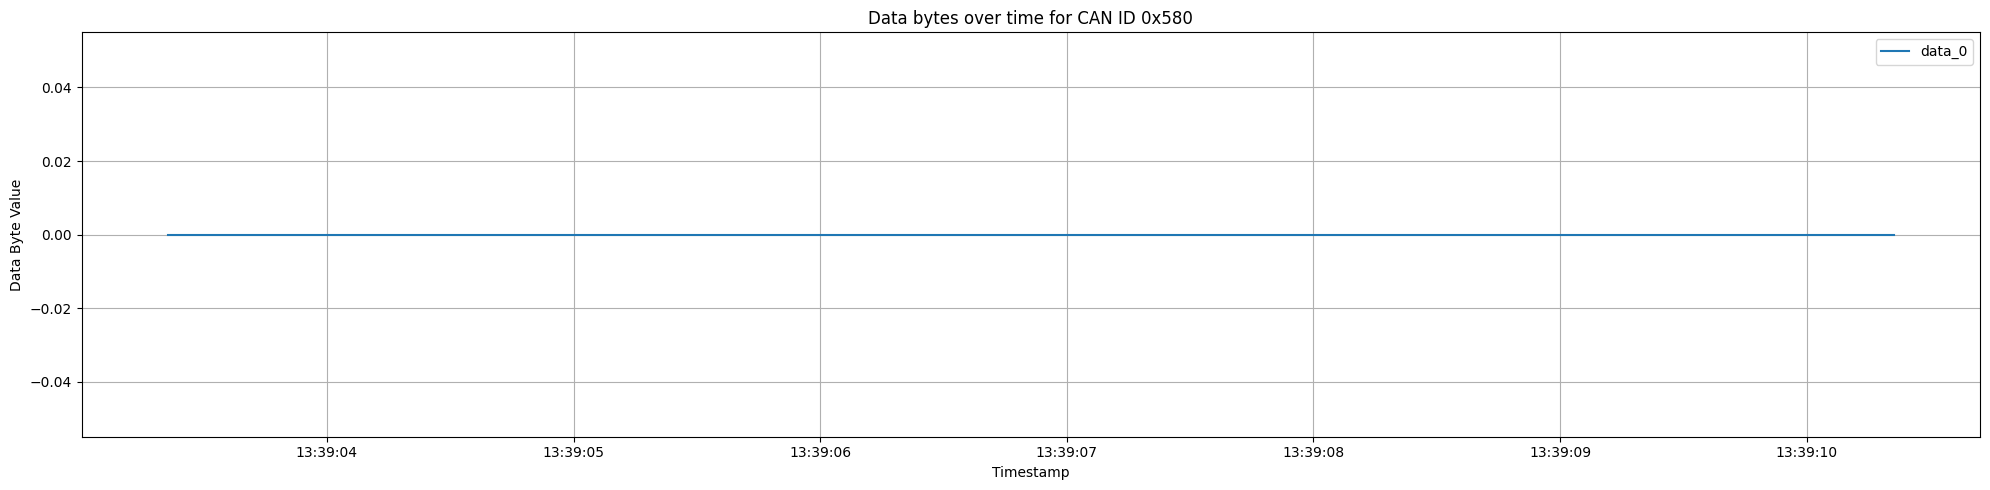

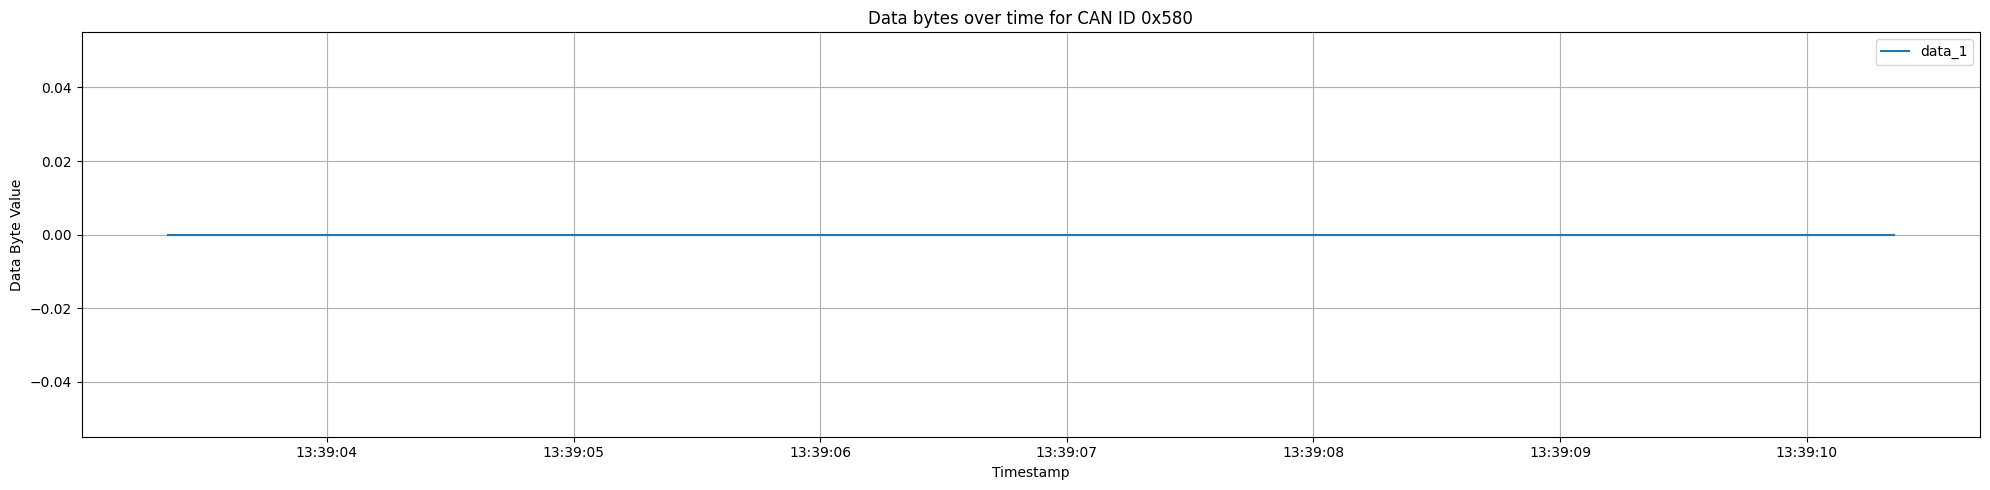

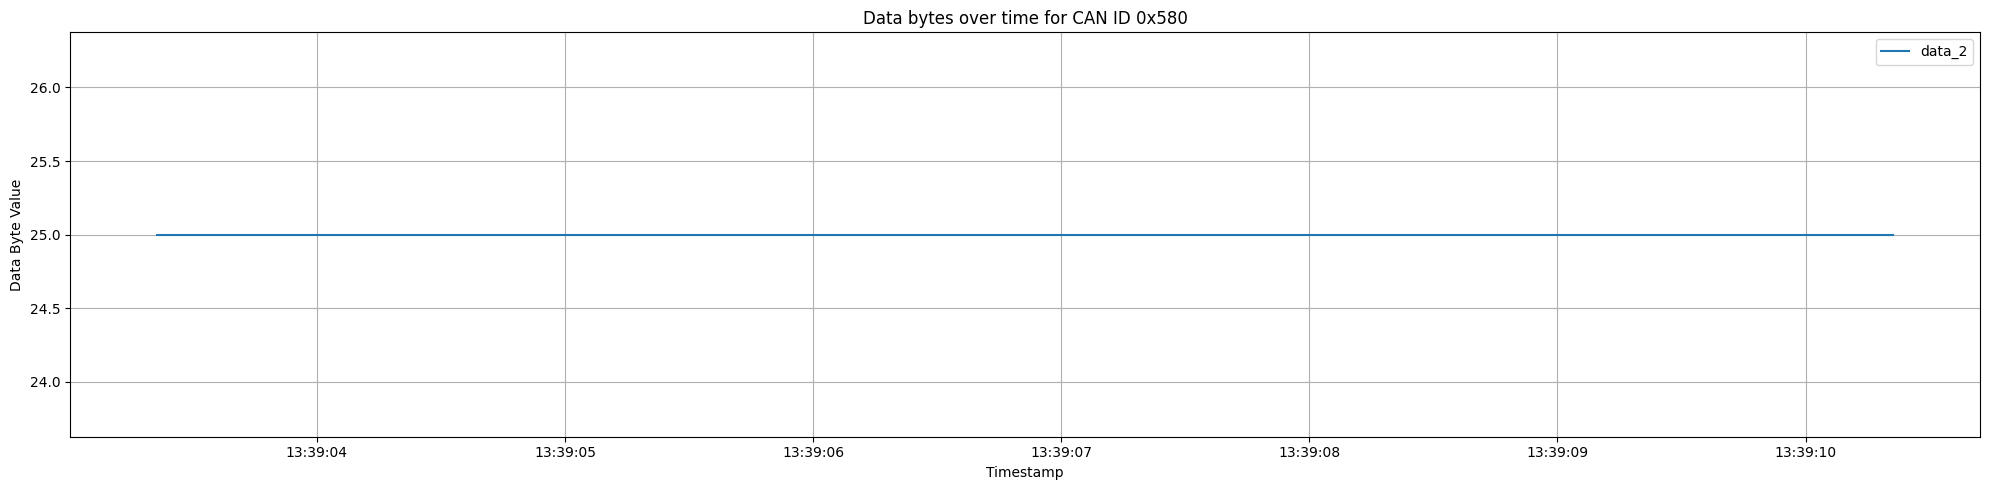

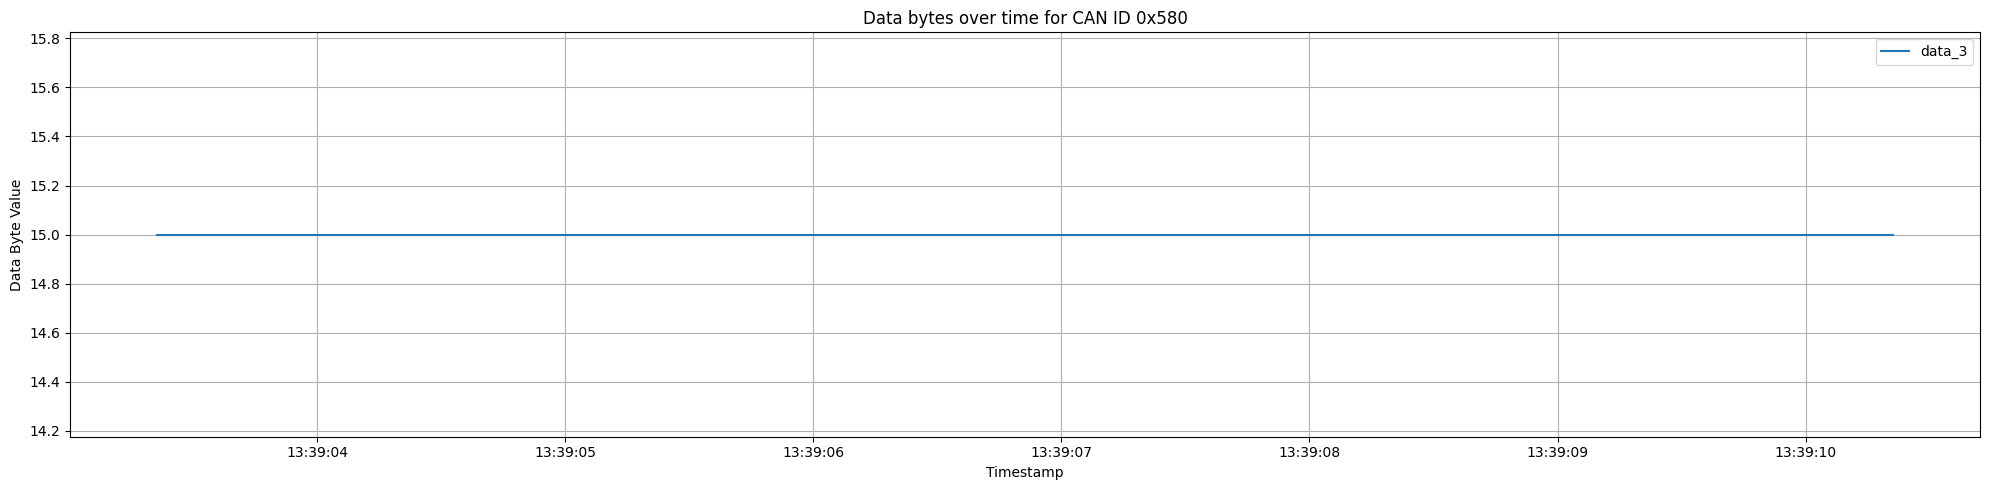

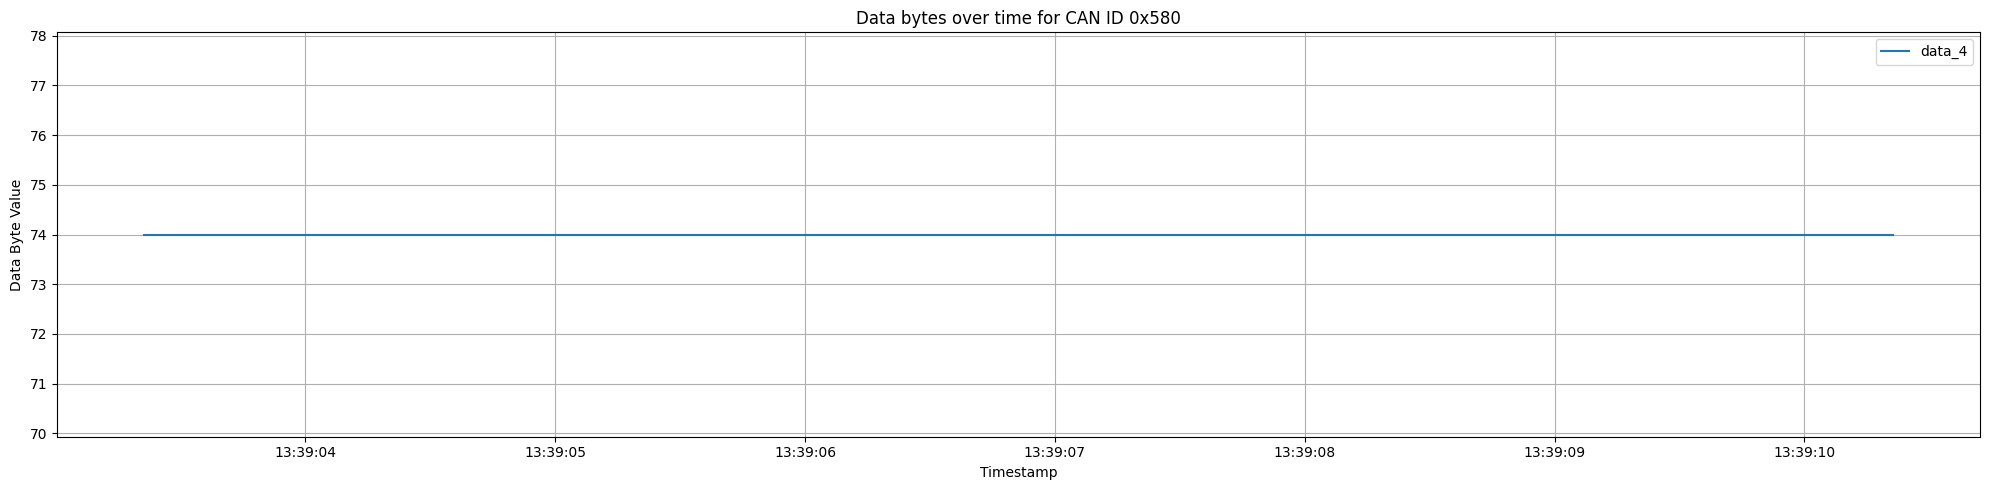

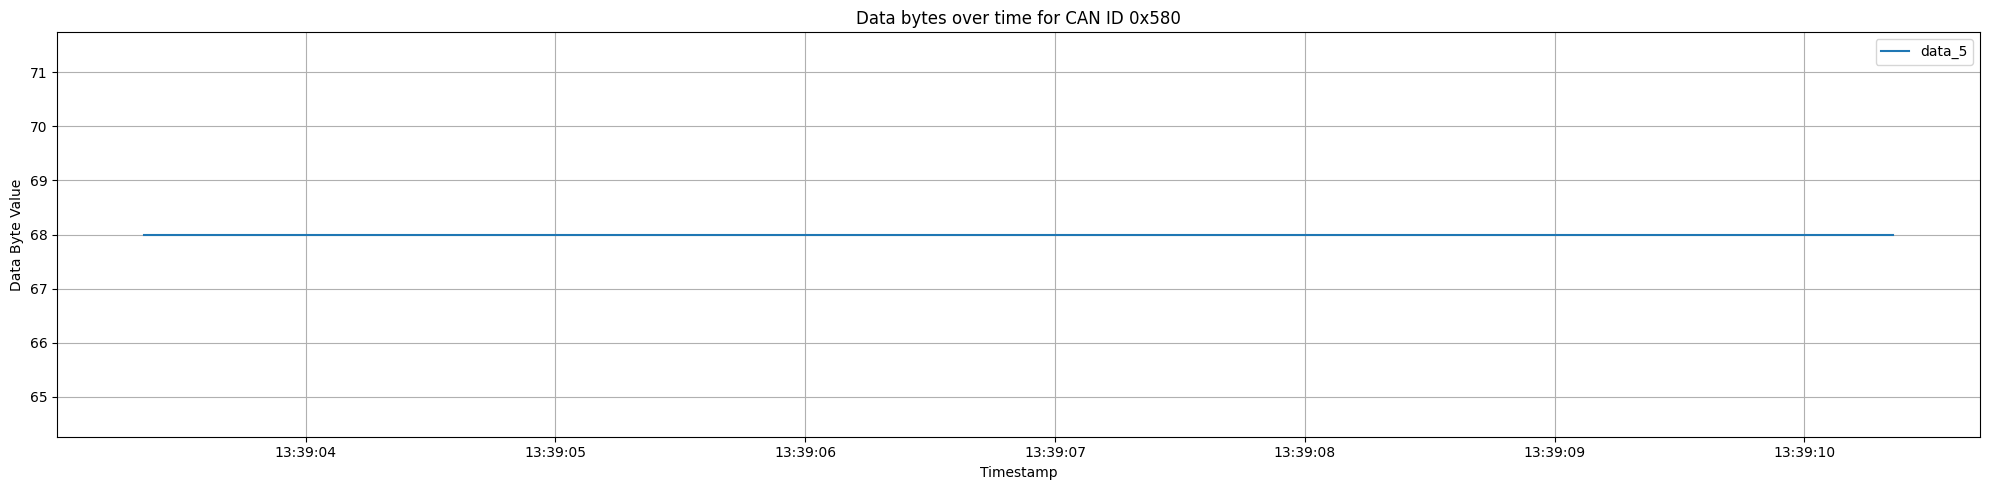

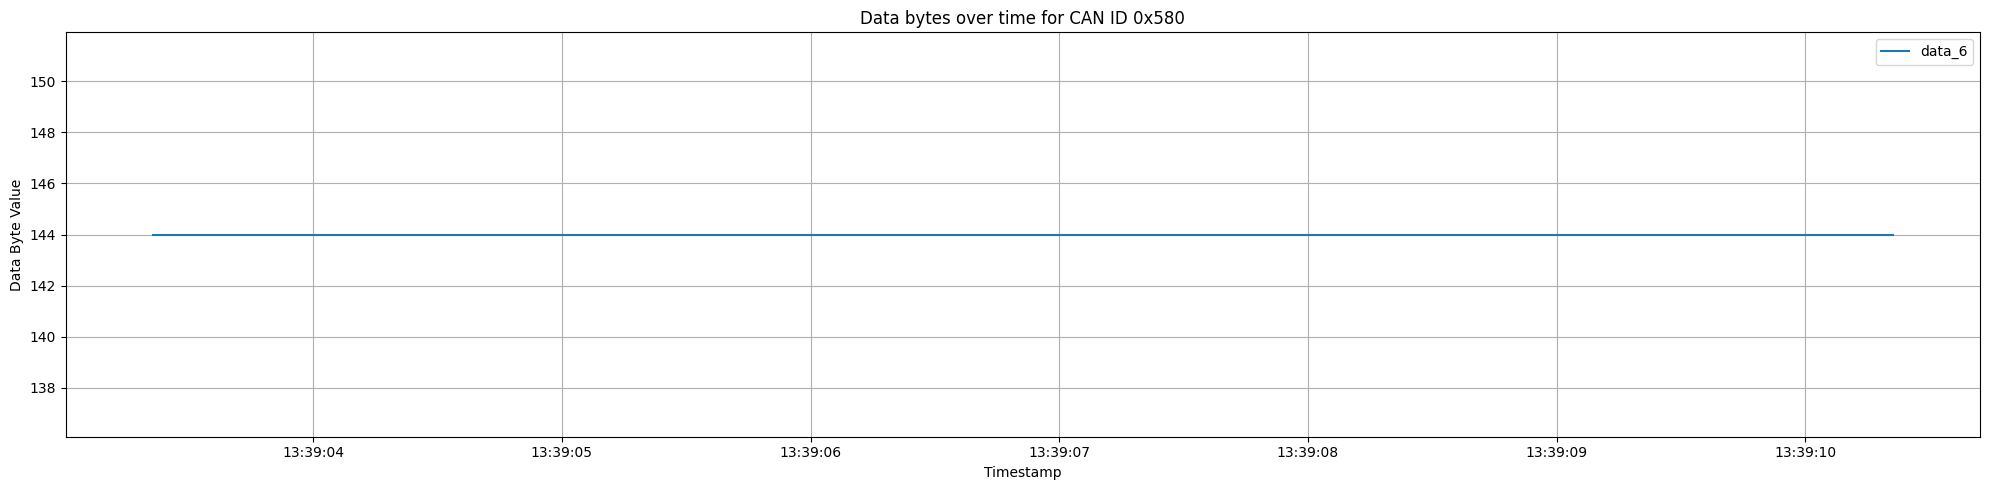

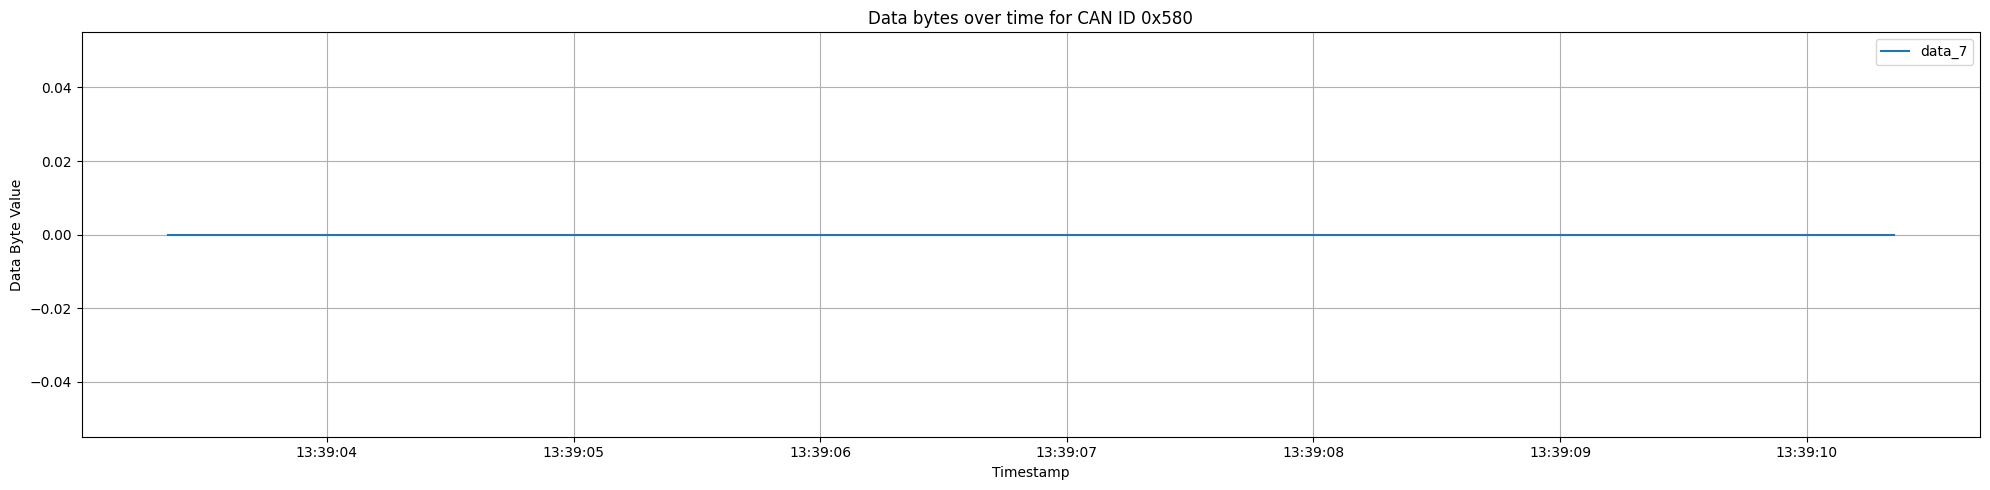

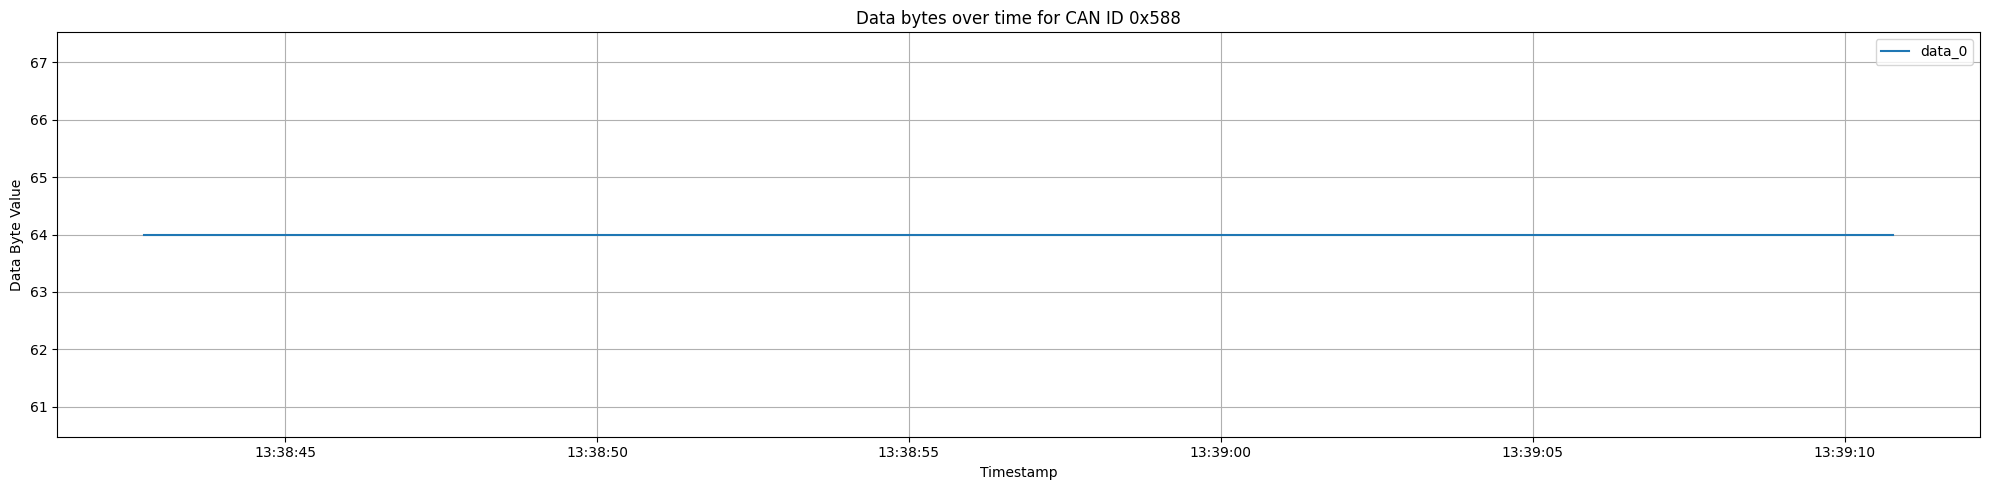

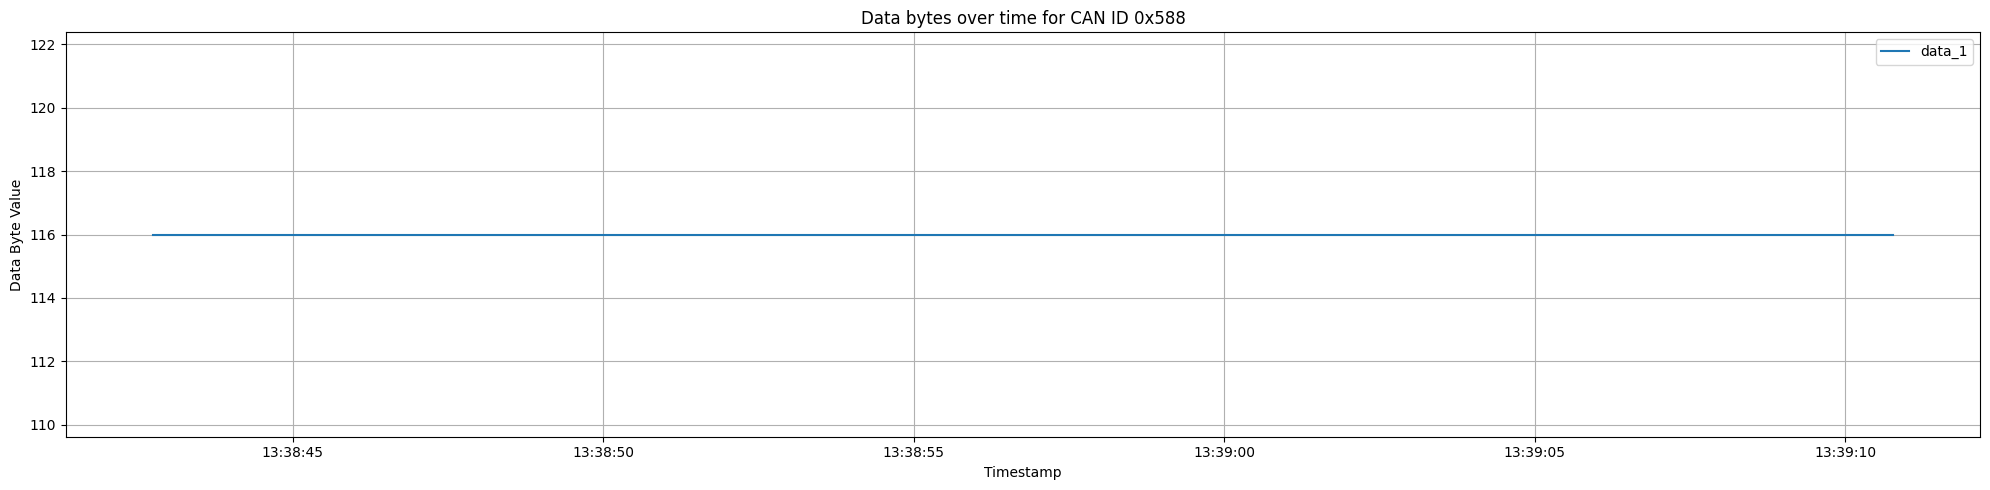

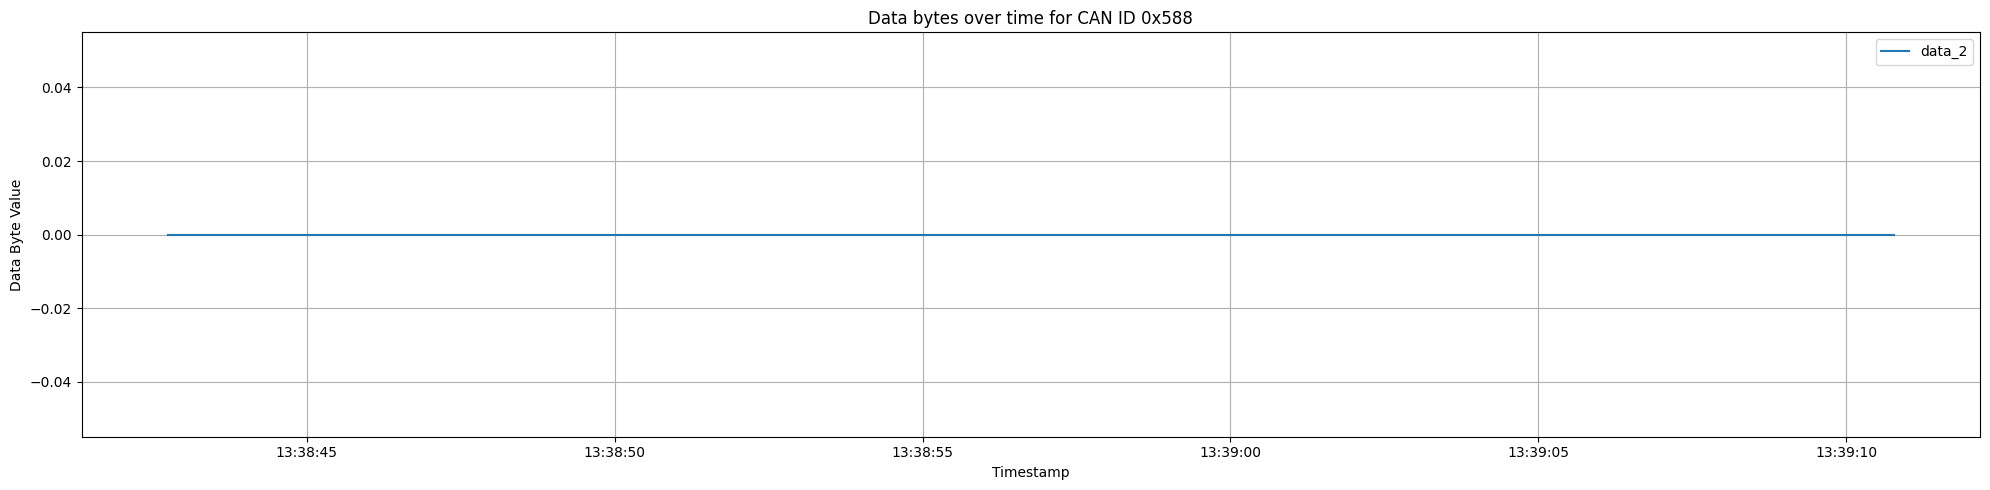

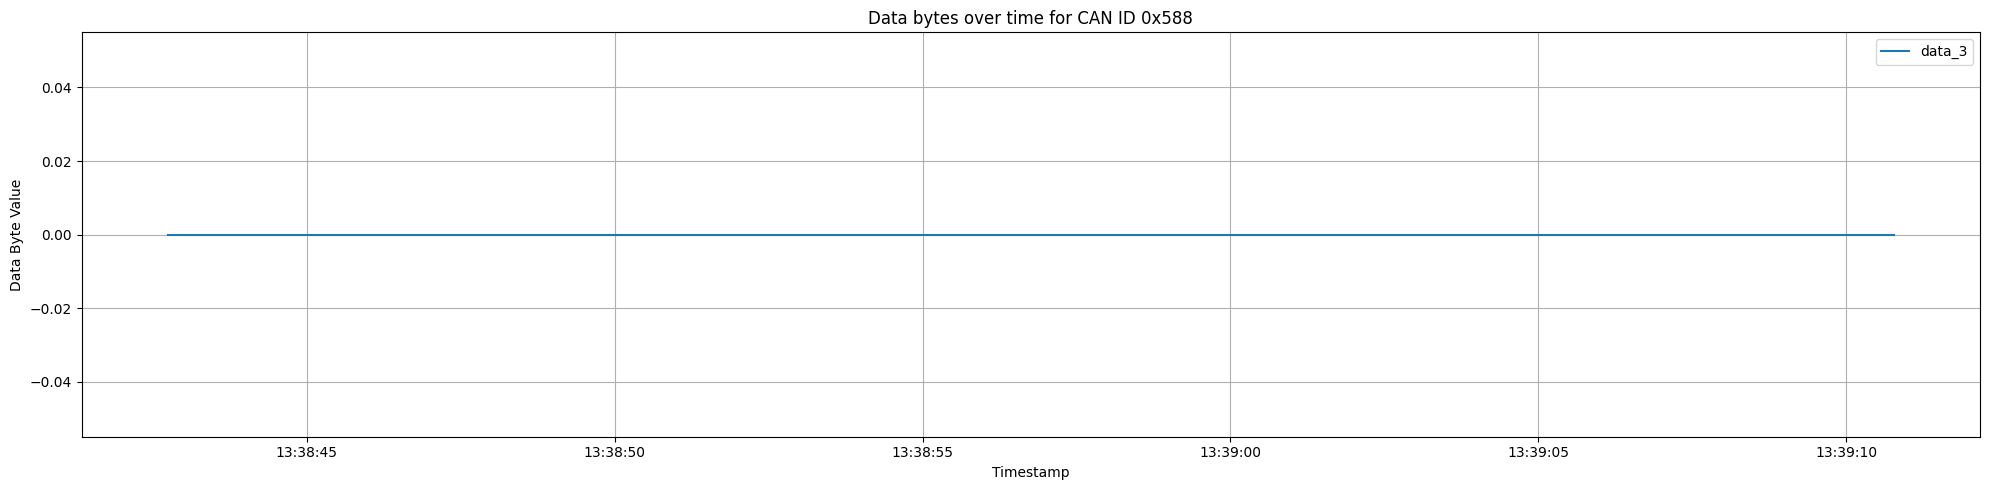

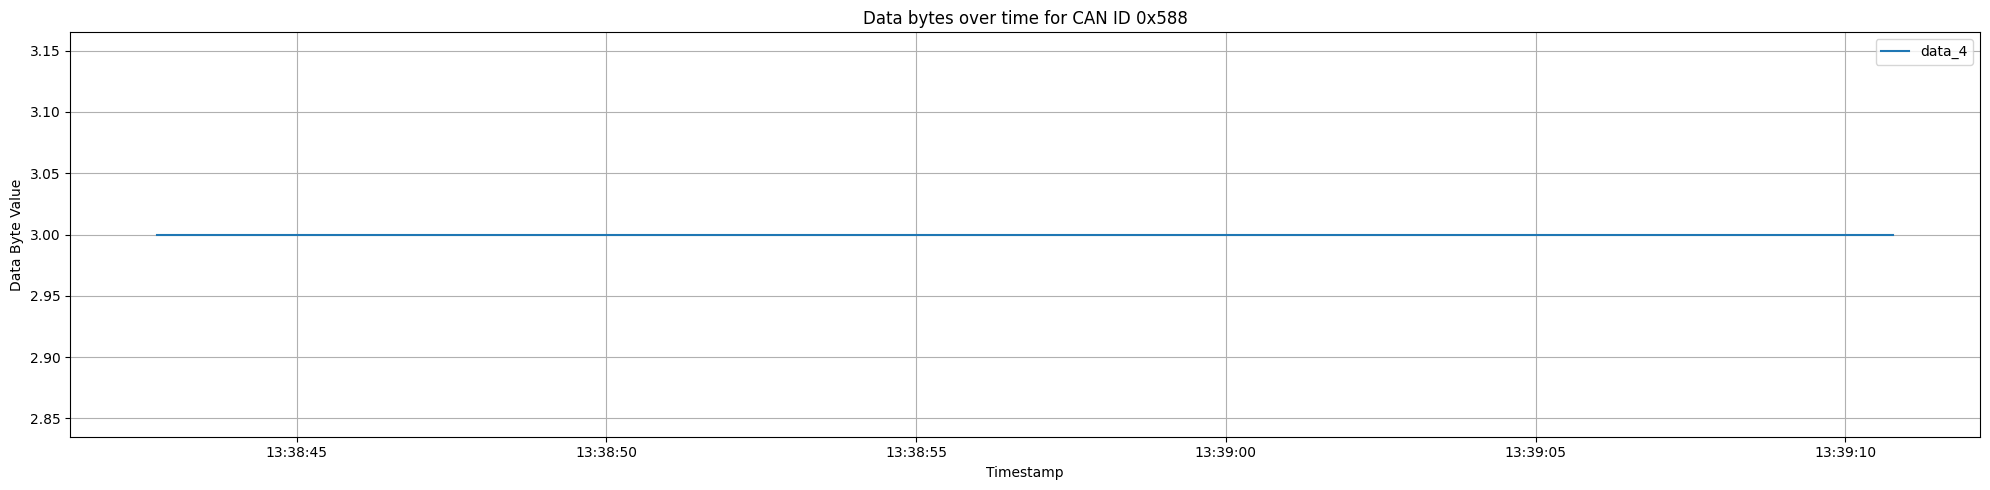

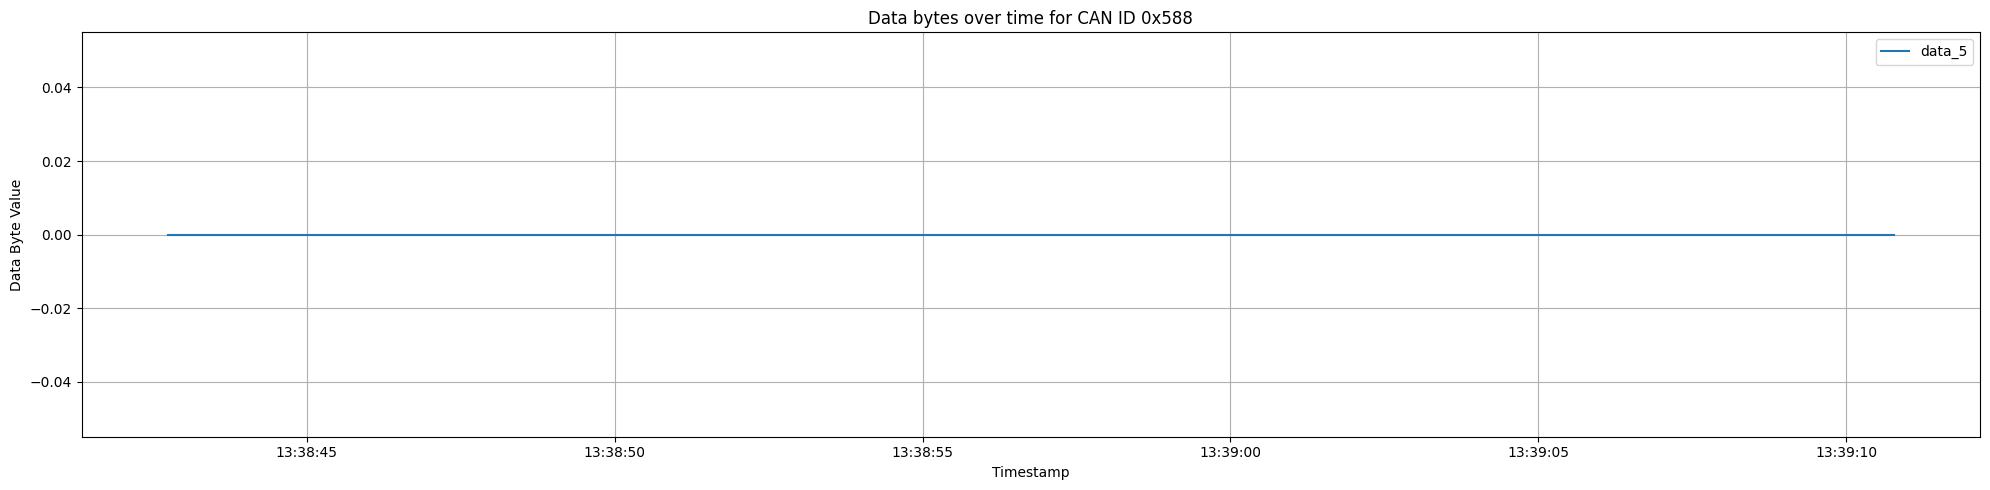

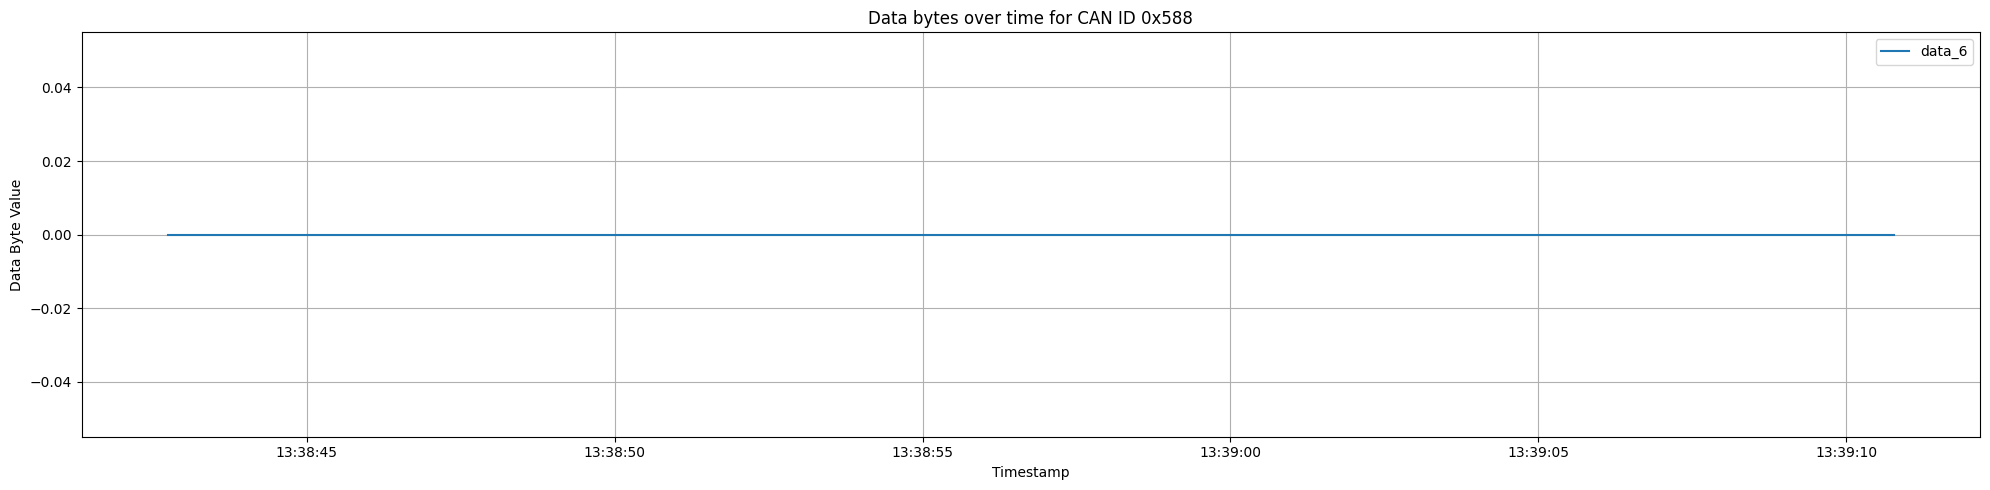

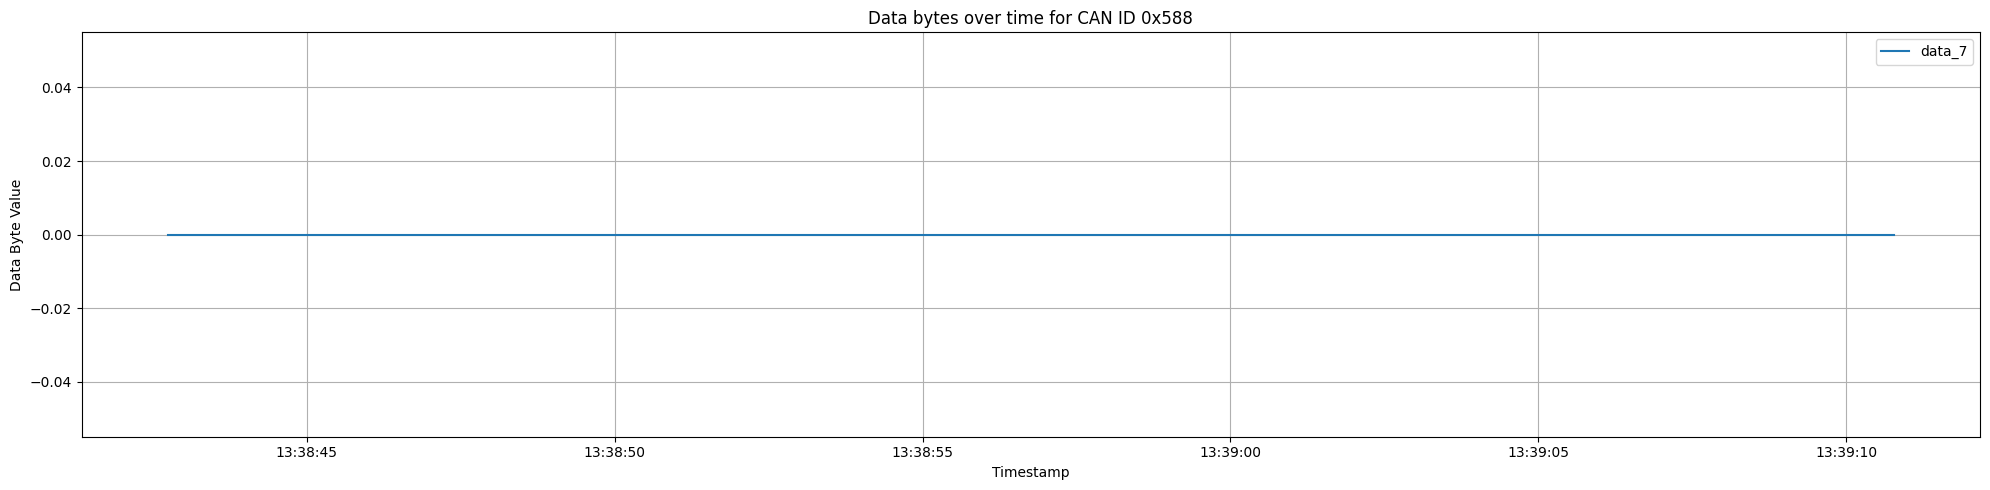

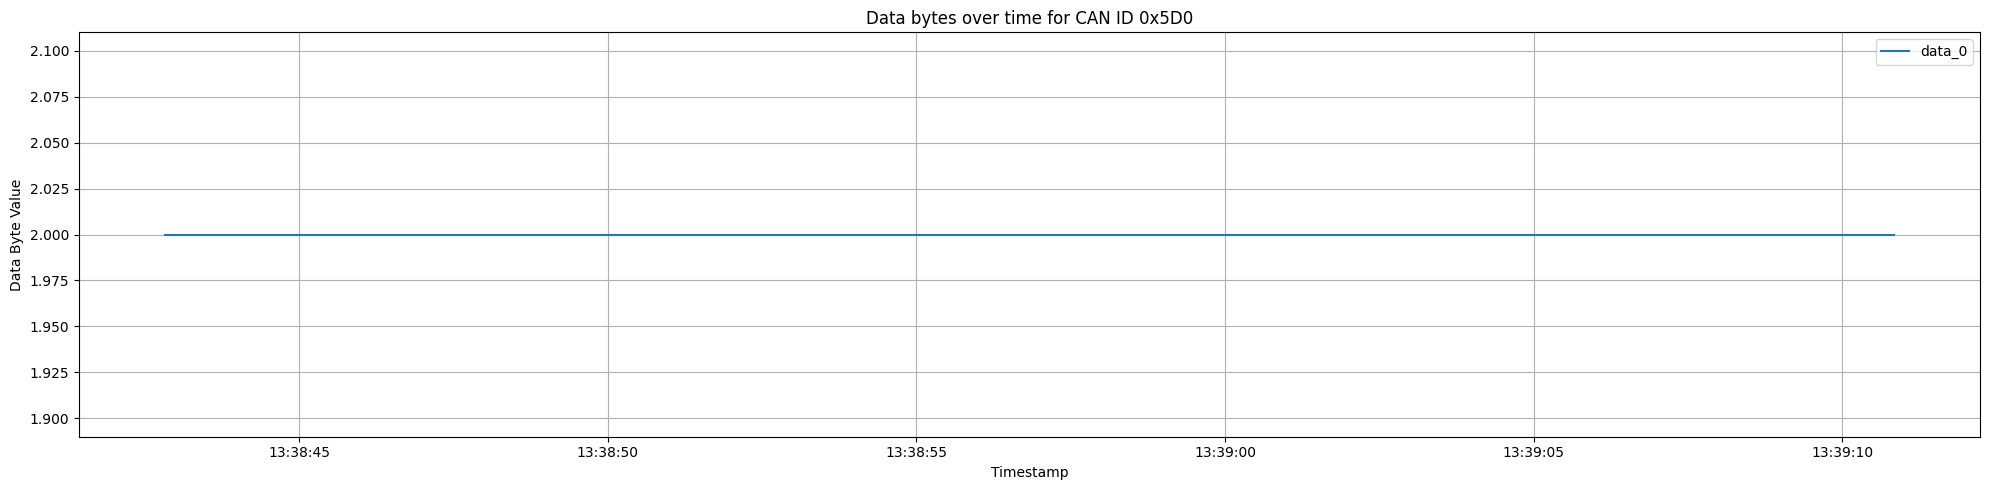

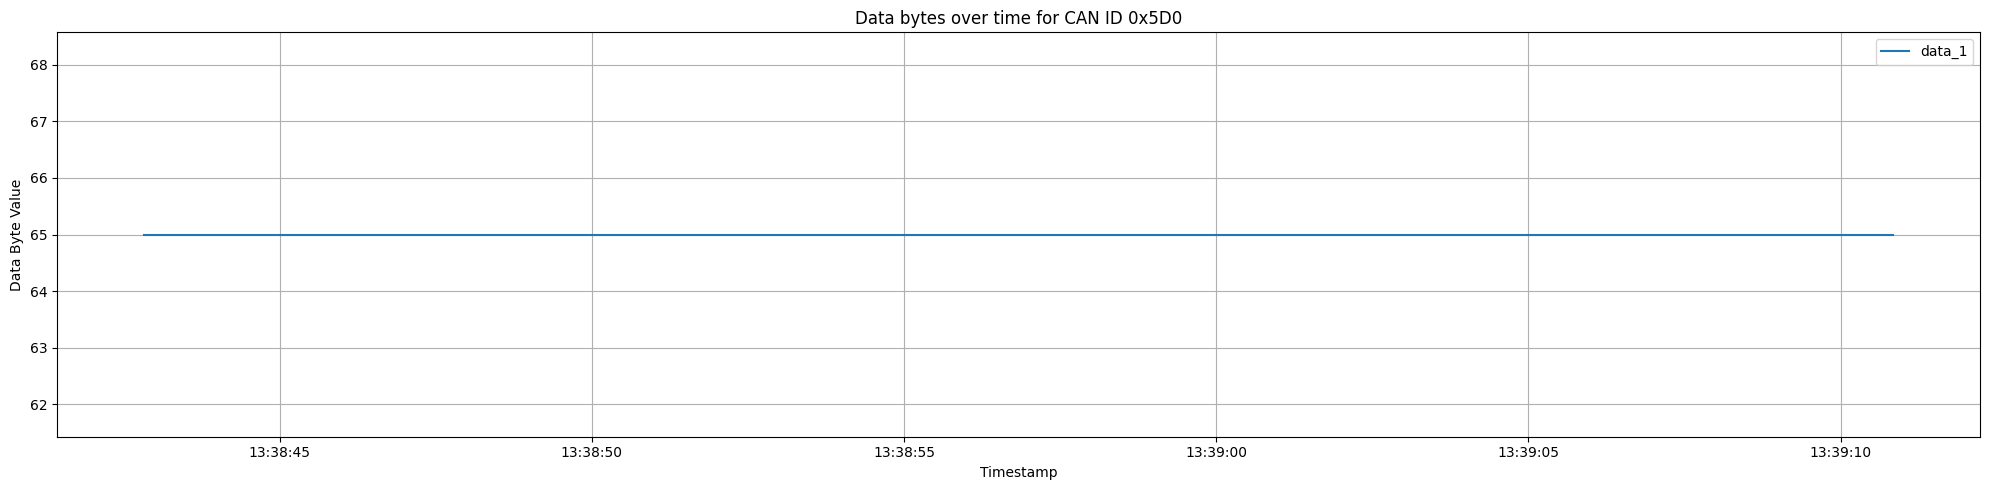

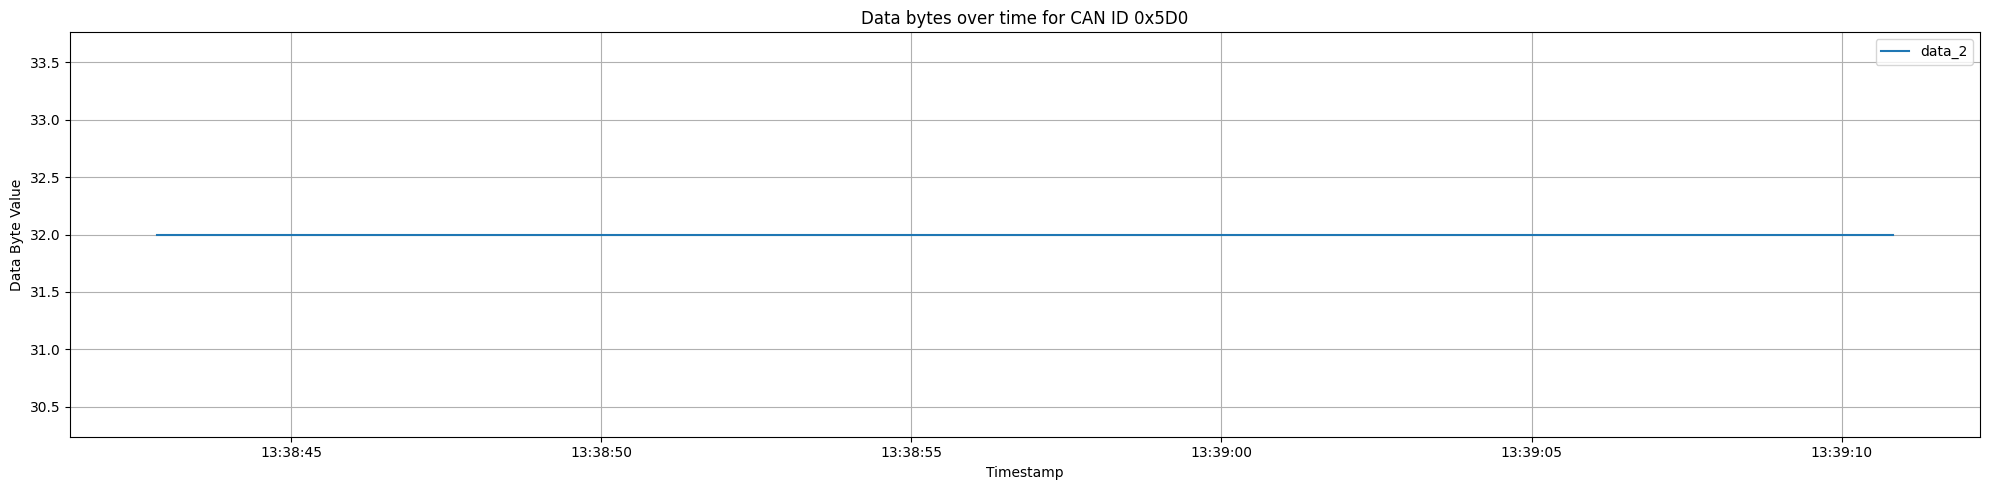

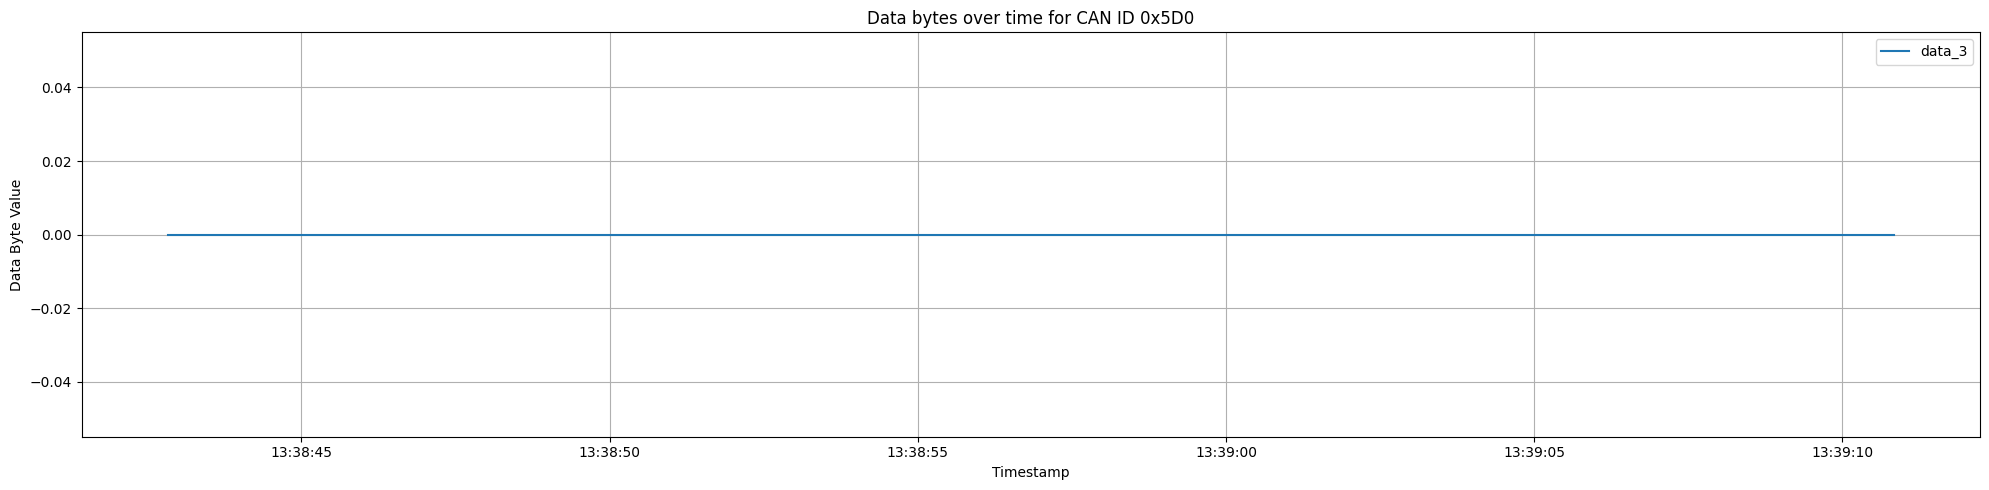

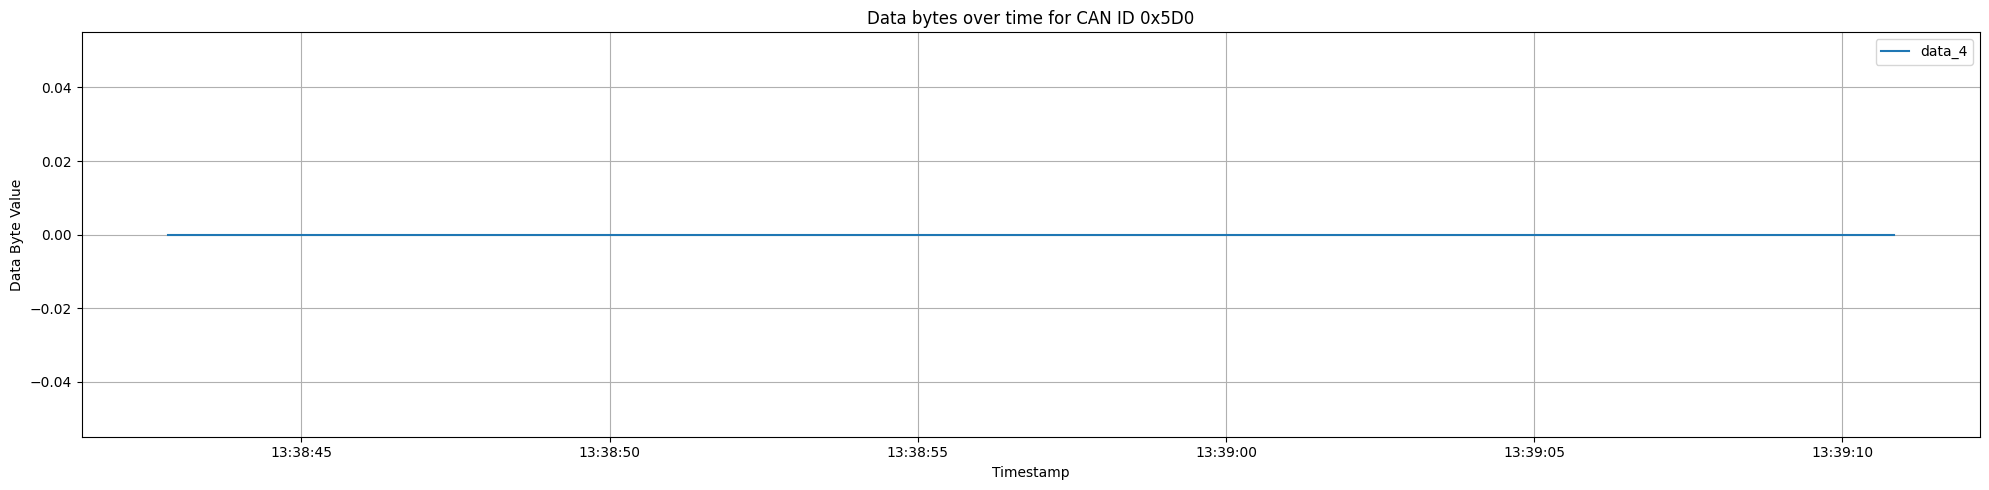

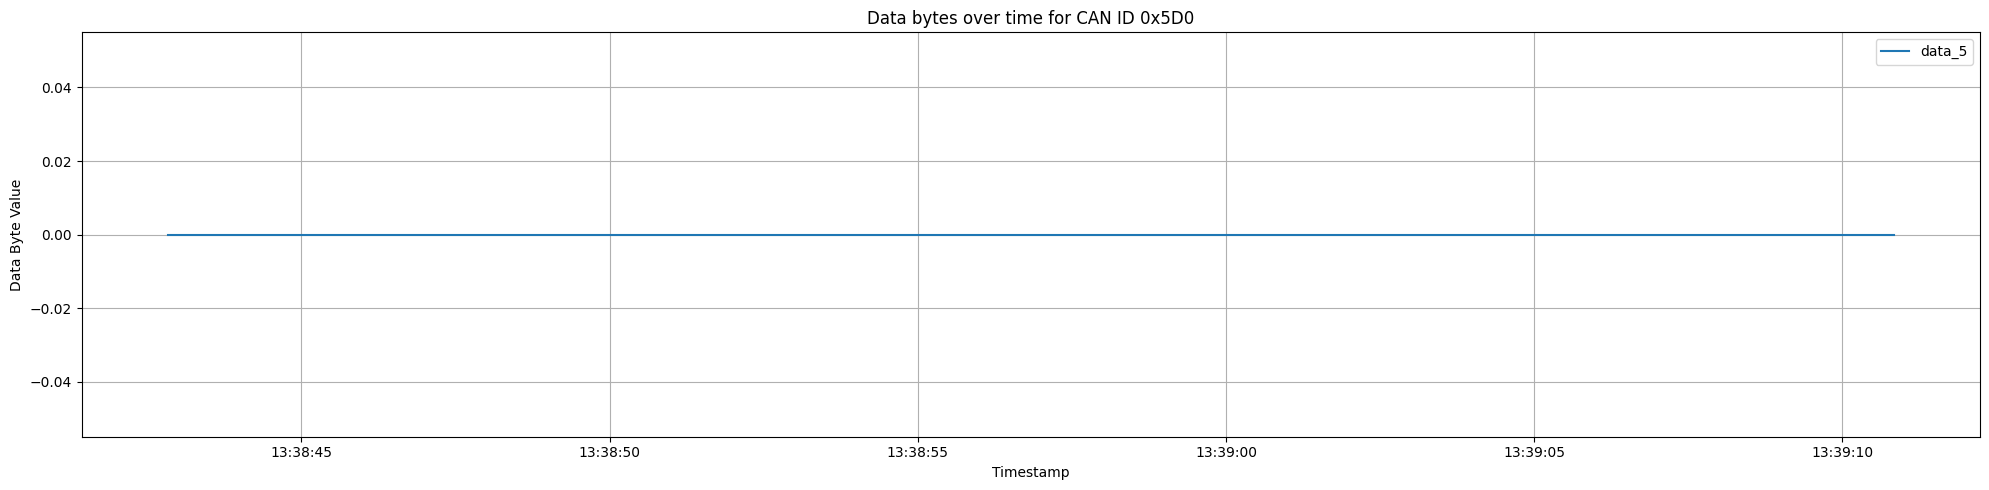

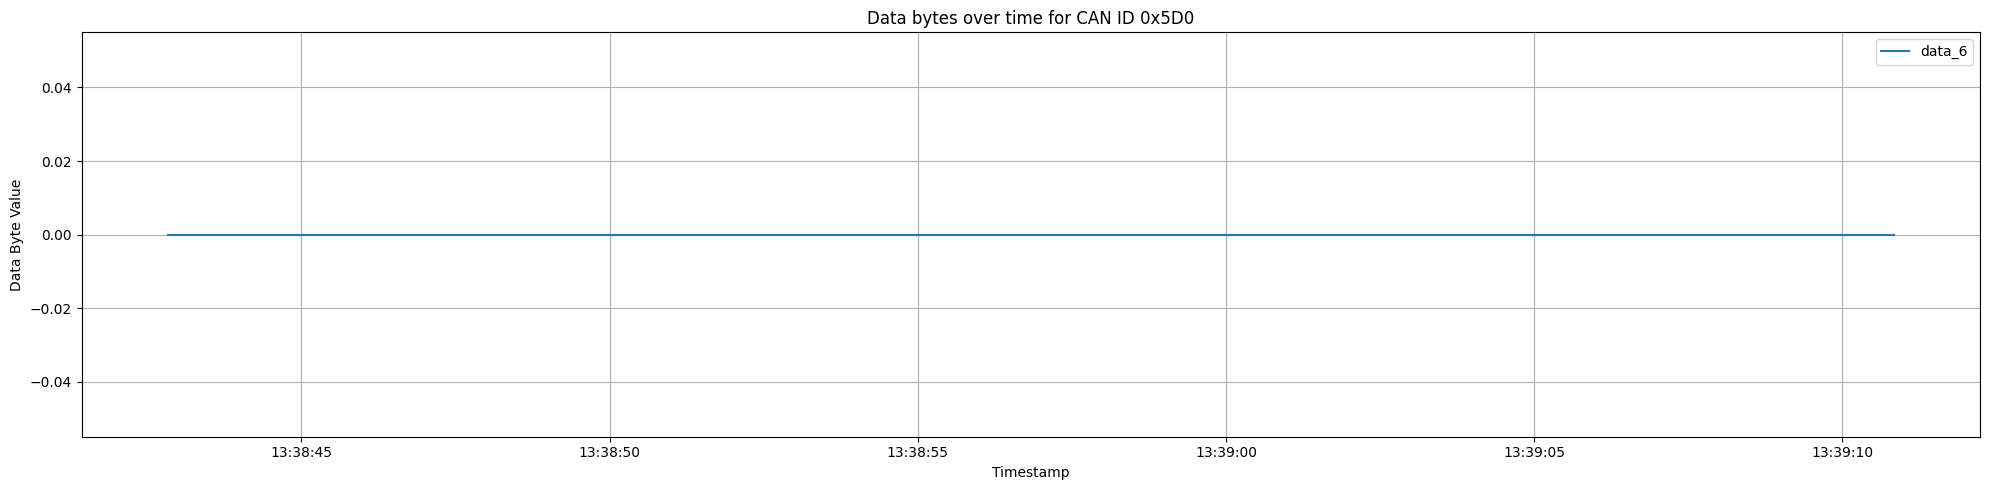

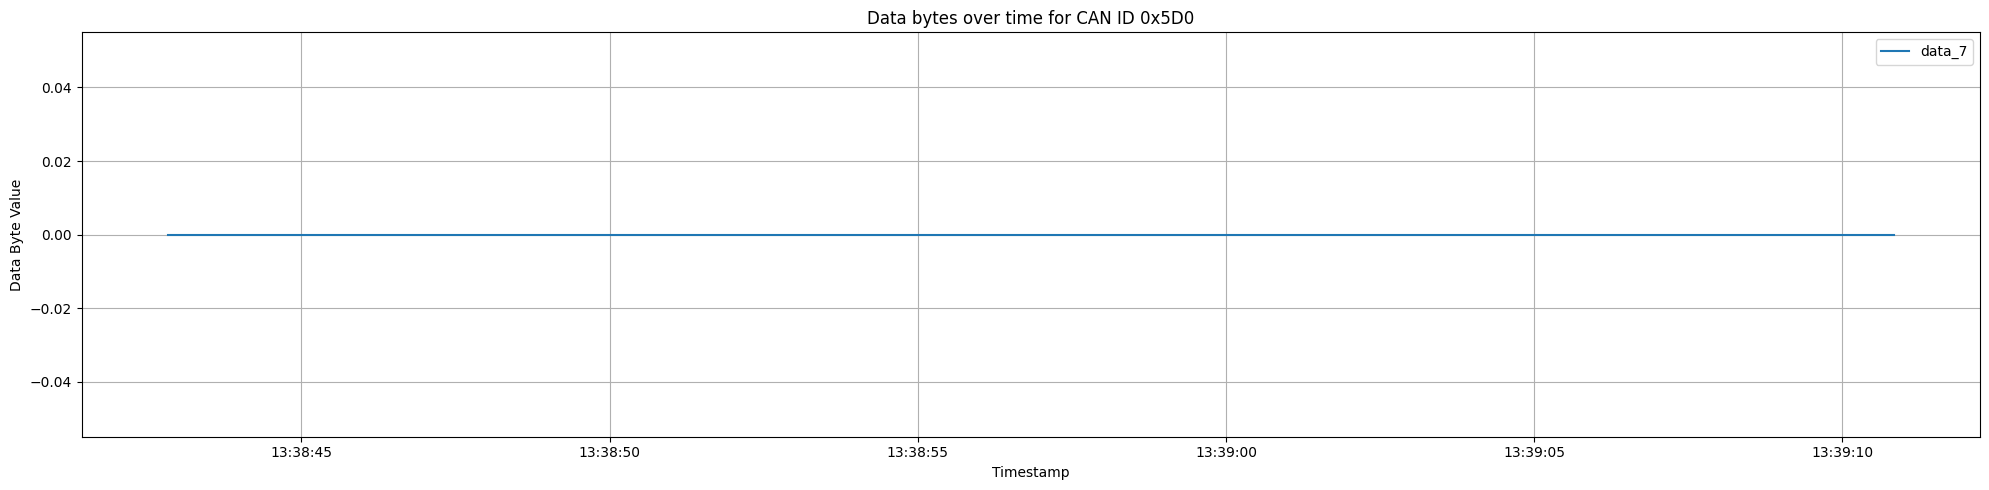

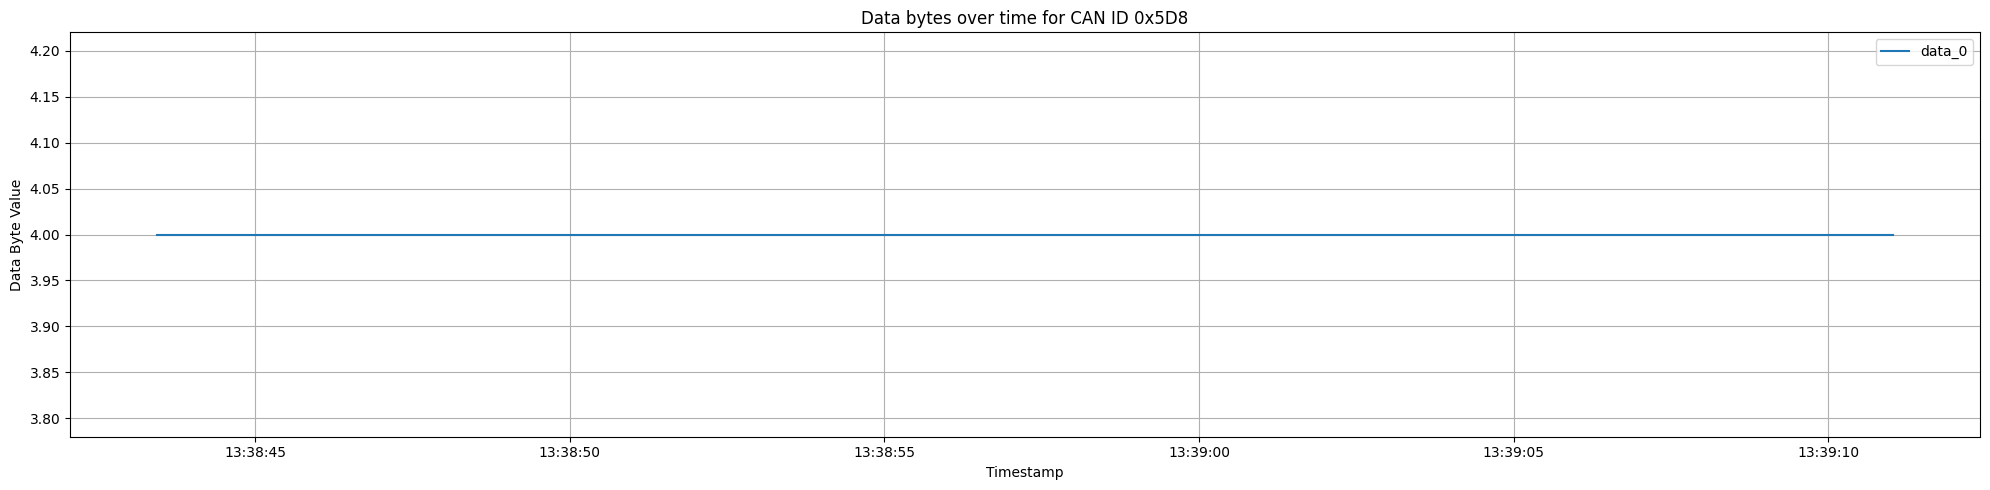

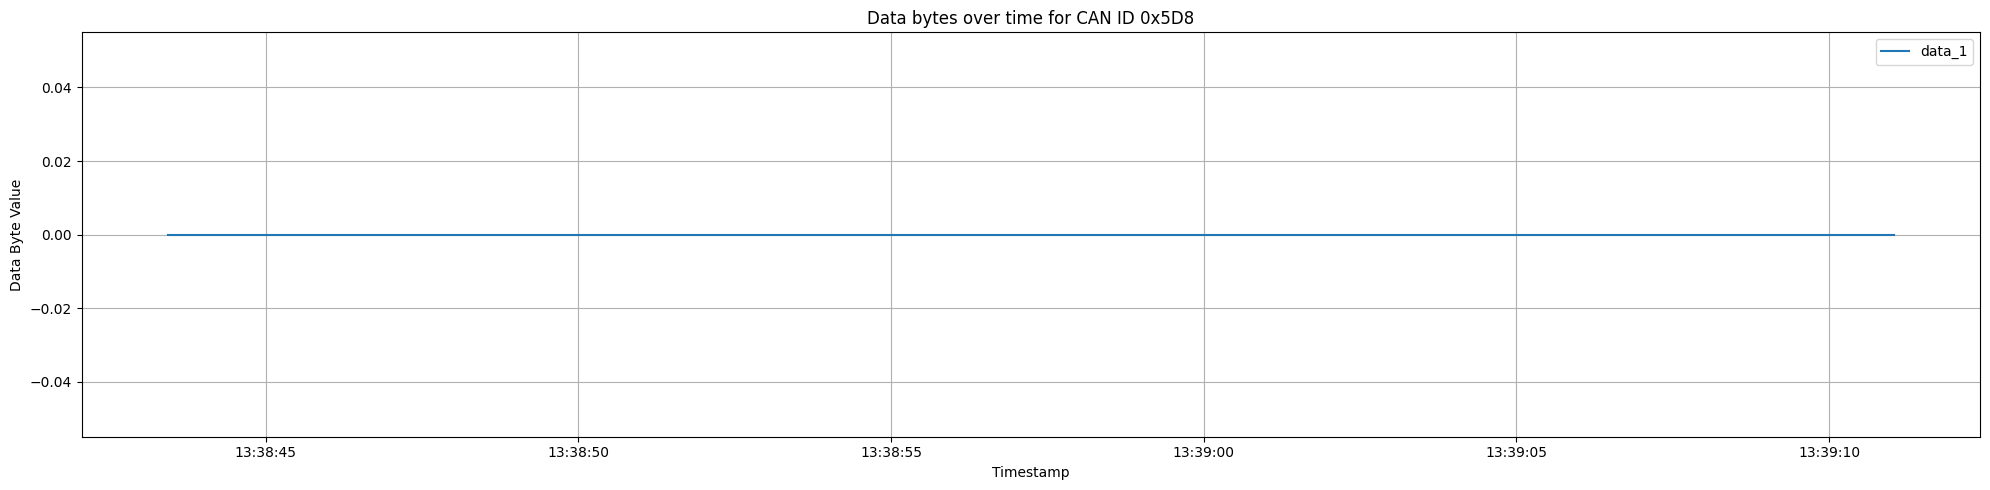

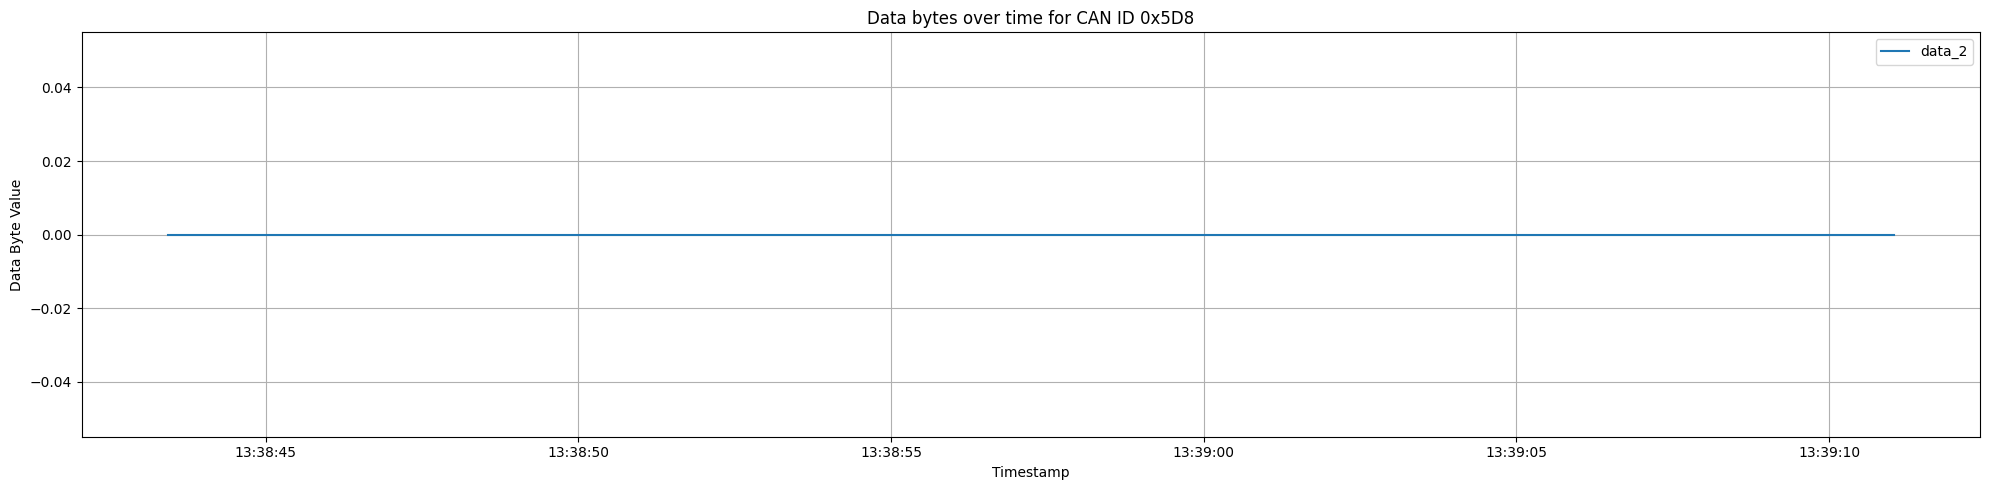

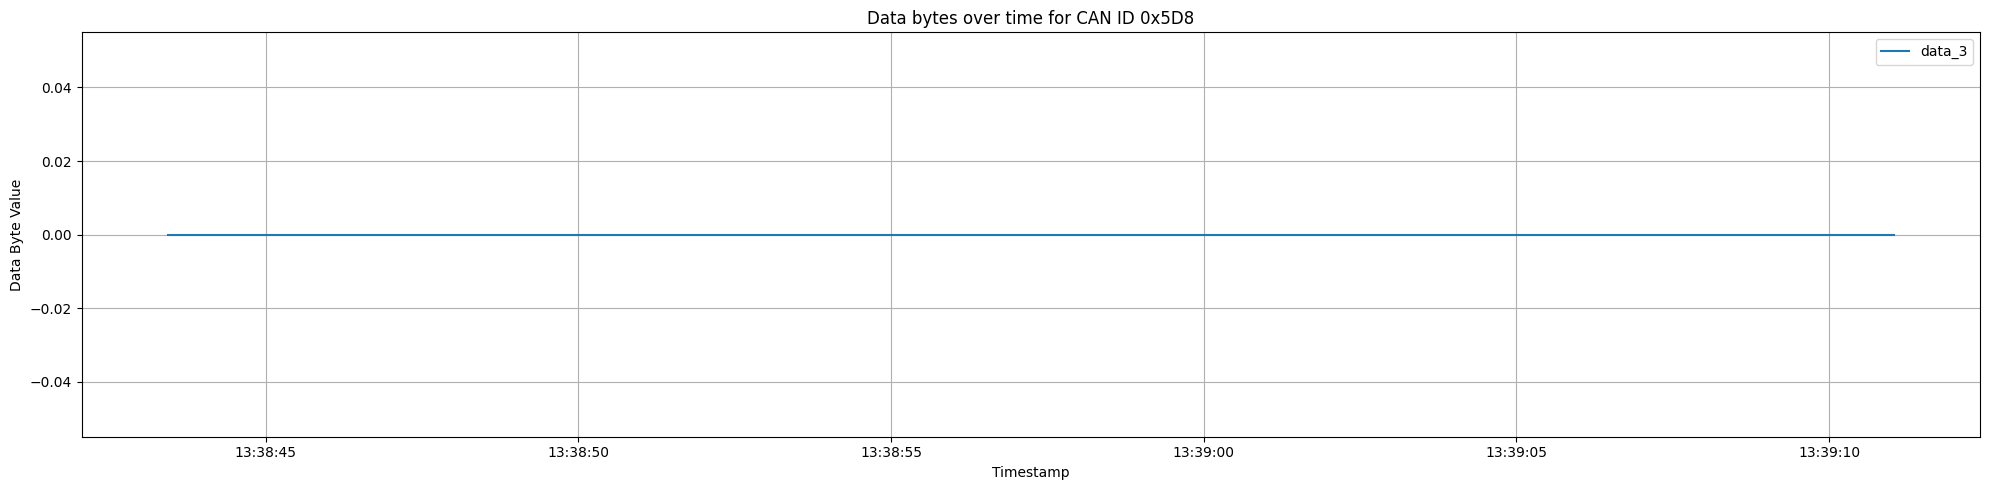

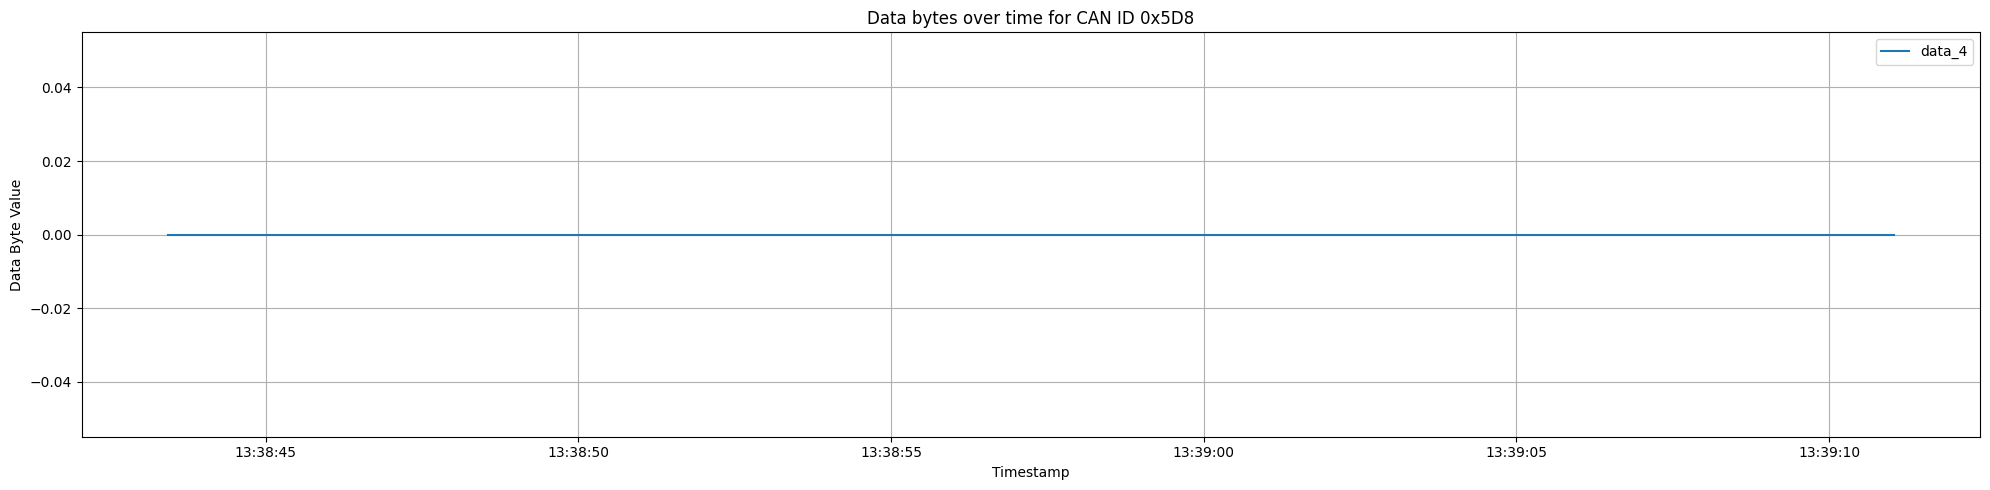

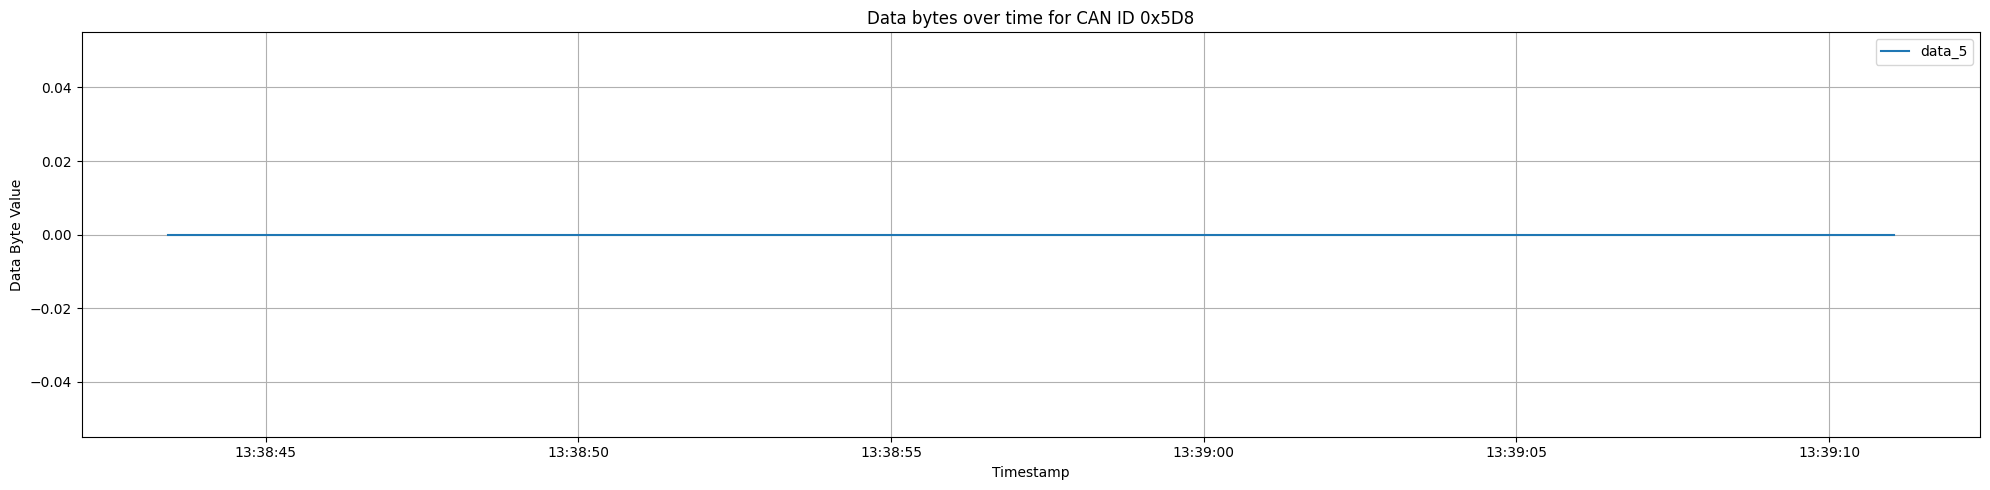

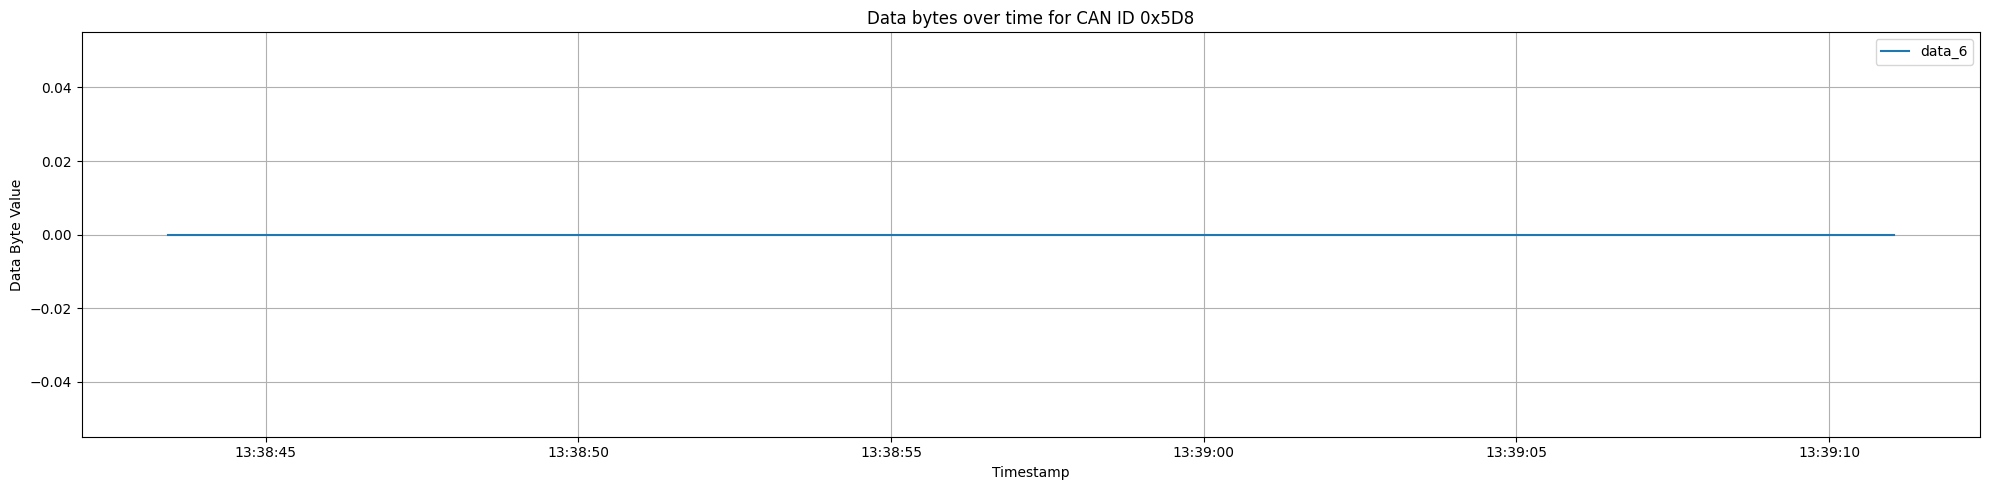

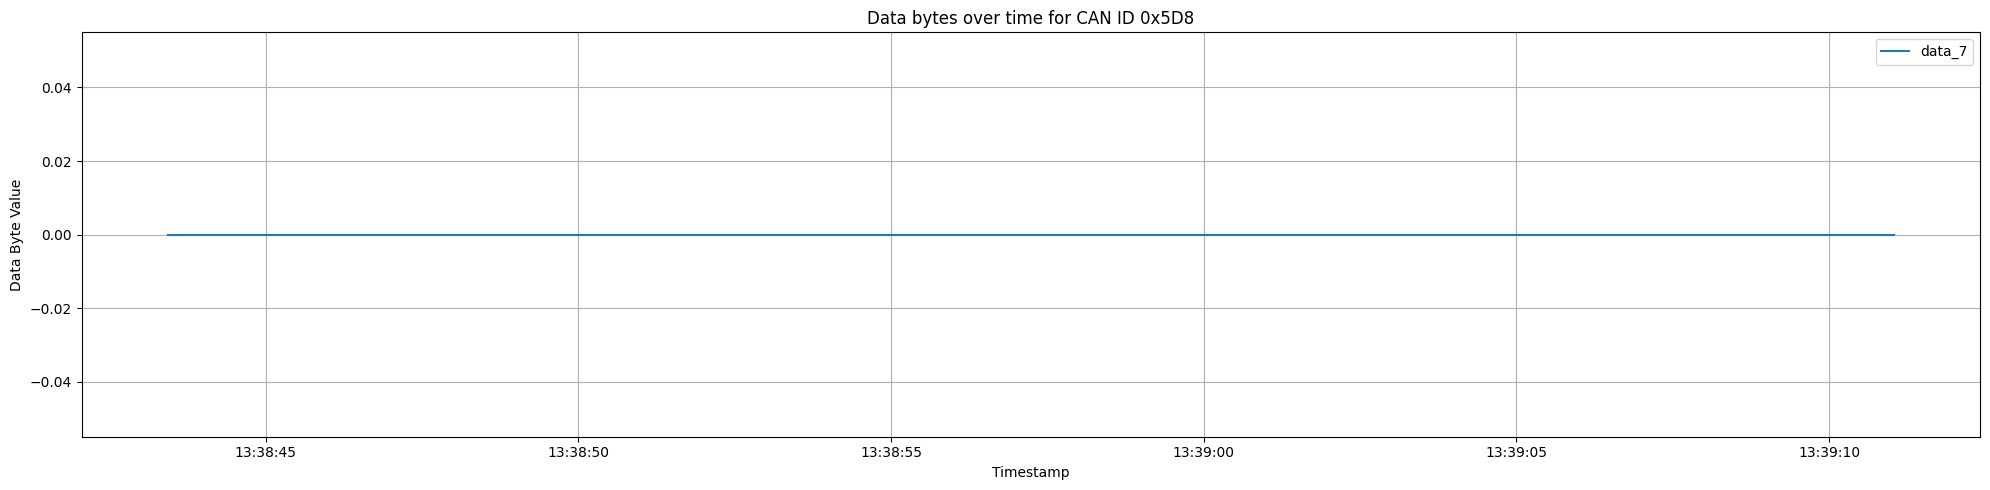

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import style

df_frio = pd.read_csv(r"C:\Users\vinic\Desktop\ESPs3\can_log_carro_frio.csv")

df_frio['data'] = df_frio['data'].fillna('')

max_len = 8 
def split_and_pad(row):
    parts = row.strip().split()
    ints = [int(p) for p in parts]
    return ints + [0] * (max_len - len(ints))

data_expanded = df_frio['data'].apply(split_and_pad).apply(pd.Series)
data_expanded.columns = [f'data_{i}' for i in range(max_len)]
df_frio = pd.concat([df_frio.drop(columns=['data']), data_expanded], axis=1)

# Ensure timestamp is datetime
df_frio['timestamp'] = pd.to_datetime(df_frio['timestamp'])

# Group by can_id
for can_id, group in df_frio.groupby('can_id'):
   
    
    for i in range(8):  # data_0 to data_7
        plt.figure(figsize=(20, 5))
    #     if f'data_{i}' in group.columns:
        plt.plot(group['timestamp'], group[f'data_{i}'], label=f'data_{i}')
        
        plt.title(f'Data bytes over time for CAN ID {can_id}')
        plt.xlabel('Timestamp')
        plt.ylabel('Data Byte Value')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import pandas as pd

In [ ]:
def read_can_data_from_file(filename):
    try:
        with open(filename, 'r') as file:
            return file.read()
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found")
        return None

In [ ]:
with open(r"C:\Users\vinic\Desktop\ESPs3\carro ligado acelerando até 2k rpm depois intertimente.txt", "r") as file:
    lines = file.readlines()

In [ ]:
# Set to store unique CAN IDs
unique_ids = set()

# Process each line
for line in lines:
    parts = line.strip().split()
    if len(parts) >= 3:
        can_id = parts[2]
        unique_ids.add(can_id)

# Print the unique CAN IDs
print("Unique CAN IDs:")
print(f"Quantidade CAN IDs: {len(unique_ids)}")
for can_id in sorted(unique_ids):
    print(can_id)


In [ ]:
can_data = {}

# Choose which byte to plot (0 for byte0, 1 for byte1, ..., 7 for byte7)
byte_index_to_plot = 0

# Process each line
for line in lines:
    parts = line.strip().split()
    if len(parts) >= 11:
        timestamp = int(parts[0])
        can_id = parts[2]
        
        # Extract the desired byte and convert to int
        byte_hex = parts[4 + byte_index_to_plot]
        byte_value = int(byte_hex, 16)

        if can_id not in can_data:
            can_data[can_id] = {'timestamps': [], 'values': []}

        can_data[can_id]['timestamps'].append(timestamp)
        can_data[can_id]['values'].append(byte_value)
# # Plot
# plt.figure(figsize=(12, 6))

# for can_id, data in can_data.items():
#     # if "520" in can_id:
#     #     continue
#     # if "488" in can_id:
#     #     continue
#     # if "588" in can_id:
#     #     continue
#     plt.plot(data['timestamps'], data['values'], marker='o', label=can_id)

# plt.xlabel('Timestamp')
# plt.ylabel(f'Byte {byte_index_to_plot} Value')
# plt.title(f'CAN Messages - Byte {byte_index_to_plot} Value over Time')
# plt.legend(loc='upper right', fontsize='small')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
can_data = {}

# Choose which byte to plot (0 for byte0, 1 for byte1, ..., 7 for byte7)
byte_index_to_plot = 0

# Process each line
for line in lines:
    parts = line.strip().split()
    if len(parts) >= 11:
        timestamp = int(parts[0])
        can_id = parts[2]
        
        # Extract the desired byte and convert to int
        byte_hex = parts[4 + byte_index_to_plot]
        byte_value = int(byte_hex, 16)

        if can_id not in can_data:
            can_data[can_id] = {'timestamps': [], 'values': []}

        can_data[can_id]['timestamps'].append(timestamp)
        can_data[can_id]['values'].append(byte_value)

# Plot
plt.figure(figsize=(12, 6))

for can_id, data in can_data.items():
    # if "520" in can_id:
    #     continue
    # if "488" in can_id:
    #     continue
    if "320" in can_id:
    #     continue
        plt.plot(data['timestamps'], data['values'], marker='o', label=can_id)

plt.xlabel('Timestamp')
plt.ylabel(f'Byte {byte_index_to_plot} Value')
plt.title(f'CAN Messages - Byte {byte_index_to_plot} Value over Time')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
can_data

In [ ]:
#488 acelerador
#288 provavelmente temperatura
#588 rpm

In [ ]:
import matplotlib.pyplot as plt

# Lê o arquivo (troque para seu arquivo real)
with open(r"D:\logs-0396537360\carro ligado acelerando até 2k rpm depois intertimente.txt", 'r') as f:
    lines = f.readlines()

# Estrutura de dados: {CAN_ID: {byte_index: (timestamps, values)}}
can_data = {}

# Processa cada linha
for line in lines:
    parts = line.strip().split()
    
    # Linha CAN válida → tem pelo menos 4 colunas (timestamp, CAN1, ID, primeiro byte)
    if len(parts) >= 4:
        timestamp = int(parts[0])
        can_id = parts[2]
        
        # Quantos bytes essa linha tem? → começa em parts[3], vai até o final
        n_bytes = len(parts) - 3
        n_bytes = min(n_bytes, 8)  # máximo 8 bytes CAN
        
        # Extrai os bytes disponíveis
        try:
            byte_values = [int(parts[3 + i], 16) for i in range(n_bytes)]
            
            # Se faltar bytes, completa com 0
            while len(byte_values) < 8:
                byte_values.append(0)
            
        except Exception as e:
            print(f"Erro ao processar linha: {line}")
            continue
        
        # Inicializa estrutura se não existir
        if can_id not in can_data:
            can_data[can_id] = {}
            for i in range(8):
                can_data[can_id][i] = {'timestamps': [], 'values': []}
        
        # Adiciona os valores
        for i, value in enumerate(byte_values):
            can_data[can_id][i]['timestamps'].append(timestamp)
            can_data[can_id][i]['values'].append(value)

# Agora gera os plots
for can_id, byte_dict in can_data.items():
    plt.figure(figsize=(12, 10))
    plt.suptitle(f'CAN ID {can_id} - Bytes over Time', fontsize=16)
    
    for i in range(8):
        plt.subplot(4, 2, i + 1)
        plt.plot(byte_dict[i]['timestamps'], byte_dict[i]['values'], marker='o')
        plt.title(f'Byte {i}')
        plt.xlabel('Timestamp')
        plt.ylabel('Value')
        plt.grid(True)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [ ]:
can_text_data = read_can_data_from_file(r"C:\Users\vinic\Desktop\ESPs3\logs\logs.txt")

In [ ]:
def parse_can_data(text_data):
    can_data = defaultdict(list)

    pattern = r'ID:\s*(0x[0-9A-Fa-f]+),\s*DLC:\s*(\d+),\s*Data:\s*((?:0x[0-9A-Fa-f]+\s*)+)'
    
    lines = text_data.strip().split('\n')
    timestamp = 0
    
    for line in lines:
        match = re.match(pattern, line.strip())
        if match:
            can_id = match.group(1)
            dlc = int(match.group(2))
            data_str = match.group(3)
            
            # Parse data bytes
            data_bytes = [int(x, 16) for x in data_str.split()]
            
            can_data[can_id].append({
                'timestamp': timestamp,
                'dlc': dlc,
                'data': data_bytes
            })
            timestamp += 1
    
    return dict(can_data)

In [ ]:
parsed_data = parse_can_data(can_text_data)

In [ ]:
def plot_can_data_by_id(can_data):
    colors = plt.cm.tab10(np.linspace(0, 1, 8))  
    for can_id, frames in can_data.items():
        timestamps = [frame['timestamp'] for frame in frames]
        max_bytes = max(len(frame['data']) for frame in frames)
        
        # fig, axes = plt.subplots(2, 1, figsize=(12, 10))
        # fig.suptitle(f'CAN ID: {can_id} - Data Evolution', fontsize=16, fontweight='bold')
        
        # ax1 = plt.()
        for byte_idx in range(max_bytes):
            byte_values = []
            valid_timestamps = []
            
            for frame in frames:
                if byte_idx < len(frame['data']):
                    byte_values.append(frame['data'][byte_idx])
                    valid_timestamps.append(frame['timestamp'])
            
            if byte_values:
                plt.plot(valid_timestamps, byte_values, 'o-', 
                        color=colors[byte_idx % len(colors)], 
                        label=f'Byte {byte_idx}', linewidth=2, markersize=4)
        
        # ax1.set_xlabel('Message Sequence')
        # ax1.set_ylabel('Byte Value (Hex)')
        # ax1.set_title('All Data Bytes')
        # ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        # ax1.grid(True, alpha=0.3)
        # ax1.set_ylim(0, 255)
        
        plt.tight_layout()        
        plt.show()

def create_summary_plot(can_data):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    y_pos = 0
    colors = plt.cm.Set3(np.linspace(0, 1, len(can_data)))
    
    for i, (can_id, frames) in enumerate(can_data.items()):
        timestamps = [frame['timestamp'] for frame in frames]
        y_values = [y_pos] * len(timestamps)
        
        ax.scatter(timestamps, y_values, label=can_id, s=50, 
                  color=colors[i], alpha=0.7, edgecolors='black', linewidth=0.5)
        y_pos += 1
    
    ax.set_xlabel('Message Sequence')
    ax.set_ylabel('CAN ID')
    ax.set_title('CAN Bus Activity Overview')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    ax.set_yticks(range(len(can_data)))
    ax.set_yticklabels(list(can_data.keys()))
    
    plt.tight_layout()
    plt.savefig('can_summary.png', dpi=300, bbox_inches='tight')
    print("Saved summary plot: can_summary.png")
    plt.show()

def print_data_statistics(can_data):
    """
    Print statistics about the CAN data
    """
    print("\n" + "="*50)
    print("CAN DATA STATISTICS")
    print("="*50)
    
    for can_id, frames in can_data.items():
        print(f"\nCAN ID: {can_id}")
        print(f"  Total frames: {len(frames)}")
        print(f"  DLC: {frames[0]['dlc'] if frames else 'N/A'}")
        
        if frames:
            # Analyze each byte position
            max_bytes = max(len(frame['data']) for frame in frames)
            print(f"  Data bytes analysis:")
            
            for byte_idx in range(max_bytes):
                byte_values = [frame['data'][byte_idx] for frame in frames 
                             if byte_idx < len(frame['data'])]
                if byte_values:
                    print(f"    Byte {byte_idx}: min=0x{min(byte_values):02X}, "
                          f"max=0x{max(byte_values):02X}, "
                          f"unique_values={len(set(byte_values))}")

In [ ]:
plot_can_data_by_id(parsed_data)

print(f"\nProcessed {len(parsed_data)} unique CAN IDs")